## 0. Entorno y datos

Montaje de Drive, definición de rutas y copia de los ficheros al disco
local de la máquina virtual. Todas las rutas cuelgan de la constante
`BASE`; no hay rutas escritas a mano en el resto del notebook.

### 0.1. Montaje de Drive
El disco de la máquina virtual de Colab es efímero: se pierde al cerrar la
sesión. Google Drive actúa como almacenamiento persistente del proyecto y debe
montarse al inicio de cada ejecución.

Esta celda es la única del notebook que requiere intervención manual, ya que
solicita autorización de acceso a la cuenta. Se mantiene aislada para que las
reejecuciones del resto del bloque no queden bloqueadas a la espera de esa
confirmación.

In [135]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 0.2. Instalación de dependencias
El entorno de Colab incorpora de serie las bibliotecas empleadas en este
notebook. En particular, `geopandas` 1.1 utiliza `pyogrio` como motor de
lectura y escritura de ficheros geoespaciales, incluyéndolo entre sus
dependencias obligatorias, por lo que no requiere instalación adicional.

La celda se conserva desactivada como registro explícito de esta dependencia.
En caso de ejecutar el notebook sobre un entorno distinto de Colab, basta con
descomentarla.

Por criterio de reproducibilidad, cualquier instalación necesaria se concentra
en este punto y no se dispersa por el resto del notebook: una instalación
intercalada rompería la ejecución completa desde el inicio.

In [136]:
#!pip install -q pyogrio

### 0.3. Importaciones y versiones
Se importan las bibliotecas empleadas y se fijan las opciones de presentación de
resultados. El formato numérico con separador de miles y dos decimales evita la
notación científica en las tablas descriptivas, poco legible tratándose de
precios de vivienda.

Se registran las versiones de las bibliotecas principales. La anotación responde
a un criterio de reproducibilidad: el comportamiento de `geopandas` ha variado
de forma apreciable entre versiones mayores, de modo que dejar constancia de la
versión utilizada permite diagnosticar discrepancias en ejecuciones posteriores.

Se silencian los avisos de obsolescencia (`FutureWarning`), abundantes en la
versión actual de `geopandas` y sin consecuencias sobre los resultados. Los
avisos de tipo `UserWarning`, que señalan situaciones con efecto real sobre el
cálculo (discordancias entre sistemas de referencia, entre otras), se mantienen
activos de forma deliberada.

In [137]:
import warnings
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
warnings.filterwarnings('ignore', category=FutureWarning)

for lib in (np, pd, gpd):
    print(f'{lib.__name__:12s} {lib.__version__}')

numpy        2.1.3
pandas       2.2.3
geopandas    1.1.4


### 0.4. Rutas y constantes
Se declaran en un único punto las rutas del proyecto y los parámetros que
condicionan el análisis. Ninguna ruta se escribe de forma literal en el resto del
notebook: todas derivan de las constantes definidas aquí.

Los sistemas de referencia se recogen en esta celda por tratarse de una decisión
de proyecto y no de un detalle de implementación. Los datos se distribuyen en
EPSG:4326 (coordenadas geográficas en grados), sistema sobre el que la distancia
euclídea carece de significado físico, ya que un grado de longitud y uno de
latitud no equivalen a la misma distancia sobre el terreno. El cálculo de
distancias exige por tanto una reproyección previa a un sistema métrico, que
varía según el huso UTM en que se sitúa cada ciudad.

Se fija asimismo una semilla para los procedimientos que incorporan aleatoriedad,
de modo que los resultados sean reproducibles entre ejecuciones.

In [138]:

BASE  = Path('/content/drive/MyDrive/Master Data Science/TFM_AVM')
LOCAL = Path('/content/TFM_AVM')

RAW       = LOCAL / 'data' / 'raw'
PROCESSED = LOCAL / 'data' / 'processed'
FIGURAS   = BASE / 'figuras'

CIUDADES = ['Madrid', 'Barcelona', 'Valencia']

CRS_ORIGEN = 'EPSG:4326'
CRS_METRICO = {
    'Madrid':    'EPSG:25830',
    'Barcelona': 'EPSG:25831',
    'Valencia':  'EPSG:25830',
}

SEMILLA = 42

assert BASE.exists(), f'No se encuentra la ruta base: {BASE}'
print('Ruta base localizada.')

Ruta base localizada.


### 0.5. Copia al disco local
Los ficheros se copian de Drive al disco local de la máquina virtual y se crea la
estructura de carpetas de salida.

La operación se realiza mediante funciones de Python en lugar de comandos de
shell. Además de resultar más robusta, evita la necesidad de entrecomillar rutas
que contienen espacios, circunstancia que afecta a la ruta base del proyecto.

La celda es idempotente: comprueba la existencia previa de los ficheros antes de
copiarlos, de modo que puede ejecutarse repetidamente sin efectos indeseados.

In [139]:
if not RAW.exists():
    print('Copiando datos de Drive al disco local...')
    shutil.copytree(BASE / 'data' / 'raw', RAW)
    print('Copia completada.')
else:
    print('Los datos ya están en el disco local.')

for carpeta in (PROCESSED, FIGURAS):
    carpeta.mkdir(parents=True, exist_ok=True)

print(f'\nRAW:       {RAW}')
print(f'PROCESSED: {PROCESSED}')
print(f'FIGURAS:   {FIGURAS}')

Los datos ya están en el disco local.

RAW:       /content/TFM_AVM/data/raw
PROCESSED: /content/TFM_AVM/data/processed
FIGURAS:   /content/drive/MyDrive/Master Data Science/TFM_AVM/figuras


### 0.6. Verificación del inventario
Se enumeran los ficheros disponibles y se verifica la presencia de los esperados
antes de iniciar el análisis.

La comprobación se sitúa en este punto de forma deliberada: un fichero ausente
debe detectarse aquí, con un mensaje explícito, y no más adelante en forma de
error de ruta en mitad de una operación de carga.

El fichero `properties_by_district.gpkg` se excluye de la relación de ficheros
obligatorios por tratarse de un elemento cuyo contenido no consta documentado y
cuya utilidad está pendiente de determinar.

In [140]:
ficheros = sorted(RAW.iterdir())

print(f'{len(ficheros)} elementos en data/raw '
      f'(incluidas fuentes externas de notebooks posteriores)\n')
for f in ficheros:
    print(f'  {f.name:35s} {f.stat().st_size/1e6:8.2f} MB')

esperados = (
    [f'{c}_Sale.gpkg' for c in CIUDADES]
    + [f'{c}_Polygons.gpkg' for c in CIUDADES]
    + [f'Madrid_POIS_{t}.csv' for t in ('City_Center', 'Metro', 'Castellana')]
)
faltan = [n for n in esperados if not (RAW / n).exists()]
assert not faltan, f'Faltan ficheros: {faltan}'
print('\nTodos los ficheros esperados están presentes.')

18 elementos en data/raw (incluidas fuentes externas de notebooks posteriores)

  Barcelona_POIS_City_Center.csv          0.00 MB
  Barcelona_POIS_Diagonal.csv             0.00 MB
  Barcelona_POIS_Metro.csv                0.01 MB
  Barcelona_Polygons.gpkg                 0.17 MB
  Barcelona_Sale.gpkg                    13.88 MB
  Madrid_POIS_Castellana.csv              0.00 MB
  Madrid_POIS_City_Center.csv             0.00 MB
  Madrid_POIS_Metro.csv                   0.01 MB
  Madrid_Polygons.gpkg                    0.24 MB
  Madrid_Sale.gpkg                       21.36 MB
  Valencia_POIS_Blasco.csv                0.00 MB
  Valencia_POIS_City_Center.csv           0.00 MB
  Valencia_POIS_Metro.csv                 0.00 MB
  Valencia_Polygons.gpkg                  0.16 MB
  Valencia_Sale.gpkg                      7.63 MB
  ine_renta_madrid_2018.csv               0.58 MB
  properties_by_district.gpkg             0.33 MB
  seccionado_2018                         0.00 MB

Todos los ficheros 

## 1. Carga y primer vistazo *(memoria: apartado 2.1)*

Este bloque carga los ficheros generados por `00_preparacion_datos` y establece
las propiedades estructurales del conjunto: volumen, esquema, completitud de las
variables e integridad de la información geográfica.

El bloque no realiza análisis descriptivo del contenido ni transformación alguna
de los datos. Su función es verificar que el material de partida es el esperado y
dejar constancia de sus características antes de operar sobre él.

### 1.1. Ámbito del trabajo

El conjunto original cubre Madrid, Barcelona y Valencia. El trabajo se restringe
a Madrid por tres motivos:

- **Sistemas de referencia.** Madrid y Valencia se proyectan sobre EPSG:25830 y
  Barcelona sobre EPSG:25831, al situarse en husos UTM distintos. Un tratamiento
  conjunto obligaría a reproyectar alguna ciudad fuera de su huso, degradando la
  precisión de las distancias.
- **Comparabilidad de los mercados.** Los tres mercados inmobiliarios presentan
  niveles de precio y dinámicas propias, por lo que su agregación no resulta
  informativa para un modelo de valoración.
- **Granularidad espacial.** Madrid dispone de 135 unidades de barrio frente a 69
  en Barcelona y 73 en Valencia, lo que favorece el enriquecimiento geoespacial y
  el análisis de equidad.

> **Decisión — Restricción del ámbito a Madrid**
>
> **Contexto.** Expuesto en el apartado 1.1.
>
> **Decisión.** El desarrollo completo (análisis, enriquecimiento, modelización,
> interpretabilidad y productivización) se realiza sobre Madrid.
>
> **Motivo.** Elimina la necesidad de un tratamiento por ciudad en cada operación
> geométrica y permite dedicar la extensión disponible a los ejes diferenciales
> del trabajo en lugar de a describir tres mercados.
>
> **Alternativa descartada.** Modelo conjunto con la ciudad como variable. Se
> descarta porque el modelo resultante sería un promedio de mercados heterogéneos
> y complicaría la lectura de la interpretabilidad.

In [141]:
CIUDAD = 'Madrid'
CRS_M  = CRS_METRICO[CIUDAD]

POIS_FICHEROS = {
    'city_center': 'Madrid_POIS_City_Center.csv',
    'metro':       'Madrid_POIS_Metro.csv',
    'eje':         'Madrid_POIS_Castellana.csv',
}
NOMBRE_EJE = 'Paseo de la Castellana'

print(f'Ciudad: {CIUDAD}')
print(f'CRS de origen: {CRS_ORIGEN}   CRS métrico: {CRS_M}')

Ciudad: Madrid
CRS de origen: EPSG:4326   CRS métrico: EPSG:25830


### 1.2. Carga de los anuncios

Se carga el fichero de anuncios de venta de Madrid. El objeto resultante
incorpora una columna de geometría de tipo punto y un sistema de referencia
asociado, que se verifica de forma explícita: la lectura correcta de la
proyección condiciona todas las operaciones geométricas posteriores.

In [142]:
ventas = gpd.read_file(RAW / f'{CIUDAD}_Sale.gpkg')

print(f'{len(ventas):,} anuncios x {ventas.shape[1]} columnas')
print(f'CRS: {ventas.crs.to_string()}')
print(f'geometría: {ventas.geom_type.value_counts().to_dict()}')
print(f'memoria: {ventas.memory_usage(deep=True).sum() / 1e6:.0f} MB')

94,815 anuncios x 42 columnas
CRS: EPSG:4326
geometría: {'Point': 94815}
memoria: 27 MB


### 1.3. Carga de los polígonos de barrio

Los polígonos delimitan las unidades espaciales de la ciudad. No incorporan
ninguna referencia a las viviendas: la asignación de cada anuncio a su barrio se
obtiene mediante un cruce espacial, que se realiza en el bloque de
enriquecimiento.

Se comprueba que las geometrías son válidas y que constituyen una partición sin
solapamientos apreciables. La verificación consiste en contrastar la suma de las
áreas individuales con el área de la unión de todos los polígonos: cuanto más
próximas resulten ambas magnitudes, menor será la superposición y más fiable la
asignación de un único barrio a cada vivienda.

El residuo observado, de 0,01 km² sobre 602, equivale al 0,002% de la superficie
del municipio. Resulta atribuible a la precisión con que están trazados los
vértices de los polígonos y no a un solapamiento real entre zonas, de modo que
no compromete el cruce espacial.

In [143]:
barrios = gpd.read_file(RAW / f'{CIUDAD}_Polygons.gpkg')

# El fichero declara el datum WGS84 pero no el código EPSG. Se asigna de forma
# explícita antes de cualquier operación geométrica.
crs_original = barrios.crs
if barrios.crs is None or barrios.crs.to_epsg() is None:
    barrios = barrios.set_crs(CRS_ORIGEN, allow_override=True)
    print(f'CRS sin código EPSG en el fichero -> asignado {barrios.crs.to_string()}\n')

print(f'{len(barrios)} polígonos x {barrios.shape[1]} columnas')
print(f'CRS: {barrios.crs.to_string()}')
print(f'geometría: {barrios.geom_type.value_counts().to_dict()}')
print(f'columnas: {barrios.columns.tolist()}')
print(f'geometrías inválidas: {(~barrios.is_valid).sum()}')

# Identificadores de distrito y barrio contenidos en LOCATIONID
partes = barrios.LOCATIONID.str.split('-')
barrios['DISTRITO'] = partes.str[-2]
barrios['BARRIO']   = partes.str[-1]
print(f'\n{barrios.DISTRITO.nunique()} distritos, {len(barrios)} barrios')

# Comprobación de partición: si no hay solapamientos, la suma de las áreas
# individuales coincide con el área de la unión.
barrios_m = barrios.to_crs(CRS_M)
suma  = barrios_m.area.sum() / 1e6
union = barrios_m.union_all().area / 1e6
print(f'\nsuma de áreas:    {suma:8.2f} km²')
print(f'área de la unión: {union:8.2f} km²')
print(f'solapamiento:     {suma - union:8.2f} km²  ({(suma-union)/union:.3%})')
print(f'referencia: término municipal de Madrid ≈ 604 km²')

display(barrios.drop(columns=barrios.geometry.name).head())

CRS sin código EPSG en el fichero -> asignado EPSG:4326

135 polígonos x 4 columnas
CRS: EPSG:4326
geometría: {'MultiPolygon': 135}
columnas: ['LOCATIONID', 'LOCATIONNAME', 'ZONELEVELID', 'geometry']
geometrías inválidas: 0

21 distritos, 135 barrios

suma de áreas:      602.14 km²
área de la unión:   602.13 km²
solapamiento:         0.01 km²  (0.002%)
referencia: término municipal de Madrid ≈ 604 km²


,LOCATIONID,LOCATIONNAME,ZONELEVELID,DISTRITO,BARRIO
0,0-EU-ES-28-07-001-079-16-002,Conde Orgaz-Piovera,8,16,002
1,0-EU-ES-28-07-001-079-16-004,Pinar del Rey,8,16,004
2,0-EU-ES-28-07-001-079-21-004,Timón,8,21,004
3,0-EU-ES-28-07-001-079-01-001,Palacio,8,01,001
4,0-EU-ES-28-07-001-079-01-003,Huertas-Cortes,8,01,003


In [144]:
partes = barrios.LOCATIONID.str.split('-')
barrios['DISTRITO'] = partes.str[-2]
barrios['BARRIO']   = partes.str[-1]

print('Barrios por distrito:')
print(barrios.groupby('DISTRITO').LOCATIONNAME.count().sort_index())

Barrios por distrito:
DISTRITO
01     6
02     6
03     6
04     6
05     6
06     6
07     6
08    10
09     7
10     7
11     8
12     7
13     6
14     6
15     9
16     8
17     5
18     3
19     4
20     8
21     5
Name: LOCATIONNAME, dtype: int64


La lectura del fichero revela que el sistema de referencia declarado identifica
el datum (WGS84) pero no incorpora el código EPSG correspondiente. Se asigna de
forma explícita antes de cualquier operación geométrica, con el fin de evitar
discordancias en los cruces espaciales posteriores.

El campo `LOCATIONID` presenta una estructura jerárquica que codifica, en sus dos
últimos segmentos, el distrito y el barrio. Su descomposición proporciona un
nivel de agregación intermedio, de utilidad tanto para el análisis por zonas como
para el enlace con fuentes externas de ámbito municipal.

### 1.4. Carga de los puntos de interés

Los puntos de interés se distribuyen como tablas planas con coordenadas en
columnas, sin geometría asociada. Se cargan como tablas y su conversión a objetos
espaciales se pospone al bloque de enriquecimiento, momento en que se construyen
las variables de proximidad.

El conjunto correspondiente al eje viario no representa localizaciones
independientes sino una secuencia de puntos que traza una línea, circunstancia
que condiciona el cálculo de distancias a dicho eje.

In [145]:
pois = {tipo: pd.read_csv(RAW / f) for tipo, f in POIS_FICHEROS.items()}

for tipo, tabla in pois.items():
    print(f'{tipo:14s} {len(tabla):4d} puntos   columnas: {tabla.columns.tolist()}')

print()
display(pois['metro'].head(3))

city_center       1 puntos   columnas: ['Lon', 'Lat']
metro           240 puntos   columnas: ['Lon', 'Lat']
eje             155 puntos   columnas: ['Lon', 'Lat']



,Lon,Lat
0,-3.65,40.39
1,-3.70,40.45
2,-3.70,40.41


### 1.5. Esquema y tipos de dato

Se revisa el conjunto de variables disponibles, agrupadas por naturaleza, y la
distribución de tipos de dato. La agrupación sigue el contenido descrito en la
documentación del paquete, recogido en el apartado siguiente.

La documentación del paquete describe el significado de cada variable. Su
consulta resulta necesaria antes de cualquier análisis, dado que varias
denominaciones admiten lecturas distintas de la efectiva.

| Variable | Contenido según documentación |
|---|---|
| `ROOMNUMBER` | Número de **dormitorios**, no de estancias |
| `AMENITYID` | Nivel de equipamiento: 1 sin cocina equipada ni muebles, 2 cocina equipada, 3 cocina equipada y muebles |
| `FLATLOCATIONID` | Tipo de vistas: 1 exterior, 2 interior |
| `FLOORCLEAN` | Planta, con valor 0 para la planta baja (fuente: anunciante) |
| `CADASTRALQUALITYID` | Calidad constructiva (fuente: catastro) |
| `BUILTTYPEID_1/2/3` | Estado: 1 obra nueva, 2 segunda mano a reformar, 3 segunda mano en buen estado |
| `HAS*ORIENTATION` | Orientación declarada. **No son excluyentes**: una vivienda puede declarar varias |
| `PARKINGSPACEPRICE` | Precio de la plaza de aparcamiento en euros |

Dos advertencias sobre la propia documentación. La primera, que la ficha del
objeto declara 156.016 registros y 57 variables, cifras que no corresponden al
objeto distribuido, de 94.815 y 42. La segunda, que `DISTANCE_TO_METRO` no figura
en la relación de variables por un error de sintaxis en el fichero de
documentación. Ambas circunstancias aconsejan verificar empíricamente cuanto se
afirme sobre el conjunto.

`AMENITYID` constituye una variable ordinal y no una etiqueta sin orden: sus tres
niveles describen una gradación creciente de equipamiento. La advertencia sobre
la no exclusividad de las orientaciones impide su tratamiento como conjunto de
indicadores de una única variable categórica.

Fuente: documentación del paquete, sección de referencia del objeto `Madrid_Sale`
(`https://paezha.github.io/idealista18/reference/Madrid_Sale.html`).

In [146]:
GRUPOS = {
    'Objetivo y tamaño': ['PRICE', 'UNITPRICE', 'CONSTRUCTEDAREA'],
    'Características':   ['ROOMNUMBER', 'BATHNUMBER', 'FLOORCLEAN', 'ISDUPLEX',
                          'ISSTUDIO', 'ISINTOPFLOOR', 'CONSTRUCTIONYEAR',
                          'FLATLOCATIONID'],
    'Equipamiento':      ['AMENITYID', 'HASTERRACE', 'HASLIFT',
                          'HASAIRCONDITIONING', 'HASPARKINGSPACE',
                          'ISPARKINGSPACEINCLUDEDINPRICE', 'PARKINGSPACEPRICE',
                          'HASBOXROOM', 'HASWARDROBE', 'HASSWIMMINGPOOL',
                          'HASDOORMAN', 'HASGARDEN'],
    'Orientación':       ['HASNORTHORIENTATION', 'HASSOUTHORIENTATION',
                          'HASEASTORIENTATION', 'HASWESTORIENTATION'],
    'Catastro':          ['CADCONSTRUCTIONYEAR', 'CADMAXBUILDINGFLOOR',
                          'CADDWELLINGCOUNT', 'CADASTRALQUALITYID',
                          'BUILTTYPEID_1', 'BUILTTYPEID_2', 'BUILTTYPEID_3'],
    'Localización':      ['LONGITUDE', 'LATITUDE', 'DISTANCE_TO_CITY_CENTER',
                          'DISTANCE_TO_METRO', 'DISTANCE_TO_CASTELLANA'],
    'Identificación':    ['ASSETID', 'PERIOD'],
}

for grupo, cols in GRUPOS.items():
    print(f'\n{grupo} ({len(cols)})')
    for c in cols:
        marca = '' if c in ventas.columns else '  <-- NO EXISTE'
        print(f'  {c:32s} {str(ventas[c].dtype) if c in ventas.columns else "":10s}{marca}')

clasificadas = {c for cols in GRUPOS.values() for c in cols}
resto = set(ventas.columns) - clasificadas - {ventas.geometry.name}
print(f'\ncolumnas sin clasificar: {sorted(resto) if resto else "ninguna"}')


Objetivo y tamaño (3)
  PRICE                            float64   
  UNITPRICE                        float64   
  CONSTRUCTEDAREA                  int32     

Características (8)
  ROOMNUMBER                       int32     
  BATHNUMBER                       int32     
  FLOORCLEAN                       float64   
  ISDUPLEX                         int32     
  ISSTUDIO                         int32     
  ISINTOPFLOOR                     int32     
  CONSTRUCTIONYEAR                 float64   
  FLATLOCATIONID                   float64   

Equipamiento (12)
  AMENITYID                        int32     
  HASTERRACE                       int32     
  HASLIFT                          int32     
  HASAIRCONDITIONING               int32     
  HASPARKINGSPACE                  int32     
  ISPARKINGSPACEINCLUDEDINPRICE    int32     
  PARKINGSPACEPRICE                int32     
  HASBOXROOM                       int32     
  HASWARDROBE                      int32     
  HASSWIMMINGPOOL

### 1.6. Valores ausentes

Se cuantifica la proporción de valores ausentes por variable. El tratamiento de
estos valores corresponde al bloque de preparación de datos; en este punto la
información recogida tiene carácter diagnóstico y permite anticipar qué variables
requerirán una decisión explícita.

In [147]:
n = ventas.isna().sum()
nulos = pd.DataFrame({'nulos': n, 'pct': (100 * n / len(ventas)).round(2)})
nulos = nulos[nulos.nulos > 0].sort_values('nulos', ascending=False)

if len(nulos):
    print(f'{len(nulos)} variables con valores ausentes:')
    display(nulos)
else:
    print('No hay valores ausentes en ninguna variable.')

print(f'\nfilas completas: {ventas.notna().all(axis=1).sum():,} de {len(ventas):,}')

4 variables con valores ausentes:


,nulos,pct
CONSTRUCTIONYEAR,55873,58.93
FLATLOCATIONID,6387,6.74
FLOORCLEAN,3846,4.06
CADASTRALQUALITYID,1,0.00



filas completas: 35,821 de 94,815


### 1.7. Integridad de la información geográfica

Se verifican tres aspectos de la componente espacial.

**Validez de las geometrías.** Ausencia de valores nulos o geometrías mal
formadas que impidan las operaciones posteriores.

**Coherencia entre representaciones.** El conjunto almacena las coordenadas por
duplicado: en las columnas `LONGITUDE` y `LATITUDE` y en el objeto geométrico. Se
comprueba si ambas representaciones coinciden. La cuestión no es formal: la
reproyección modifica la geometría pero no las columnas, de modo que su
conservación simultánea introduciría dos sistemas de referencia distintos en una
misma tabla.

**Extensión geográfica.** Se contrasta el rango de coordenadas con la
localización conocida del municipio. La comprobación detecta la inversión entre
longitud y latitud, un error que no genera excepción alguna y que invalidaría por
completo el cálculo de distancias.

In [148]:
print(f'geometrías nulas:     {ventas.geometry.isna().sum():,}')
print(f'geometrías inválidas: {(~ventas.geometry.is_valid).sum():,}')

dlon = (ventas.geometry.x - ventas.LONGITUDE).abs().max()
dlat = (ventas.geometry.y - ventas.LATITUDE ).abs().max()
print(f'\ndesviación máx. longitud: {dlon:.12f}')
print(f'desviación máx. latitud:  {dlat:.12f}')
print(f'representaciones equivalentes: {max(dlon, dlat) < 1e-9}')

minx, miny, maxx, maxy = ventas.total_bounds
print(f'\nextensión observada:')
print(f'  longitud: [{minx:.4f}, {maxx:.4f}]')
print(f'  latitud:  [{miny:.4f}, {maxy:.4f}]')
print(f'referencia Madrid capital: longitud ~ -3.70, latitud ~ 40.42')

fuera = barrios.to_crs(CRS_ORIGEN).union_all()
print(f'\nanuncios fuera del término municipal: '
      f'{(~ventas.geometry.within(fuera)).sum():,}')

geometrías nulas:     0
geometrías inválidas: 0

desviación máx. longitud: 0.000000000000
desviación máx. latitud:  0.000000000000
representaciones equivalentes: True

extensión observada:
  longitud: [-3.8336, -2.7533]
  latitud:  [36.7564, 40.5206]
referencia Madrid capital: longitud ~ -3.70, latitud ~ 40.42

anuncios fuera del término municipal: 94


### 1.8. Fichero adicional `properties_by_district`

La documentación describe este objeto como el número total de propiedades por
distrito en 2018, sin mayor detalle sobre su procedencia ni sobre el significado
de sus columnas. Se inspecciona con el fin de determinar si aporta información
aprovechable o si resulta redundante respecto a los polígonos de barrio.

In [149]:
pbd = gpd.read_file(RAW / 'properties_by_district.gpkg')

print(f'{len(pbd)} filas x {pbd.shape[1]} columnas')
_epsg = pbd.crs.to_epsg() if pbd.crs else None
print(f'CRS: {f"EPSG:{_epsg}" if _epsg else "declarado sin código EPSG (datum WGS84)"}')
print(f'geometría: {pbd.geom_type.value_counts().to_dict()}')
print(f'columnas: {pbd.columns.tolist()}\n')

display(pbd.drop(columns=pbd.geometry.name).head(10))

47 filas x 5 columnas
CRS: declarado sin código EPSG (datum WGS84)
geometría: {'Polygon': 29, 'MultiPolygon': 18}
columnas: ['District', 'N_CADASTRE', 'N', 'CITY', 'geometry']



,District,N_CADASTRE,N,CITY
0,1.00,"89,467.00","11,630.00",Madrid
1,2.00,"77,318.00","4,362.00",Madrid
2,3.00,"57,006.00","3,892.00",Madrid
3,4.00,"80,666.00","8,096.00",Madrid
4,5.00,"69,016.00","5,111.00",Madrid
5,6.00,"82,875.00","5,883.00",Madrid
6,7.00,"79,250.00","6,301.00",Madrid
7,8.00,"105,578.00","3,533.00",Madrid
8,9.00,"57,224.00","3,512.00",Madrid
9,10.00,"110,214.00","4,715.00",Madrid


### Síntesis del bloque

**Punto de partida.** 94.815 anuncios de venta en Madrid, con 42 variables y
geometría de tipo punto en EPSG:4326, junto a 135 polígonos de barrio y tres
conjuntos de puntos de interés.

**Cuestión abierta.** El identificador `ASSETID` no es único a nivel de fila. La
documentación del paquete lo describe como identificador de la vivienda, de modo
que su repetición requiere explicación antes de operar sobre los datos. El bloque
siguiente aborda esta cuestión.

**Fichero adicional.** `properties_by_district` permite calcular la tasa de
rotación del mercado como cociente entre anuncios publicados y parque catastral,
magnitud que aproxima la liquidez de cada zona y que ninguna otra variable del
conjunto recoge. Se descarta no obstante por redundancia: al estar definida
sobre los 21 distritos del municipio, constituye una función determinista del
distrito, cuyo efecto el modelo puede estimar directamente al incorporar dicha
variable como categórica. Su empleo resultaría pertinente únicamente si se
optara por prescindir del distrito como variable explicativa, en cuyo caso
proporcionaría una representación numérica compacta de la misma información.

**Elementos que se trasladan a la memoria (apartado 2.1).** Volumen y naturaleza
del conjunto, restricción del ámbito a Madrid con su justificación, y valoración
sintética de la completitud de las variables. El detalle de esquemas,
verificaciones geométricas y valores ausentes se traslada al anexo.

## 2. Identidad de los registros y deduplicación *(memoria: apartados 2.3 y 3.3)*

El bloque anterior detectó que el identificador `ASSETID` no es único a nivel de
fila, circunstancia que contradice su descripción en la documentación del
paquete. Antes de cualquier análisis descriptivo es necesario determinar qué
representa exactamente cada registro, ya que de ello dependen tanto los
estadísticos que se calculen como la estrategia de validación del modelo.

El bloque procede en tres fases: caracterización de las repeticiones dentro de un
mismo trimestre, examen de la componente espacial, e investigación de la posible
reaparición de viviendas entre trimestres distintos.

**Referencia documental.** El README del paquete y el artículo asociado (Rey-Blanco
et al., 2024) establecen que `ASSETID` es el identificador único de la vivienda,
que una misma vivienda puede figurar en más de un periodo cuando el inmueble no
se vendió en el trimestre en que se publicó, y que las coordenadas facilitadas
son aproximadas.

### 2.1. La unidad de observación

Se contrastan tres magnitudes: el número de filas, el número de identificadores
distintos y el número de pares identificador-trimestre distintos.

La comparación entre las dos últimas resuelve una cuestión concreta. Si un
identificador figurase en varios trimestres, contribuiría con varios pares y la
tercera cifra superaría a la segunda. Su coincidencia indicaría que cada
identificador está asociado a un único trimestre.

In [150]:
n_filas   = len(ventas)
n_assetid = ventas.ASSETID.nunique()
n_pares   = len(ventas[['ASSETID', 'PERIOD']].drop_duplicates())

print(f'filas:                      {n_filas:,}')
print(f'ASSETID distintos:          {n_assetid:,}')
print(f'pares ASSETID + PERIOD:     {n_pares:,}')
print(f'exceso de filas:            {n_filas - n_assetid:,} '
      f'({(n_filas - n_assetid) / n_filas:.1%})')
print(f'\n¿algún ASSETID en varios trimestres?  '
      f'{"SÍ" if n_pares > n_assetid else "NO"}')

print('\nanuncios por trimestre:')
print(ventas.PERIOD.value_counts().sort_index().to_string())

print('\nnúmero de anuncios por identificador:')
print(ventas.ASSETID.value_counts().value_counts().sort_index().to_string())

filas:                      94,815
ASSETID distintos:          75,804
pares ASSETID + PERIOD:     75,804
exceso de filas:            19,011 (20.1%)

¿algún ASSETID en varios trimestres?  NO

anuncios por trimestre:
PERIOD
201803    21920
201806    12652
201809    15973
201812    44270

número de anuncios por identificador:
count
1     61975
2      9842
3      3098
4       673
5       150
6        51
7        11
8         1
9         2
11        1


### 2.2. Naturaleza de las repeticiones dentro de un trimestre

Establecido que las repeticiones se producen íntegramente dentro de un mismo
trimestre, procede determinar a qué corresponden. Se contemplan dos hipótesis:

- **Hipótesis A.** El identificador designa el edificio, de modo que cada fila
  correspondería a una vivienda distinta del mismo inmueble.
- **Hipótesis B.** El identificador designa la vivienda, conforme a la
  documentación, y las filas corresponden a varios anuncios de un mismo activo.

Las hipótesis admiten contraste mediante las variables que describen la vivienda
frente a las que describen el edificio. Las variables catastrales (año de
construcción, número de plantas, número de viviendas y calidad) caracterizan el
inmueble en su conjunto y coincidirían bajo ambas hipótesis. La planta, el número
de dormitorios y el de baños, en cambio, discriminan: bajo la hipótesis A
diferirían sistemáticamente entre las viviendas de un mismo edificio; bajo la
hipótesis B coincidirían.

In [151]:
rep = ventas[ventas.duplicated('ASSETID', keep=False)]
grupos = rep.groupby('ASSETID')

CAD  = ['CADCONSTRUCTIONYEAR', 'CADMAXBUILDINGFLOOR',
        'CADDWELLINGCOUNT', 'CADASTRALQUALITYID']
VIV  = ['FLOORCLEAN', 'ROOMNUMBER', 'BATHNUMBER', 'CONSTRUCTEDAREA']

print(f'{grupos.ngroups:,} identificadores repetidos, '
      f'{len(rep):,} filas implicadas\n')

print('Variables del EDIFICIO — grupos con un único valor:')
for c in CAD:
    print(f'  {c:24s} {(grupos[c].nunique() <= 1).mean():6.1%}')

print('\nVariables de la VIVIENDA — grupos con un único valor:')
for c in VIV:
    print(f'  {c:24s} {(grupos[c].nunique() <= 1).mean():6.1%}')

plantas = grupos.agg(n=('FLOORCLEAN', 'size'), k=('FLOORCLEAN', 'nunique'))
print(f'\n  grupos con todas las plantas distintas: {(plantas.k == plantas.n).mean():.1%}')

cap = grupos.agg(n=('PRICE', 'size'), viv=('CADDWELLINGCOUNT', 'max'))
print(f'  grupos con más filas que viviendas tiene el edificio: '
      f'{(cap.n > cap.viv).mean():.1%}')

p = grupos.PRICE.agg(['min', 'max', 'mean'])
disp = (p['max'] - p['min']) / p['mean']
print('\nDispersión de precio dentro del grupo (max-min)/media:')
print(disp.describe(percentiles=[.25, .5, .75, .9]).round(4).to_string())

13,829 identificadores repetidos, 32,840 filas implicadas

Variables del EDIFICIO — grupos con un único valor:
  CADCONSTRUCTIONYEAR      100.0%
  CADMAXBUILDINGFLOOR      100.0%
  CADDWELLINGCOUNT         100.0%
  CADASTRALQUALITYID       100.0%

Variables de la VIVIENDA — grupos con un único valor:
  FLOORCLEAN                98.9%
  ROOMNUMBER                98.2%
  BATHNUMBER                99.1%
  CONSTRUCTEDAREA           93.0%

  grupos con todas las plantas distintas: 0.6%
  grupos con más filas que viviendas tiene el edificio: 1.1%

Dispersión de precio dentro del grupo (max-min)/media:
count   13,829.00
mean         0.07
std          0.09
min          0.00
25%          0.02
50%          0.04
75%          0.08
90%          0.13
max          1.38


> **Hallazgo — Las repeticiones corresponden a anuncios múltiples de una misma
> vivienda**
>
> Las variables del edificio coinciden en la totalidad de los grupos, pero
> también lo hacen las de la vivienda: la planta en el 98,9% de los casos, el
> número de dormitorios en el 98,2% y el de baños en el 99,1%. Únicamente el
> 0,6% de los grupos presenta plantas todas distintas, cuando la hipótesis del
> edificio predeciría el comportamiento opuesto.
>
> La dispersión de precio dentro del grupo, del 4,3% en mediana, resulta asimismo
> incompatible con viviendas situadas en plantas distintas de un mismo inmueble,
> cuya diferencia de valor sería sensiblemente mayor.
>
> Se concluye que el identificador designa la vivienda, conforme a la
> documentación, y que las filas repetidas corresponden a varios anuncios de un
> mismo activo dentro del trimestre: comercialización simultánea por varias
> agencias o republicación tras un ajuste de precio.

### 2.3. Componente espacial de las repeticiones

Establecido que las filas repetidas describen la misma vivienda, cabría esperar
que compartiesen coordenadas. Se examina si es así.

La verificación tiene dos finalidades. La primera es caracterizar la perturbación
aplicada a las coordenadas, que la documentación menciona sin precisar su
magnitud ni su procedimiento. La segunda es determinar si las variables de
distancia incluidas en el conjunto se calcularon antes o después de dicha
perturbación, cuestión que condiciona su precisión y, con ella, el alcance del
enriquecimiento geoespacial.

El cálculo de distancias exige la reproyección previa a un sistema métrico.

In [152]:
v_m = ventas.to_crs(CRS_M)
rep_m = v_m[v_m.duplicated('ASSETID', keep=False)]
rep_m = rep_m.assign(X=rep_m.geometry.x, Y=rep_m.geometry.y)

def separacion_maxima(g):
    c = g[['X', 'Y']].to_numpy()
    d = np.sqrt(((c[:, None, :] - c[None, :, :]) ** 2).sum(axis=2))
    return d.max()

sep = rep_m.groupby('ASSETID')[['X', 'Y']].apply(separacion_maxima)

print('Separación máxima entre anuncios de una misma vivienda (metros):')
print(sep.describe(percentiles=[.25, .5, .75, .9, .99]).round(1).to_string())

print(f'\ngrupos con los puntos a menos de 5 m: {(sep < 5).mean():.1%}')
print(f'coordenadas de longitud distintas: '
      f'{ventas.LONGITUDE.nunique():,} sobre {len(ventas):,} filas')
print(f'grupos con separación > 500 m: {(sep > 500).sum()}')
print(f'grupos con separación > 5 km:  {(sep > 5000).sum()}')

# ¿Se calcularon las distancias antes o después de perturbar?
DIST = ['DISTANCE_TO_CITY_CENTER', 'DISTANCE_TO_METRO', 'DISTANCE_TO_CASTELLANA']
g_rep = ventas[ventas.duplicated('ASSETID', keep=False)].groupby('ASSETID')
print('\nVariables de distancia — grupos con un único valor:')
for c in DIST:
    print(f'  {c:26s} {(g_rep[c].nunique() <= 1).mean():6.1%}')

Separación máxima entre anuncios de una misma vivienda (metros):
count   13,829.00
mean        81.20
std        274.60
min          0.00
25%         45.50
50%         72.90
75%         87.80
90%         98.20
99%        258.70
max     17,251.30

grupos con los puntos a menos de 5 m: 0.7%
coordenadas de longitud distintas: 94,713 sobre 94,815 filas
grupos con separación > 500 m: 85
grupos con separación > 5 km:  8

Variables de distancia — grupos con un único valor:
  DISTANCE_TO_CITY_CENTER      0.0%
  DISTANCE_TO_METRO            0.0%
  DISTANCE_TO_CASTELLANA       0.0%


In [153]:
# Los grupos más separados, ¿son viviendas distintas o coordenadas erróneas?
cad_id = ventas.groupby(CAD, dropna=False).ngroup()
p = cad_id.value_counts(normalize=True)
print(f'combinaciones catastrales distintas: {cad_id.nunique():,}')
print(f'probabilidad de coincidencia entre dos filas al azar: '
      f'{(p ** 2).sum():.5f}  (1 de cada {1 / (p ** 2).sum():.0f})')

lejos = sep[sep > 100].index
g_lejos = ventas[ventas.ASSETID.isin(lejos)].groupby('ASSETID')
print(f'\ngrupos con separación > 100 m: {len(lejos):,}')
print('  coincidencia en variables catastrales:')
for c in CAD:
    print(f'    {c:24s} {(g_lejos[c].nunique() <= 1).mean():6.1%}')

combinaciones catastrales distintas: 24,235
probabilidad de coincidencia entre dos filas al azar: 0.00019  (1 de cada 5154)

grupos con separación > 100 m: 1,124
  coincidencia en variables catastrales:
    CADCONSTRUCTIONYEAR       99.8%
    CADMAXBUILDINGFLOOR      100.0%
    CADDWELLINGCOUNT         100.0%
    CADASTRALQUALITYID       100.0%


> **Hallazgo — La perturbación de coordenadas se aplica a cada anuncio de forma
> independiente**
>
> Los anuncios de una misma vivienda presentan una separación mediana de 73
> metros, con el percentil 90 situado en 98 metros. Únicamente el 0,7% de los
> grupos sitúa sus puntos a menos de 5 metros, y prácticamente ninguna coordenada
> se repite en el conjunto: 94.713 valores distintos de longitud sobre 94.815
> filas.
>
> La distribución observada es compatible con un desplazamiento aleatorio
> independiente de hasta unos 50 metros aplicado a cada registro. Una
> perturbación aplicada por vivienda situaría todos sus anuncios en un mismo
> punto desplazado, permitiendo estimar el error a partir de las repeticiones; la
> aplicación por registro impide esa inferencia.
>
> **Alcance de la lectura.** Los 50 metros describen el cuerpo de la distribución
> y no su cola: ocho grupos superan los 5 kilómetros de separación y el máximo
> alcanza los 17,3, magnitudes atribuibles a coordenadas erróneas y no al
> mecanismo de anonimización. El apartado 2.8 mide qué subsiste tras el filtro
> temporal: los anuncios situados fuera del término municipal bajan de 94 a 24,
> todos a menos de 254 metros de una frontera de barrio, pero permanecen cinco
> grupos con separación superior a 5 kilómetros.
>
> **Implicación sobre las variables de distancia.** Las tres variables
> `DISTANCE_TO_*` presentan valores distintos dentro de un mismo grupo, lo que
> acredita que fueron calculadas con posterioridad a la perturbación. Arrastran
> en consecuencia el mismo error, de unos 50 metros. Siendo la distancia mediana
> a la estación de metro más próxima del orden de 200 metros, la magnitud del
> error resulta apreciable en términos relativos.
>
> **Implicación sobre el enriquecimiento geoespacial.** El error de localización
> fija el límite inferior de resolución utilizable. Las variables construidas
> sobre radios de 500 metros o superiores, así como los agregados por barrio,
> resultan robustas frente a él. Cualquier variable que dependa de discriminar el
> portal, el lado de la vía o la manzana concreta quedaría dominada por el ruido.

> **Decisión — No corregir la perturbación**
>
> **Contexto.** Al tratarse de ruido independiente por registro, el promedio de
> las coordenadas de los anuncios de una misma vivienda reduciría el error en
> proporción a la raíz del número de anuncios.
>
> **Decisión.** No se aplica corrección alguna. Las coordenadas se emplean tal
> como se distribuyen.
>
> **Motivo.** Únicamente el 18% de las viviendas dispone de varios anuncios. La
> corrección produciría un conjunto con dos niveles de precisión distintos e
> indistinguibles entre sí, lo que dificultaría la interpretación de las
> variables geoespaciales construidas sobre ellas.
>
> **Alternativa descartada.** Promediar las coordenadas por identificador. Se
> descarta por la heterogeneidad que introduciría, superior al beneficio de una
> reducción parcial del error.
>
> **Excepción.** Los registros con coordenadas manifiestamente erróneas, situados
> fuera del término municipal, se tratan como anomalías en el bloque de calidad
> del dato.

### 2.4. Primera deduplicación: anuncios de una misma vivienda

Se conserva un único registro por identificador. La unidad de análisis de un
modelo de valoración es la vivienda, no el anuncio: mantener varios registros de
un mismo activo multiplicaría su peso en los estadísticos descriptivos y en el
entrenamiento del modelo.

El sobrepeso no sería aleatorio. Los inmuebles con más anuncios son aquellos que
permanecen más tiempo en comercialización, característica asociada a un precio de
salida superior al de mercado. Su sobrerrepresentación sesgaría el conjunto hacia
el segmento peor ajustado.

Se conserva el anuncio cuyo precio resulta más próximo a la mediana del grupo. El
criterio es robusto frente a valores extremos y, a diferencia de un promedio,
preserva la coherencia interna del registro: el precio conservado corresponde
efectivamente a la superficie, la planta y el equipamiento de la misma fila.

In [154]:
mediana = ventas.groupby('ASSETID')['PRICE'].transform('median')
idx = (ventas['PRICE'] - mediana).abs().groupby(ventas['ASSETID']).idxmin()

paso1 = ventas.loc[sorted(idx)].reset_index(drop=True)

print(f'{len(ventas):,} anuncios -> {len(paso1):,} viviendas '
      f'({len(ventas) - len(paso1):,} registros eliminados)')
print(f'ASSETID único: {paso1.ASSETID.is_unique}')

print('\nreparto por trimestre (%):')
comp = pd.DataFrame({
    'antes':   ventas.PERIOD.value_counts(normalize=True).sort_index() * 100,
    'después': paso1.PERIOD.value_counts(normalize=True).sort_index() * 100,
}).round(1)
print(comp.to_string())

94,815 anuncios -> 75,804 viviendas (19,011 registros eliminados)
ASSETID único: True

reparto por trimestre (%):
        antes  después
PERIOD                
201803  23.10    23.20
201806  13.30    16.50
201809  16.80    18.80
201812  46.70    41.40


### 2.5. Reaparición de viviendas entre trimestres

La documentación del paquete establece que una misma vivienda puede figurar en
más de un periodo cuando el inmueble anunciado en un trimestre no se vendió en el
siguiente, extremo que el apartado 2.1 ha descartado por vía del identificador.
Ambas afirmaciones son incompatibles, lo que obliga a verificar si la reaparición
se produce efectivamente bajo identificadores distintos.

Para ello se construye un identificador alternativo, o *huella*, formado por la
combinación de aquellos atributos que no varían al republicarse un anuncio:
superficie, dormitorios, baños, planta, las cuatro variables catastrales y las
coordenadas redondeadas a tres decimales, equivalentes a celdas de unos 110
metros.

Dos consideraciones sobre el procedimiento. La primera, que el redondeo de
coordenadas es necesario porque la perturbación desplaza cada anuncio de forma
independiente, de modo que las coordenadas exactas nunca coinciden. La segunda,
que la construcción debe realizarse sobre el conjunto ya deduplicado por
identificador: los anuncios de una misma vivienda dentro de un trimestre
presentan una separación mediana de 73 metros y con frecuencia caen en celdas
distintas, por lo que su presencia distorsionaría el recuento.

In [155]:
HUELLA = ['CONSTRUCTEDAREA', 'ROOMNUMBER', 'BATHNUMBER', 'FLOORCLEAN',
          'CADCONSTRUCTIONYEAR', 'CADMAXBUILDINGFLOOR',
          'CADDWELLINGCOUNT', 'CADASTRALQUALITYID']

paso1 = paso1.assign(LON3=paso1.geometry.x.round(3),
                     LAT3=paso1.geometry.y.round(3))
CLAVE = HUELLA + ['LON3', 'LAT3']
paso1['HUELLA_ID'] = paso1.groupby(CLAVE, dropna=False).ngroup()

h = paso1.groupby('HUELLA_ID').agg(n=('PRICE', 'size'),
                                   n_per=('PERIOD', 'nunique'))

print(f'huellas distintas:                {h.shape[0]:,}')
print(f'huellas con más de un registro:   {(h.n > 1).sum():,}')
print(f'huellas presentes en varios trim.: {(h.n_per > 1).sum():,}')
print('\nnúmero de trimestres por huella:')
print(h.n_per.value_counts().sort_index().to_string())

huellas distintas:                69,664
huellas con más de un registro:   4,734
huellas presentes en varios trim.: 2,323

número de trimestres por huella:
n_per
1    67341
2     2146
3      165
4       12


In [156]:
# Tasa de falsos positivos: huellas que agrupan más de un ASSETID
# dentro de un mismo trimestre (viviendas distintas por construcción).
print('Falsos positivos de la huella, por trimestre:')
total = 0
for q in sorted(paso1.PERIOD.unique()):
    s = paso1[paso1.PERIOD == q]
    g = s.groupby(CLAVE, dropna=False).ASSETID.nunique()
    fp = (g - 1).clip(lower=0).sum()
    total += fp
    print(f'  {q}: {len(s):6,} viviendas -> {len(g):6,} huellas | '
          f'mal fusionadas: {fp:4,} ({fp / len(s):.2%})')
print(f'  TOTAL: {total:,} de {len(paso1):,} ({total / len(paso1):.2%})')

Falsos positivos de la huella, por trimestre:
  201803: 17,622 viviendas -> 16,942 huellas | mal fusionadas:  680 (3.86%)
  201806: 12,518 viviendas -> 11,921 huellas | mal fusionadas:  597 (4.77%)
  201809: 14,246 viviendas -> 13,544 huellas | mal fusionadas:  702 (4.93%)
  201812: 31,418 viviendas -> 29,769 huellas | mal fusionadas: 1,649 (5.25%)
  TOTAL: 3,628 de 75,804 (4.79%)


**Poder discriminante de la huella.** La combinación de atributos empleada no
constituye un identificador exacto. Un cálculo combinatorio ingenuo, basado en el
producto de las cardinalidades individuales, arrojaría un número de
combinaciones muy superior al de viviendas del conjunto, pero dicho cálculo
presupone independencia entre variables. En la práctica, las características de
las viviendas se concentran en un rango estrecho —el recorrido intercuartílico
de la superficie abarca de 62 a 117 metros cuadrados, conforme al apartado
3.1— y las variables catastrales son comunes a todas las viviendas de un mismo
edificio. El número de combinaciones
efectivamente observadas es de 69.664.

La tasa de error admite medición directa. Dentro de un mismo trimestre, dos
identificadores distintos corresponden con certeza a viviendas distintas, según
lo establecido en el apartado 2.2, de modo que toda huella que agrupe dos
identificadores en el mismo trimestre constituye un falso positivo comprobado.
La medición arroja 3.628 viviendas sobre 75.804, un 4,79%, con la tasa más
elevada en el trimestre de mayor volumen (5,25%), comportamiento coherente con
un mecanismo de colisión.

**Interpretación.** La huella no identifica, por tanto, la misma vivienda con
certeza, sino registros indistinguibles entre sí en el espacio de variables
explicativas del modelo. Dos viviendas que comparten superficie, distribución,
planta, edificio y localización presentan valores idénticos en todas las
variables disponibles: el modelo no puede diferenciarlas ni producirá para ellas
estimaciones distintas. Bajo esta definición, la coincidencia no constituye un
error del procedimiento sino su objetivo, dado que un registro indistinguible de
otro no aporta información adicional al entrenamiento y genera fuga de
información si ambos quedan repartidos entre los conjuntos de entrenamiento y
validación.

### 2.6. Decisión sobre el ámbito temporal *(memoria: apartado 3.3)*

Los apartados anteriores establecen tres hechos:

- Dentro de un mismo trimestre, `ASSETID` identifica la vivienda de forma
  fiable. Las filas que lo comparten coinciden en la totalidad de las variables
  catastrales, en la planta en el 98,9% de los casos, en el número de
  dormitorios en el 98,2% y en el de baños en el 99,1%.
- Entre trimestres distintos, el identificador no permite seguimiento alguno:
  ningún valor figura en más de un trimestre.
- Existen viviendas que reaparecen en trimestres posteriores bajo
  identificadores distintos: 2.323 huellas figuran en más de un trimestre,
  volumen que el 4,79% de falsos positivos del procedimiento no explica.

La combinación de los dos últimos plantea un problema sin solución satisfactoria
sobre el conjunto anual. La huella acredita que las republicaciones existen,
pero no permite señalar cuáles de esas 2.323 coincidencias son republicaciones
efectivas y cuáles coincidencias espurias entre viviendas indistinguibles. Sin
esa distinción, cualquier criterio de deduplicación entre trimestres eliminaría
viviendas efectivamente distintas y conservaría duplicados.

Se opta en consecuencia por restringir el ámbito a una única captura trimestral.
Sobre un solo trimestre, el identificador está verificado y la deduplicación se
apoya en evidencia directa, sin necesidad de inferencia sobre la reaparición de
inmuebles.

Se selecciona el cuarto trimestre por ser el de mayor volumen. Su
representatividad se verifica frente al resto del ejercicio.

**Efectos adicionales de la decisión.** La restricción elimina la tendencia
intraanual de precios, medida en un 9,4% entre el primer y el cuarto trimestre,
por lo que no resulta necesario deflactar la variable objetivo ni incorporar el
periodo como variable explicativa. Todas las viviendas quedan valoradas en un
mismo momento del mercado.

**Limitación asociada.** La restricción no elimina el efecto estacional sino que
lo fija: las particularidades propias del cuarto trimestre quedan incorporadas al
modelo sin posibilidad de contraste. El ámbito temporal del modelo queda por
tanto acotado a las condiciones de mercado de dicho periodo, limitación que se
suma a la antigüedad de los datos ya señalada en el apartado 2.3.

In [157]:
TRIMESTRE = 201812

print('Volumen por trimestre (viviendas distintas):')
print(ventas.groupby('PERIOD').ASSETID.nunique().sort_index().to_string())

# Representatividad del trimestre seleccionado
sel = ventas[ventas.PERIOD == TRIMESTRE]
otros = ventas[ventas.PERIOD != TRIMESTRE]

COMPARAR = ['PRICE', 'UNITPRICE', 'CONSTRUCTEDAREA', 'ROOMNUMBER', 'BATHNUMBER',
            'CADCONSTRUCTIONYEAR', 'DISTANCE_TO_CITY_CENTER', 'DISTANCE_TO_METRO']

print(f'\nMedianas: {TRIMESTRE} frente al resto del ejercicio')
print(f'{"variable":26s} {"seleccionado":>13s} {"resto":>10s} {"dif":>8s}')
for c in COMPARAR:
    a, b = sel[c].median(), otros[c].median()
    print(f'  {c:24s} {a:13.1f} {b:10.1f} {100 * (a / b - 1):7.1f}%')

EQUIP = ['HASLIFT', 'HASTERRACE', 'HASAIRCONDITIONING',
         'HASPARKINGSPACE', 'HASDOORMAN', 'HASSWIMMINGPOOL']
print(f'\nEquipamiento (% de viviendas)')
for c in EQUIP:
    a, b = sel[c].mean() * 100, otros[c].mean() * 100
    print(f'  {c:24s} {a:13.1f} {b:10.1f} {a - b:+7.1f} pp')

Volumen por trimestre (viviendas distintas):
PERIOD
201803    17622
201806    12518
201809    14246
201812    31418

Medianas: 201812 frente al resto del ejercicio
variable                    seleccionado      resto      dif
  PRICE                         274000.0   253000.0     8.3%
  UNITPRICE                       3585.0     3376.5     6.2%
  CONSTRUCTEDAREA                   84.0       83.0     1.2%
  ROOMNUMBER                         3.0        3.0     0.0%
  BATHNUMBER                         1.0        1.0     0.0%
  CADCONSTRUCTIONYEAR             1967.0     1967.0     0.0%
  DISTANCE_TO_CITY_CENTER            4.1        4.1     0.2%
  DISTANCE_TO_METRO                  0.3        0.3     0.8%

Equipamiento (% de viviendas)
  HASLIFT                           70.7       68.6    +2.1 pp
  HASTERRACE                        36.1       35.0    +1.1 pp
  HASAIRCONDITIONING                46.6       43.3    +3.3 pp
  HASPARKINGSPACE                   22.9       22.1    +0.8 pp
  HA

In [158]:
# Cobertura espacial: celdas de aproximadamente 500 m
def celdas(gdf):
    g = gdf.to_crs(CRS_M)
    return set(zip((g.geometry.x // 500).astype(int),
                   (g.geometry.y // 500).astype(int)))

c_sel, c_todo = celdas(sel), celdas(ventas)
print(f'celdas cubiertas por {TRIMESTRE}:      {len(c_sel):,}')
print(f'celdas cubiertas por el año completo: {len(c_todo):,}')
print(f'cobertura relativa: {len(c_sel) / len(c_todo):.1%}')

celdas cubiertas por 201812:      833
celdas cubiertas por el año completo: 898
cobertura relativa: 92.8%


### 2.7. Deduplicación

Aplicado el filtro temporal, la deduplicación se reduce a conservar un registro
por identificador, apoyada en la evidencia del apartado 2.2.

El procedimiento parte de nuevo del conjunto original y no del resultado del
apartado 2.4. Allí la deduplicación se practicó sobre el ejercicio completo
porque era el conjunto que exigía el análisis de la huella; aquí el filtro
temporal precede a la deduplicación, de modo que el orden de las operaciones es
distinto y el resultado también.

Se conserva el anuncio cuyo precio resulta más próximo a la mediana del grupo.
El criterio es robusto frente a valores extremos y preserva la coherencia interna
del registro: el precio conservado corresponde efectivamente a la superficie, la
planta y el equipamiento de la misma fila. Un promedio entre anuncios rompería
esa correspondencia.

In [159]:
madrid = ventas[ventas.PERIOD == TRIMESTRE].copy()
n0 = len(madrid)

mediana = madrid.groupby('ASSETID')['PRICE'].transform('median')
idx = (madrid['PRICE'] - mediana).abs().groupby(madrid['ASSETID']).idxmin()
madrid = madrid.loc[sorted(idx)].reset_index(drop=True)

print(f'anuncios del año:        {len(ventas):,}')
print(f'anuncios de {TRIMESTRE}:    {n0:,}')
print(f'viviendas tras deduplicar: {len(madrid):,}  (-{n0 - len(madrid):,})')
print(f'ASSETID único: {madrid.ASSETID.is_unique}')

# PERIOD queda constante y se elimina
assert madrid.PERIOD.nunique() == 1
madrid = madrid.drop(columns='PERIOD')
print(f'\nPERIOD eliminada (constante). Columnas: {madrid.shape[1]}')

anuncios del año:        94,815
anuncios de 201812:    44,270
viviendas tras deduplicar: 31,418  (-12,852)
ASSETID único: True

PERIOD eliminada (constante). Columnas: 41


### 2.8. Conjunto de trabajo

Se verifica el conjunto resultante y se deja constancia de la trazabilidad
completa desde los datos de partida. La comprobación cumple una función de
control: cualquier discrepancia entre las cifras esperadas y las obtenidas
indicaría un error en los filtros aplicados, y conviene detectarla antes de
iniciar el análisis descriptivo.

Se elimina asimismo la variable `PERIOD`, que tras la restricción temporal toma
un valor constante y carece por tanto de contenido informativo.

El conjunto así definido constituye la base de los bloques siguientes: análisis
descriptivo, análisis por barrio, calidad del dato y enriquecimiento
geoespacial.

In [160]:
print('TRAZABILIDAD')
print(f'  anuncios de Madrid, 2018:        {len(ventas):>8,}')
print(f'  tras filtrar {TRIMESTRE}:           {n0:>8,}  '
      f'({n0 / len(ventas):.1%} del total)')
print(f'  tras deduplicar por ASSETID:     {len(madrid):>8,}  '
      f'(-{n0 - len(madrid):,} anuncios repetidos)')

print('\nCONJUNTO DE TRABAJO')
print(f'  {len(madrid):,} viviendas x {madrid.shape[1]} columnas')
print(f'  CRS: {madrid.crs.to_string()}')
print(f'  memoria: {madrid.memory_usage(deep=True).sum() / 1e6:.0f} MB')

print('\nCOMPROBACIONES')
print(f'  ASSETID único:          {madrid.ASSETID.is_unique}')
print(f'  PERIOD eliminada:       {"PERIOD" not in madrid.columns}')
print(f'  geometrías nulas:       {madrid.geometry.isna().sum()}')
print(f'  precio nulo o cero:     {(madrid.PRICE.isna() | (madrid.PRICE <= 0)).sum()}')
print(f'  superficie nula o cero: '
      f'{(madrid.CONSTRUCTEDAREA.isna() | (madrid.CONSTRUCTEDAREA <= 0)).sum()}')

print('\nRANGOS DE LAS VARIABLES PRINCIPALES')
resumen = madrid[['PRICE', 'UNITPRICE', 'CONSTRUCTEDAREA',
                  'ROOMNUMBER', 'BATHNUMBER']].describe(
    percentiles=[.01, .5, .99]).T
display(resumen[['count', 'min', '1%', '50%', '99%', 'max']])

TRAZABILIDAD
  anuncios de Madrid, 2018:          94,815
  tras filtrar 201812:             44,270  (46.7% del total)
  tras deduplicar por ASSETID:       31,418  (-12,852 anuncios repetidos)

CONJUNTO DE TRABAJO
  31,418 viviendas x 41 columnas
  CRS: EPSG:4326
  memoria: 9 MB

COMPROBACIONES
  ASSETID único:          True
  PERIOD eliminada:       True
  geometrías nulas:       0
  precio nulo o cero:     0
  superficie nula o cero: 0

RANGOS DE LAS VARIABLES PRINCIPALES


,count,min,1%,50%,99%,max
PRICE,"31,418.00","24,000.00","75,000.00","268,000.00","2,232,000.00","8,133,000.00"
UNITPRICE,"31,418.00",805.56,"1,133.33","3,564.61","8,696.73","9,993.38"
CONSTRUCTEDAREA,"31,418.00",21.00,29.17,82.00,367.00,934.00
ROOMNUMBER,"31,418.00",0.00,0.00,3.00,6.00,18.00
BATHNUMBER,"31,418.00",0.00,1.00,1.00,5.00,18.00


Se comprueba por último qué ha sido de las anomalías de coordenadas detectadas
en los apartados 1.7 y 2.3. Ambas se midieron sobre el ejercicio completo, de
modo que procede determinar si el filtro temporal las ha arrastrado al conjunto
de trabajo o las ha eliminado.

In [161]:
# El apartado 1.7 detectó 94 anuncios fuera del término municipal y el 2.3 una
# separación máxima de 17,3 km entre anuncios de una misma vivienda, ambas sobre
# el ejercicio completo. Se contrasta qué subsiste tras el filtro temporal.
municipio = barrios.to_crs(CRS_ORIGEN).union_all()
trim = ventas[ventas.PERIOD == TRIMESTRE]

print('ANUNCIOS FUERA DEL TÉRMINO MUNICIPAL')
for etiqueta, g in [(f'ejercicio completo ({len(ventas):,} anuncios)',   ventas),
                    (f'trimestre {TRIMESTRE} ({len(trim):,} anuncios)',  trim),
                    (f'conjunto de trabajo ({len(madrid):,} viviendas)', madrid)]:
    print(f'  {etiqueta:46s} {(~g.geometry.within(municipio)).sum():>4,}')

# Ningún ASSETID figura en más de un trimestre (apartado 2.1), de modo que cada
# grupo de `sep` pertenece íntegramente a un trimestre y basta seleccionarlos.
sep_trim = sep[sep.index.isin(trim.ASSETID)]

print('\nSEPARACIÓN MÁXIMA ENTRE ANUNCIOS DE UNA MISMA VIVIENDA (metros)')
print(f'  ejercicio completo: {len(sep):,} grupos | '
      f'mediana {sep.median():,.1f} | máximo {sep.max():,.1f}')
print(f'  trimestre {TRIMESTRE}:   {len(sep_trim):,} grupos | '
      f'mediana {sep_trim.median():,.1f} | máximo {sep_trim.max():,.1f}')
print(f'  grupos por encima de 5 km: {(sep > 5000).sum()} en el año, '
      f'{(sep_trim > 5000).sum()} en el trimestre')

ANUNCIOS FUERA DEL TÉRMINO MUNICIPAL
  ejercicio completo (94,815 anuncios)             94
  trimestre 201812 (44,270 anuncios)               37
  conjunto de trabajo (31,418 viviendas)           24

SEPARACIÓN MÁXIMA ENTRE ANUNCIOS DE UNA MISMA VIVIENDA (metros)
  ejercicio completo: 13,829 grupos | mediana 72.9 | máximo 17,251.3
  trimestre 201812:   9,089 grupos | mediana 74.1 | máximo 9,975.9
  grupos por encima de 5 km: 8 en el año, 5 en el trimestre


## 3. Análisis descriptivo *(memoria: apartado 3.1)*

Establecido el conjunto de trabajo, este bloque caracteriza su contenido: la
distribución de la variable objetivo, su relación con la superficie construida y
el perfil de las viviendas que lo componen.

El análisis persigue tres finalidades. La primera, documentar el mercado que el
modelo va a representar, requisito para delimitar su ámbito de aplicación. La
segunda, identificar las propiedades de la variable objetivo que condicionan
decisiones posteriores, en particular la elección de la métrica de error y la
conveniencia de una transformación previa. La tercera, verificar la coherencia
interna entre las variables que describen el precio, cuestión que resulta
determinante para la selección del conjunto de predictores.

El bloque no aborda la dimensión espacial, que corresponde al bloque 4, ni el
tratamiento de valores atípicos, que corresponde al bloque 5. Las decisiones
sobre transformación de la variable objetivo se documentan aquí como diagnóstico
pero no se resuelven: su resolución exige evidencia de validación y se produce en
el notebook de modelización.

In [162]:
from matplotlib.ticker import FuncFormatter

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.dpi':      110,
    'savefig.dpi':     200,
    'savefig.bbox':    'tight',
    'font.size':        10,
    'axes.titlesize':   11,
    'axes.titleweight': 'bold',
    'axes.labelsize':   10,
    'legend.fontsize':   9,
})

# Paleta del proyecto: un color principal para el precio, uno secundario
# para el precio unitario, y un tono de referencia para medianas y medias.
COLOR_PRECIO   = '#4C72B0'
COLOR_UNITARIO = '#DD8452'
COLOR_REF      = '#4D4D4D'

# Límite superior aparente del precio unitario, empleado como referencia
# en las representaciones de la variable.
LIMITE_UNITARIO = 10_000

# Formato de las marcas del eje de precio: miles de euros.
FORMATO_MILES = FuncFormatter(lambda x, _: f'{x / 1000:,.0f}k')


def guardar_figura(fig, nombre):
    """Guarda la figura en figuras/ y devuelve la ruta."""
    ruta = FIGURAS / f'{nombre}.png'
    fig.savefig(ruta)
    print(f'figura guardada: {ruta.name}')
    return ruta


print(f'Figuras -> {FIGURAS}')

Figuras -> /content/drive/MyDrive/Master Data Science/TFM_AVM/figuras


### 3.1. La variable objetivo: precio y precio unitario

El conjunto incorpora dos magnitudes monetarias: el precio solicitado por la
vivienda y el precio por metro cuadrado construido. La relación entre ambas y la
superficie admite dos interpretaciones de consecuencias muy distintas.

Si el precio unitario constituye una medición independiente —por ejemplo, un
valor de referencia de zona facilitado por el portal— aportaría información no
contenida en las restantes variables. Si, por el contrario, se obtiene por
división del precio entre la superficie, no aporta información alguna: es la
variable objetivo expresada en otra escala.

La distinción no es formal. En el segundo supuesto, incorporar el precio unitario
al conjunto de predictores constituiría una fuga de información: el modelo
dispondría del cociente que contiene la respuesta y alcanzaría un error próximo a
cero, sin capacidad predictiva real sobre viviendas no observadas. Se trata de
un defecto que la validación de modelos internos identifica de forma sistemática
y que invalidaría el desarrollo completo.

La verificación se realiza reconstruyendo el cociente y contrastándolo con la
variable publicada, considerando además la posibilidad de que esta última
incorpore un redondeo.

In [163]:
reconstruido = madrid.PRICE / madrid.CONSTRUCTEDAREA
dif = madrid.UNITPRICE - reconstruido

print('DIFERENCIA ENTRE UNITPRICE Y PRICE / CONSTRUCTEDAREA')
print(f'  máxima absoluta:   {dif.abs().max():.8f}')
print(f'  mediana absoluta:  {dif.abs().median():.8f}')
print(f'  correlación:       {madrid.UNITPRICE.corr(reconstruido):.10f}')

print('\nCOINCIDENCIA BAJO DISTINTAS HIPÓTESIS DE REDONDEO')
hipotesis = {
    'sin redondeo':      reconstruido,
    'dos decimales':     reconstruido.round(2),
    'un decimal':        reconstruido.round(1),
    'entero':            reconstruido.round(0),
}
for etiqueta, serie in hipotesis.items():
    coincide = np.isclose(madrid.UNITPRICE, serie, rtol=0, atol=1e-6)
    print(f'  {etiqueta:16s} {coincide.mean():7.2%} de las filas')

# Número de decimales efectivamente presentes en la variable publicada
decimales = (madrid.UNITPRICE * 100).round() % 100
print(f'\nvalores de UNITPRICE con parte decimal no nula: '
      f'{(dif.abs() > 0).sum():,} de {len(madrid):,}')
print(f'UNITPRICE es entero en el {(madrid.UNITPRICE % 1 == 0).mean():.2%} de las filas')

DIFERENCIA ENTRE UNITPRICE Y PRICE / CONSTRUCTEDAREA
  máxima absoluta:   0.00000000
  mediana absoluta:  0.00000000
  correlación:       1.0000000000

COINCIDENCIA BAJO DISTINTAS HIPÓTESIS DE REDONDEO
  sin redondeo     100.00% de las filas
  dos decimales     17.98% de las filas
  un decimal        17.21% de las filas
  entero            15.20% de las filas

valores de UNITPRICE con parte decimal no nula: 24,931 de 31,418
UNITPRICE es entero en el 15.20% de las filas


> **Hallazgo — El precio unitario es una transformación de la variable objetivo**
>
> La reconstrucción del cociente entre precio y superficie construida reproduce
> `UNITPRICE` de forma exacta: la diferencia máxima entre ambas magnitudes es
> nula sobre las 31.418 viviendas del conjunto y la correlación entre ellas es la
> unidad.
>
> El contraste de las hipótesis de redondeo confirma el resultado desde otra
> perspectiva. La variable publicada conserva la totalidad de los decimales del
> cociente: únicamente el 17,98% de los registros coincide con su valor redondeado
> a dos decimales. Un valor de referencia elaborado de forma independiente se
> publicaría redondeado; el cociente sin truncar solo se obtiene por división.
>
> **Consecuencia.** `UNITPRICE` no aporta información adicional a la contenida en
> el precio y la superficie. Su incorporación al conjunto de predictores
> constituiría una fuga de información: el modelo dispondría de la variable
> objetivo dividida por otro predictor y alcanzaría un error próximo a cero sin
> capacidad predictiva sobre viviendas no observadas. La variable se excluye del
> conjunto de predictores y se conserva exclusivamente con finalidad descriptiva.
>
> **Consecuencia adicional.** La acotación observada del precio unitario, entre
> 805 y 9.993 euros por metro cuadrado, constituye por tanto un filtro aplicado
> sobre una magnitud derivada y no sobre una variable independiente del conjunto.

Se caracteriza a continuación la distribución de las tres magnitudes básicas del
conjunto: precio, precio unitario y superficie construida.

La tabla recoge, junto a los estadísticos habituales, tres indicadores de forma.
El coeficiente de variación expresa la dispersión en términos relativos a la
media, magnitud comparable entre variables de distinta escala. El coeficiente de
asimetría cuantifica el desequilibrio entre ambas colas de la distribución. El
cociente entre el percentil 99 y la mediana resume la extensión de la cola
derecha en términos directamente interpretables: indica cuántas veces supera una
vivienda del extremo superior a la vivienda central del conjunto.

La distancia entre media y mediana ofrece asimismo una lectura inmediata: en una
distribución simétrica ambas coinciden, y su separación mide el efecto de la cola
sobre el promedio.

In [164]:
VARS_OBJETIVO = ['PRICE', 'UNITPRICE', 'CONSTRUCTEDAREA']
CUANTILES = [.01, .05, .25, .50, .75, .95, .99]

desc = madrid[VARS_OBJETIVO].describe(percentiles=CUANTILES).T
desc['CV']          = desc['std'] / desc['mean']
desc['asimetría']   = madrid[VARS_OBJETIVO].skew()
desc['p99/mediana'] = desc['99%'] / desc['50%']
desc['media/mediana'] = desc['mean'] / desc['50%']

COLUMNAS = ['count', 'mean', '50%', 'std', 'CV', 'asimetría',
            'min', '1%', '25%', '75%', '99%', 'max',
            'p99/mediana', 'media/mediana']

display(desc[COLUMNAS])

print('Rango observado')
for v, u in zip(VARS_OBJETIVO, ['€', '€/m²', 'm²']):
    print(f'  {v:18s} [{madrid[v].min():>10,.0f} , {madrid[v].max():>10,.0f}] {u}')

,count,mean,50%,std,CV,asimetría,min,1%,25%,75%,99%,max,p99/mediana,media/mediana
PRICE,"31,418.00","406,265.83","268,000.00","432,703.76",1.07,4.20,"24,000.00","75,000.00","163,000.00","475,000.00","2,232,000.00","8,133,000.00",8.33,1.52
UNITPRICE,"31,418.00","3,754.12","3,564.61","1,725.95",0.46,0.71,805.56,"1,133.33","2,313.51","4,862.50","8,696.73","9,993.38",2.44,1.05
CONSTRUCTEDAREA,"31,418.00",101.12,82.00,67.34,0.67,3.19,21.00,29.17,62.00,117.00,367.00,934.00,4.48,1.23


Rango observado
  PRICE              [    24,000 ,  8,133,000] €
  UNITPRICE          [       806 ,      9,993] €/m²
  CONSTRUCTEDAREA    [        21 ,        934] m²


La tabla admite tres lecturas de relevancia para el trabajo.

**La distribución del precio presenta una asimetría acusada.** La media, 406.266
euros, supera a la mediana, 268.000 euros, en un 52%. El coeficiente de asimetría
alcanza 4,20 y la vivienda situada en el percentil 99 multiplica por 8,3 el valor
de la vivienda central. La consecuencia es de orden práctico: un error de 50.000
euros resulta despreciable sobre una vivienda de dos millones y determinante
sobre una de cien mil. La evaluación del modelo debe apoyarse en medidas de error
relativo, cuestión que se aborda en el apartado de estrategia de validación.

**El precio unitario constituye una magnitud sensiblemente más regular.** Su
coeficiente de variación, 0,46, no alcanza la mitad del correspondiente al
precio, y su asimetría, 0,71, es comparativamente moderada. La separación entre
media y mediana se reduce al 5%. La observación no determina por sí sola la
formulación de la variable objetivo, dado que expresar el precio por metro
cuadrado traslada la asimetría a la superficie construida, cuyo coeficiente
asciende a 3,19. Se recoge como elemento de diagnóstico.

**El conjunto contiene vivienda de importe elevado pero no de precio unitario
elevado.** El precio máximo observado asciende a 8.133.000 euros, mientras que el
precio unitario máximo se sitúa en 9.993 euros por metro cuadrado. La
compatibilidad entre ambas cifras exige una superficie próxima a los 814 metros
cuadrados, coherente con el máximo observado de 934. La exclusión practicada en
origen afecta, por tanto, al segmento de mayor precio por metro cuadrado y no al
de mayor importe, que permanece representado por vía de la superficie. La
distinción resulta relevante para el caso de uso planteado: una garantía de
importe elevado asociada a una vivienda de gran superficie y precio unitario
moderado queda dentro del ámbito del modelo, mientras que la asociada a una
vivienda de superficie reducida en el segmento de lujo queda fuera.

La representación gráfica de ambas distribuciones completa la lectura de la
tabla. Se emplea escala lineal, por resultar la directamente interpretable para
el lector, y se acota el eje horizontal en el percentil 99 con el fin de que la
cola derecha no comprima el rango donde se concentra la práctica totalidad de las
observaciones. La proporción de viviendas excluidas de la representación se
indica de forma expresa.

Sobre cada panel se señalan la mediana y la media. Su separación constituye la
lectura visual de la asimetría recogida en la tabla anterior.

El panel derecho incorpora además la referencia del límite superior del precio
unitario. El conjunto no contiene ninguna vivienda que alcance los 10.000 euros
por metro cuadrado, y la forma en que la distribución se aproxima a ese valor
resulta informativa: una acumulación en el extremo indicaría que los valores
superiores fueron reasignados al límite, mientras que un decrecimiento continuo
hasta el corte indica que los registros correspondientes fueron excluidos en
origen. La distinción determina si el conjunto describe el mercado completo con
una distorsión en el extremo o un subconjunto del mercado delimitado por precio.

figura guardada: 01_distribucion_precios.png


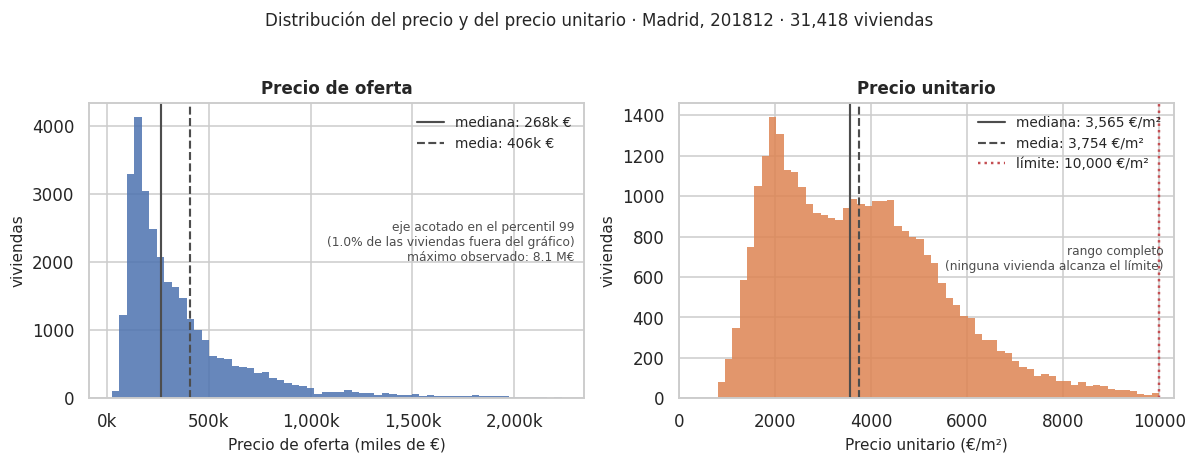

In [165]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel izquierdo: el precio requiere acotación por la extensión de su cola.
ax = axes[0]
corte = madrid.PRICE.quantile(.99)
datos = madrid.loc[madrid.PRICE <= corte, 'PRICE']

sns.histplot(datos, bins=60, color=COLOR_PRECIO, edgecolor='none',
             alpha=.85, ax=ax)
ax.axvline(madrid.PRICE.median(), color=COLOR_REF, ls='-',  lw=1.4,
           label=f'mediana: {madrid.PRICE.median() / 1000:,.0f}k €')
ax.axvline(madrid.PRICE.mean(),   color=COLOR_REF, ls='--', lw=1.4,
           label=f'media: {madrid.PRICE.mean() / 1000:,.0f}k €')
ax.xaxis.set_major_formatter(FORMATO_MILES)
ax.set_xlabel('Precio de oferta (miles de €)')
ax.set_ylabel('viviendas')
ax.set_title('Precio de oferta')
ax.legend(frameon=False, loc='upper right')
ax.text(.98, .60, f'eje acotado en el percentil 99\n'
                  f'({1 - len(datos) / len(madrid):.1%} de las viviendas fuera '
                  f'del gráfico)\n'
                  f'máximo observado: {madrid.PRICE.max() / 1e6:.1f} M€',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=8, color=COLOR_REF)

# Panel derecho: rango completo. La distribución no presenta cola extendida
# y la acotación ocultaría el comportamiento en el límite superior.
ax = axes[1]
sns.histplot(madrid.UNITPRICE, bins=60, color=COLOR_UNITARIO, edgecolor='none',
             alpha=.85, ax=ax)
ax.axvline(madrid.UNITPRICE.median(), color=COLOR_REF, ls='-',  lw=1.4,
           label=f'mediana: {madrid.UNITPRICE.median():,.0f} €/m²')
ax.axvline(madrid.UNITPRICE.mean(),   color=COLOR_REF, ls='--', lw=1.4,
           label=f'media: {madrid.UNITPRICE.mean():,.0f} €/m²')
ax.axvline(LIMITE_UNITARIO, color='#C44E52', ls=':', lw=1.6,
           label=f'límite: {LIMITE_UNITARIO:,} €/m²')
ax.set_xlim(0, LIMITE_UNITARIO * 1.03)
ax.set_xlabel('Precio unitario (€/m²)')
ax.set_ylabel('viviendas')
ax.set_title('Precio unitario')
ax.legend(frameon=False, loc='upper right')
ax.text(.98, .52, 'rango completo\n(ninguna vivienda alcanza el límite)',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=8, color=COLOR_REF)

fig.suptitle(f'Distribución del precio y del precio unitario · Madrid, '
             f'{TRIMESTRE} · {len(madrid):,} viviendas',
             fontsize=11, y=1.04)
fig.tight_layout()

guardar_figura(fig, '01_distribucion_precios')
plt.show()

La representación gráfica añade a la tabla anterior dos elementos que los
estadísticos no recogen.

**La forma de la distribución del precio.** El precio de oferta presenta un
máximo pronunciado en el entorno de los 150.000 euros seguido de un
decrecimiento continuo, sin que se aprecie discontinuidad alguna a lo largo del
recorrido. La distribución responde al patrón habitual de las magnitudes
monetarias: concentración en los valores bajos y cola derecha extendida. La
posición relativa de media y mediana, señaladas sobre el panel, constituye la
lectura visual de la asimetría cuantificada en la tabla.

**La estructura del precio unitario.** El panel derecho revela una circunstancia
que los estadísticos de la tabla no permiten apreciar: la distribución no
presenta un único máximo. Se observan una primera concentración en el entorno de
los 2.000 euros por metro cuadrado y una segunda en torno a los 4.000, separadas
por una región de menor frecuencia. Ambas magnitudes se sitúan a uno y otro lado
de la mediana del conjunto.

La presencia de dos máximos sugiere que el conjunto no describe un mercado
homogéneo sino la superposición de submercados con niveles de precio distintos.
La hipótesis natural atribuye esta estructura a la organización espacial de la
ciudad, con las zonas centrales y las periféricas operando como mercados
diferenciados. El contraste de esta hipótesis corresponde al bloque de análisis
por barrio y distrito, donde la descomposición del precio unitario por zona
permite determinar si los máximos observados se corresponden efectivamente con
agrupaciones territoriales.

De confirmarse, la observación tiene alcance más allá de lo descriptivo: un
modelo lineal sobre el conjunto estimaría un nivel de precio intermedio entre
ambos máximos, poco representativo de cualquiera de los dos submercados, lo que
justifica la incorporación de variables que capturen la posición relativa de la
vivienda dentro de la ciudad.

Se examina el comportamiento de la distribución del precio unitario en las
proximidades de su límite superior y se cuantifica el efecto de la transformación
logarítmica sobre la asimetría de ambas magnitudes.

La primera comprobación distingue entre dos procedimientos de origen con
consecuencias distintas. Si los registros situados por encima del límite hubieran
sido reasignados a este, la distribución presentaría una acumulación anómala en
el último intervalo y el conjunto describiría el mercado completo con una
distorsión en su extremo. Si, por el contrario, la frecuencia decrece de forma
continua hasta el corte, los registros fueron excluidos y el conjunto describe un
subconjunto del mercado delimitado por precio unitario. La segunda interpretación
resulta preferible: una exclusión reduce el ámbito de aplicación del modelo,
mientras que una reasignación introduciría observaciones cuyo valor declarado no
corresponde al real.

La segunda comprobación tiene carácter de diagnóstico anticipado. La
transformación logarítmica constituye el procedimiento habitual para el
tratamiento de variables monetarias asimétricas y subyace a la formulación
clásica de los modelos hedónicos de precios. Su efecto sobre la asimetría se
cuantifica en este punto; la decisión sobre la formulación de la variable
objetivo corresponde al notebook de modelización, donde puede sustentarse en
evidencia de validación.

In [166]:
# Comportamiento de la cola superior del precio unitario
print('DISTRIBUCIÓN EN LAS PROXIMIDADES DEL LÍMITE SUPERIOR')
print(f'  máximo observado: {madrid.UNITPRICE.max():,.2f} €/m²')
print(f'  límite aparente:  {LIMITE_UNITARIO:,} €/m²\n')

tramos = [7000, 7500, 8000, 8500, 9000, 9500, LIMITE_UNITARIO]
etiquetas = [f'{a:,}–{b:,}' for a, b in zip(tramos[:-1], tramos[1:])]
corte = pd.cut(madrid.UNITPRICE, bins=tramos, labels=etiquetas)
conteo = corte.value_counts().sort_index()

print(f'{"tramo (€/m²)":>16s} {"viviendas":>10s} {"% del total":>12s}')
for tramo, n in conteo.items():
    print(f'{tramo:>16s} {n:>10,} {n / len(madrid):>11.2%}')

print(f'\n  viviendas por encima de 9.500 €/m²: {(madrid.UNITPRICE > 9500).sum():,}')
print(f'  viviendas por encima de 9.900 €/m²: {(madrid.UNITPRICE > 9900).sum():,}')

# Efecto de la transformación logarítmica sobre la asimetría
print('\nASIMETRÍA EN ESCALA ORIGINAL Y LOGARÍTMICA')
print(f'{"variable":>18s} {"original":>10s} {"logaritmo":>11s}')
for v in VARS_OBJETIVO:
    print(f'{v:>18s} {madrid[v].skew():>10.2f} {np.log(madrid[v]).skew():>11.2f}')

DISTRIBUCIÓN EN LAS PROXIMIDADES DEL LÍMITE SUPERIOR
  máximo observado: 9,993.38 €/m²
  límite aparente:  10,000 €/m²

    tramo (€/m²)  viviendas  % del total
     7,000–7,500        476       1.52%
     7,500–8,000        344       1.09%
     8,000–8,500        248       0.79%
     8,500–9,000        200       0.64%
     9,000–9,500        127       0.40%
    9,500–10,000         75       0.24%

  viviendas por encima de 9.500 €/m²: 75
  viviendas por encima de 9.900 €/m²: 15

ASIMETRÍA EN ESCALA ORIGINAL Y LOGARÍTMICA
          variable   original   logaritmo
             PRICE       4.20        0.55
         UNITPRICE       0.71       -0.24
   CONSTRUCTEDAREA       3.19        0.52


**Comportamiento en el límite superior.** La distribución del precio unitario
decrece de forma continua hasta su valor máximo, sin presentar acumulación alguna
en las proximidades del límite. Los tramos sucesivos de quinientos euros por
metro cuadrado comprendidos entre los 7.000 y los 10.000 recogen 476, 344, 248,
200, 127 y 75 viviendas respectivamente, y únicamente quince registros superan
los 9.900 euros por metro cuadrado.

El patrón permite descartar la reasignación de los valores superiores al límite,
que produciría una acumulación anómala en el último tramo. Los registros
correspondientes al segmento situado por encima de los 10.000 euros por metro
cuadrado fueron excluidos del conjunto en su origen.

La distinción resulta favorable para el trabajo. Una reasignación habría
introducido observaciones cuyo precio declarado no correspondería al real,
comprometiendo la fiabilidad de la variable objetivo en el extremo superior. La
exclusión, en cambio, no altera ninguno de los registros conservados: delimita el
ámbito de aplicación del modelo sin afectar a la calidad de la información
disponible dentro de dicho ámbito.

**Efecto de la transformación logarítmica.** El coeficiente de asimetría del
precio se reduce de 4,20 a 0,55 al operar sobre su logaritmo, y el de la
superficie construida de 3,19 a 0,52. Ambas magnitudes presentan por tanto un
comportamiento aproximadamente lognormal, patrón habitual en las variables
monetarias y de tamaño.

El resultado aporta sustento empírico a la formulación logarítmica de los modelos
hedónicos de precios, que expresa el logaritmo del valor en función del logaritmo
de las magnitudes de tamaño. Dicha formulación no responde únicamente a una
convención de la disciplina: sobre este conjunto, la transformación produce
distribuciones sensiblemente más regulares.

Procede no obstante delimitar el alcance de la observación. La asimetría
constituye una propiedad de la distribución de la variable considerada de forma
aislada, no de la distribución del error del modelo, que es la magnitud
determinante para la evaluación. Un modelo estimado sobre la variable en su
escala original puede presentar un error correctamente distribuido. La
formulación de la variable objetivo se decide en consecuencia en la fase de
modelización, mediante comparación sobre datos de validación, y la evidencia aquí
recogida se incorpora como argumento de partida.

El logaritmo del precio unitario presenta una asimetría de signo negativo,
consecuencia del truncamiento de su cola derecha documentado en el apartado
anterior. La circunstancia carece de repercusión práctica, dado que la variable
queda excluida del conjunto de predictores.

**Síntesis del apartado 3.1**

- El precio unitario coincide de forma exacta con el cociente entre precio y
  superficie construida. Queda excluido del conjunto de predictores por
  constituir una transformación de la variable objetivo.
- El precio de oferta presenta una asimetría acusada, con una media que supera a
  la mediana en un 52% y una vivienda del percentil 99 que multiplica por 8,3 el
  valor de la vivienda central. La evaluación del modelo requiere medidas de
  error relativo.
- El conjunto contiene vivienda de importe elevado, hasta 8,1 millones de euros,
  pero no de precio unitario elevado. La exclusión practicada en origen afecta al
  segmento de mayor precio por metro cuadrado y no al de mayor importe.
- La distribución del precio unitario presenta dos máximos, en torno a 2.000 y
  4.000 euros por metro cuadrado, lo que sugiere la superposición de submercados
  con niveles de precio distintos. La hipótesis se contrasta en el bloque de
  análisis por barrio y distrito.
- La transformación logarítmica reduce la asimetría del precio de 4,20 a 0,55 y
  la de la superficie de 3,19 a 0,52.

**Elementos que se trasladan a la memoria (apartado 3.1).** Niveles de precio y
superficie de la vivienda mediana, asimetría de la distribución y su implicación
sobre la métrica de evaluación, delimitación precisa del segmento excluido y su
relevancia para el caso de uso, e indicio de estructura de submercados. La
exclusión del precio unitario como predictor se traslada al apartado 5.

**Corrección a introducir en el apartado 2.3 de la memoria.** El texto vigente
afirma que el ámbito de aplicación excluye el segmento premium del mercado
madrileño. La formulación resulta imprecisa: lo excluido es el segmento de precio
unitario superior a 10.000 euros por metro cuadrado, no el de importe elevado,
que permanece representado por vía de la superficie.

### 3.2. Relación entre la superficie y el precio

La superficie construida constituye el determinante inmediato del precio de una
vivienda. Su examen cumple en este trabajo una función que excede la
constatación de dicha relación.

En primer lugar, la proporción de variación del precio atribuible únicamente a la
superficie establece la referencia frente a la que valorar la aportación del
resto de variables. Un modelo de valoración que no supere de forma apreciable esa
referencia carecería de justificación.

En segundo lugar, la forma de la relación condiciona la especificación de los
modelos. Una relación de proporcionalidad estricta admite tratamiento lineal
sobre las variables originales; una relación curva exige transformación previa o
la incorporación de términos no lineales. La formulación logarítmica de ambas
magnitudes permite discriminar entre ambos supuestos: el coeficiente que relaciona
el logaritmo del precio con el de la superficie expresa la elasticidad, esto es,
la variación porcentual del precio asociada a un incremento del uno por ciento en
la superficie. Un valor unitario indica proporcionalidad estricta; un valor
inferior indica que el precio crece menos que proporcionalmente respecto al
tamaño.

En tercer lugar, la relación entre el precio unitario y la superficie tiene
implicaciones directas sobre el caso de uso. El procedimiento de valoración
habitual en ausencia de modelo consiste en aplicar un precio por metro cuadrado
de referencia de la zona a la superficie del inmueble, procedimiento que presupone
la independencia entre ambas magnitudes. Si el precio unitario varía de forma
sistemática con el tamaño, dicho procedimiento incorpora un sesgo cuya dirección
y magnitud conviene cuantificar.

In [167]:
# La relación se estima sobre logaritmos: el coeficiente resultante es la
# elasticidad del precio respecto a la superficie.
log_precio = np.log(madrid.PRICE)
log_area   = np.log(madrid.CONSTRUCTEDAREA)

elasticidad, constante = np.polyfit(log_area, log_precio, 1)
pend, ord_orig = np.polyfit(madrid.CONSTRUCTEDAREA, madrid.PRICE, 1)

def r2(y, y_ajustado):
    """Proporción de varianza explicada, sobre la escala de y."""
    return 1 - ((y - y_ajustado) ** 2).sum() / ((y - y.mean()) ** 2).sum()

pred_lineal = ord_orig + pend * madrid.CONSTRUCTEDAREA
pred_log    = np.exp(constante + elasticidad * log_area)

print('RELACIÓN ENTRE SUPERFICIE Y PRECIO')
print(f'  elasticidad (log-log): {elasticidad:.3f}')
print(f'  un incremento del 1% en superficie se asocia a uno del '
      f'{elasticidad:.2f}% en el precio')
print(f'  duplicar la superficie multiplica el precio por '
      f'{2 ** elasticidad:.2f}\n')

# Varianza explicada. Cada cifra se refiere a la escala de su propia variable
# objetivo y no admite comparación directa con la otra.
print('  Varianza explicada por la superficie, sobre la escala indicada:')
print(f'    del precio, especificación lineal:        '
      f'{r2(madrid.PRICE, pred_lineal):.3f}')
print(f'    del logaritmo del precio, log-log:        '
      f'{r2(log_precio, constante + elasticidad * log_area):.3f}')

# Comparación entre especificaciones sobre una escala común. El error relativo
# es comparable entre ambas y coincide además con el criterio de evaluación
# aplicable a un modelo de valoración. La exponencial del ajuste logarítmico
# estima la mediana condicional, magnitud consistente con una métrica mediana.
print('\n  Error relativo mediano de cada especificación:')
for etiqueta, pred in [('lineal', pred_lineal), ('logarítmica', pred_log)]:
    err = ((pred - madrid.PRICE).abs() / madrid.PRICE).median()
    print(f'    {etiqueta:14s} {err:.1%}')

# La especificación lineal admite predicciones negativas para superficies
# reducidas, circunstancia carente de sentido para un precio de vivienda.
n_neg = (pred_lineal <= 0).sum()
print(f'\n  predicciones no positivas de la especificación lineal: {n_neg:,}')
if n_neg:
    print(f'    superficie máxima con predicción no positiva: '
          f'{madrid.CONSTRUCTEDAREA[pred_lineal <= 0].max():.0f} m²')

print('\n  Correlaciones:')
print(f'    precio – superficie:           '
      f'{madrid.PRICE.corr(madrid.CONSTRUCTEDAREA):.3f}')
print(f'    log precio – log superficie:   {log_precio.corr(log_area):.3f}')
print(f'    precio unitario – superficie:  '
      f'{madrid.UNITPRICE.corr(madrid.CONSTRUCTEDAREA):.3f}   '
      f'(coeficiente lineal; véase el comentario posterior)')

RELACIÓN ENTRE SUPERFICIE Y PRECIO
  elasticidad (log-log): 1.139
  un incremento del 1% en superficie se asocia a uno del 1.14% en el precio
  duplicar la superficie multiplica el precio por 2.20

  Varianza explicada por la superficie, sobre la escala indicada:
    del precio, especificación lineal:        0.744
    del logaritmo del precio, log-log:        0.609

  Error relativo mediano de cada especificación:
    lineal         36.4%
    logarítmica    33.7%

  predicciones no positivas de la especificación lineal: 233
    superficie máxima con predicción no positiva: 27 m²

  Correlaciones:
    precio – superficie:           0.862
    log precio – log superficie:   0.780
    precio unitario – superficie:  0.229   (coeficiente lineal; véase el comentario posterior)


**La superficie no determina el precio de forma proporcional.** La elasticidad
estimada asciende a 1,14: un incremento del uno por ciento en la superficie se
asocia a un incremento del 1,14 por ciento en el precio. Duplicar la superficie
no duplica el valor, sino que lo multiplica por 2,20. El metro cuadrado de las
viviendas de mayor tamaño resulta, en promedio, más caro que el de las viviendas
pequeñas. La divergencia entre la recta ajustada y la recta de proporcionalidad
estricta, visible en el panel izquierdo de la figura, constituye la
representación gráfica de este resultado.

**La superficie explica el 74 por ciento de la varianza del precio, pero deja un
error de valoración inaceptable.** Ambas magnitudes describen el mismo ajuste y
conviene leerlas de forma conjunta. La proporción de varianza explicada se
encuentra dominada por las viviendas de precio elevado, que aportan la mayor
parte de la suma de cuadrados y sobre las que la superficie resulta
particularmente informativa. El error relativo, en cambio, atribuye idéntico peso
a todas las viviendas del conjunto: la estimación basada exclusivamente en la
superficie presenta un error mediano del 33,7 por ciento, equivalente a unos
90.000 euros sobre una vivienda de precio mediano.

La lectura resulta relevante para el planteamiento del trabajo. Una proporción de
varianza explicada del 74 por ciento podría sugerir que la aportación pendiente
del resto de variables es residual. La magnitud del error demuestra lo contrario:
sobre el grueso del mercado, la superficie por sí sola no proporciona una
valoración utilizable, y la referencia frente a la que debe medirse el modelo es
dicho error y no la varianza explicada.

**La especificación logarítmica resulta preferible.** Su error relativo mediano,
del 33,7 por ciento, mejora en 2,7 puntos al de la especificación lineal sobre
las variables originales. La diferencia es moderada, pero la comparación no se
agota en ella: la recta ajustada sobre las variables originales presenta ordenada
en el origen negativa y estima precios no positivos para 233 viviendas del
conjunto, correspondientes a superficies iguales o inferiores a 27 metros
cuadrados. La formulación logarítmica no admite esa posibilidad, dado que su
antitransformación es siempre positiva. Un modelo de valoración que produzca
estimaciones negativas sobre parte de su ámbito de aplicación resulta inviable
con independencia de su precisión agregada.

In [168]:
# Tramos de superficie de tamaño muestral equivalente. Se emplean deciles para
# que la comparación no dependa de puntos de corte fijados de forma arbitraria.
madrid_tmp = madrid.assign(
    TRAMO_AREA=pd.qcut(madrid.CONSTRUCTEDAREA, 10, duplicates='drop')
)

resumen = madrid_tmp.groupby('TRAMO_AREA', observed=True).agg(
    viviendas    =('PRICE', 'size'),
    area_mediana =('CONSTRUCTEDAREA', 'median'),
    precio_med   =('PRICE', 'median'),
    unitario_med =('UNITPRICE', 'median'),
    unitario_p25 =('UNITPRICE', lambda s: s.quantile(.25)),
    unitario_p75 =('UNITPRICE', lambda s: s.quantile(.75)),
    dist_centro  =('DISTANCE_TO_CITY_CENTER', 'median'),
)
resumen['unitario_idx'] = 100 * resumen.unitario_med / madrid.UNITPRICE.median()

display(resumen)

# El precio unitario no varía de forma monótona con la superficie, por lo que la
# comparación entre tramos extremos no describe el comportamiento observado.
# Se localiza el mínimo y se acota el recorrido completo.
imin = resumen.unitario_med.idxmin()

print('PRECIO UNITARIO POR TRAMO DE SUPERFICIE')
print(f'  mediana del conjunto:  {madrid.UNITPRICE.median():>8,.0f} €/m²')
print(f'  primer tramo:          {resumen.unitario_med.iloc[0]:>8,.0f} €/m²   '
      f'(índice {resumen.unitario_idx.iloc[0]:5.1f}, '
      f'{resumen.area_mediana.iloc[0]:.0f} m²)')
print(f'  mínimo:                {resumen.unitario_med.min():>8,.0f} €/m²   '
      f'(índice {resumen.unitario_idx.min():5.1f}, '
      f'{resumen.loc[imin, "area_mediana"]:.0f} m²)')
print(f'  último tramo:          {resumen.unitario_med.iloc[-1]:>8,.0f} €/m²   '
      f'(índice {resumen.unitario_idx.iloc[-1]:5.1f}, '
      f'{resumen.area_mediana.iloc[-1]:.0f} m²)')
print(f'\n  recorrido del índice: {resumen.unitario_idx.min():.0f} a '
      f'{resumen.unitario_idx.max():.0f}   (base 100 = mediana del conjunto)')
print(f'  relación entre el tramo más caro y el más barato: '
      f'{resumen.unitario_med.max() / resumen.unitario_med.min():.2f}')

# Contraste de la hipótesis de confusión con la localización: si el patrón
# observado responde a la distribución espacial de los tipos de vivienda, la
# distancia al centro debe describir el perfil inverso al del precio unitario.
print('\nDISTANCIA AL CENTRO POR TRAMO DE SUPERFICIE')
print(f'  {"superficie (m²)":>16s} {"€/m²":>9s} {"índice":>8s} {"dist. centro (km)":>19s}')
for tramo, fila in resumen.iterrows():
    print(f'  {fila.area_mediana:>16.0f} {fila.unitario_med:>9,.0f} '
          f'{fila.unitario_idx:>8.1f} {fila.dist_centro:>19.2f}')

correlacion = resumen.unitario_med.corr(resumen.dist_centro)
print(f'\n  correlación entre precio unitario y distancia al centro, '
      f'sobre los diez tramos: {correlacion:.3f}')

,viviendas,area_mediana,precio_med,unitario_med,unitario_p25,unitario_p75,dist_centro,unitario_idx
TRAMO_AREA,,,,,,,,
"(20.999, 48.0]",3228,40.00,"169,000.00","4,580.56","3,478.69","5,657.14",2.58,128.50
"(48.0, 58.0]",3124,54.00,"168,000.00","3,144.16","2,259.81","4,640.38",4.31,88.20
"(58.0, 65.0]",3075,62.00,"161,000.00","2,600.00","1,952.00","4,113.83",4.71,72.94
"(65.0, 74.0]",3258,70.00,"183,000.00","2,594.59","1,956.52","4,191.63",4.60,72.79
"(74.0, 82.0]",3150,78.00,"212,000.00","2,687.50","1,948.72","4,087.50",4.68,75.39
"(82.0, 94.0]",3196,89.00,"267,000.00","3,011.70","2,068.77","4,294.12",4.78,84.49
"(94.0, 109.0]",3074,100.00,"331,000.00","3,258.87","2,200.00","4,378.95",4.75,91.42
"(109.0, 130.0]",3244,119.00,"438,000.00","3,681.25","2,638.46","4,858.59",4.28,103.27
"(130.0, 170.0]",2935,147.00,"637,000.00","4,295.60","3,418.05","5,187.69",3.21,120.51


PRECIO UNITARIO POR TRAMO DE SUPERFICIE
  mediana del conjunto:     3,565 €/m²
  primer tramo:             4,581 €/m²   (índice 128.5, 40 m²)
  mínimo:                   2,595 €/m²   (índice  72.8, 70 m²)
  último tramo:             4,685 €/m²   (índice 131.4, 226 m²)

  recorrido del índice: 73 a 131   (base 100 = mediana del conjunto)
  relación entre el tramo más caro y el más barato: 1.81

DISTANCIA AL CENTRO POR TRAMO DE SUPERFICIE
   superficie (m²)      €/m²   índice   dist. centro (km)
                40     4,581    128.5                2.58
                54     3,144     88.2                4.31
                62     2,600     72.9                4.71
                70     2,595     72.8                4.60
                78     2,688     75.4                4.68
                89     3,012     84.5                4.78
               100     3,259     91.4                4.75
               119     3,681    103.3                4.28
               147     4,296    120.5

La representación de la relación se articula en dos paneles.

El panel izquierdo recoge la relación entre superficie y precio en escala
logarítmica sobre ambos ejes. La elección responde a dos motivos. El primero es
que dicha escala convierte una relación potencial en una recta, de modo que la
pendiente observada admite lectura directa como elasticidad y la desviación
respecto de la linealidad resulta visible. El segundo es que ambas magnitudes
presentan una concentración acusada en sus valores bajos, circunstancia que en
escala original comprimiría la práctica totalidad de las observaciones en una
esquina del gráfico.

Dado el volumen de observaciones, la representación mediante puntos individuales
produciría una mancha uniforme sin información aprovechable. Se emplea en su lugar
una representación por celdas hexagonales, en la que la intensidad del color
indica el número de viviendas contenidas en cada celda. Sobre ella se superponen
la recta ajustada y la recta de proporcionalidad estricta, cuya divergencia
constituye la lectura visual de la elasticidad estimada.

El panel derecho representa el precio unitario mediano por decil de superficie,
acompañado del recorrido intercuartílico de cada tramo. La representación permite
determinar si la variación del precio unitario con el tamaño constituye una
tendencia sistemática o queda absorbida por la dispersión interna de los tramos.

figura guardada: 02_superficie_precio.png


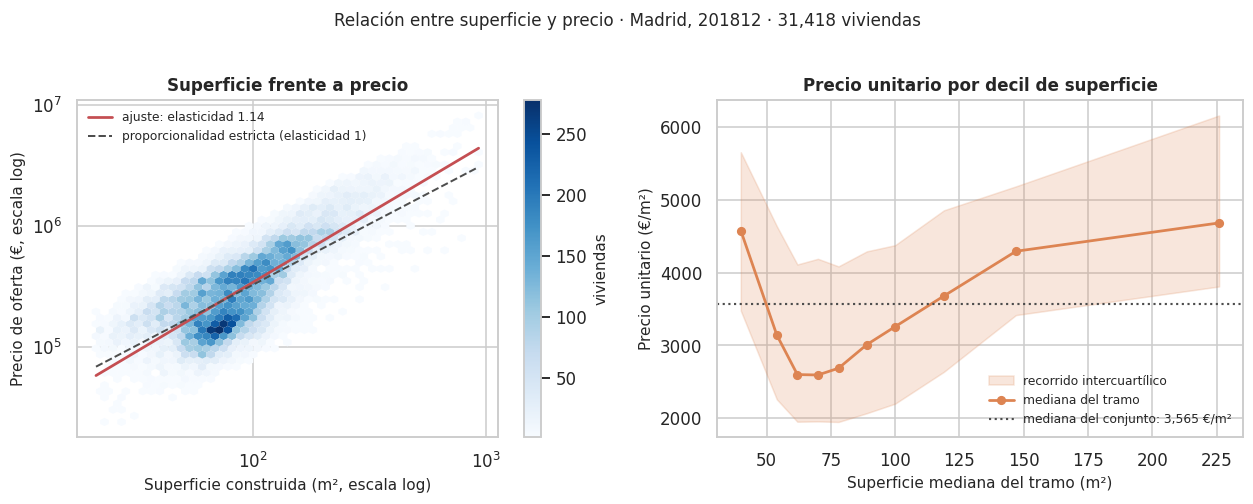

In [169]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

# --- Panel izquierdo: superficie frente a precio, escala logarítmica ---
ax = axes[0]
hb = ax.hexbin(madrid.CONSTRUCTEDAREA, madrid.PRICE,
               gridsize=45, xscale='log', yscale='log',
               cmap='Blues', mincnt=1, linewidths=0)

rejilla = np.linspace(log_area.min(), log_area.max(), 100)
ax.plot(np.exp(rejilla), np.exp(constante + elasticidad * rejilla),
        color='#C44E52', lw=1.8,
        label=f'ajuste: elasticidad {elasticidad:.2f}')

# Recta de proporcionalidad estricta, anclada en la vivienda mediana
ancla = np.log(madrid.PRICE.median()) - 1.0 * np.log(madrid.CONSTRUCTEDAREA.median())
ax.plot(np.exp(rejilla), np.exp(ancla + 1.0 * rejilla),
        color=COLOR_REF, lw=1.3, ls='--',
        label='proporcionalidad estricta (elasticidad 1)')

ax.set_xlabel('Superficie construida (m², escala log)')
ax.set_ylabel('Precio de oferta (€, escala log)')
ax.set_title('Superficie frente a precio')
ax.legend(frameon=False, loc='upper left', fontsize=8)
fig.colorbar(hb, ax=ax, label='viviendas')

# --- Panel derecho: precio unitario por decil de superficie ---
ax = axes[1]
x = resumen.area_mediana.to_numpy()

ax.fill_between(x, resumen.unitario_p25, resumen.unitario_p75,
                color=COLOR_UNITARIO, alpha=.20,
                label='recorrido intercuartílico')
ax.plot(x, resumen.unitario_med, marker='o', ms=5,
        color=COLOR_UNITARIO, lw=1.8, label='mediana del tramo')
ax.axhline(madrid.UNITPRICE.median(), color=COLOR_REF, ls=':', lw=1.4,
           label=f'mediana del conjunto: {madrid.UNITPRICE.median():,.0f} €/m²')

ax.set_xlabel('Superficie mediana del tramo (m²)')
ax.set_ylabel('Precio unitario (€/m²)')
ax.set_title('Precio unitario por decil de superficie')
ax.legend(frameon=False, loc='best', fontsize=8)

fig.suptitle(f'Relación entre superficie y precio · Madrid, {TRIMESTRE} · '
             f'{len(madrid):,} viviendas', fontsize=11, y=1.03)
fig.tight_layout()

guardar_figura(fig, '02_superficie_precio')
plt.show()

**El precio unitario describe una U respecto al tamaño.** El metro cuadrado no
se abarata de forma sostenida al crecer la vivienda: parte de 4.581 euros en el
decil inferior —40 metros cuadrados—, desciende hasta un mínimo de 2.595 en el
entorno de los 70 y vuelve a subir hasta 4.685 en el decil superior, de 226. Un
factor de 1,81 entre los extremos.

La causa es la localización, no el tamaño. La distancia mediana al centro
describe el perfil inverso sobre los mismos diez tramos —2,58 kilómetros, 4,78 y
2,89 respectivamente—, con una correlación de −0,935 entre ambas series. La
consecuencia es doble: el procedimiento de valoración habitual, que aplica un
precio unitario de zona a la superficie, presupone una independencia entre ambas
magnitudes que no se cumple; y el patrón reaparece con la antigüedad del
edificio en el apartado 3.5 y con las variables de contexto del bloque 7, de
modo que en Madrid buena parte de lo que aparenta medir otra cosa acaba midiendo
centralidad.

**Síntesis del apartado 3.2**

- La elasticidad del precio respecto a la superficie asciende a 1,14. La relación
  no es de proporcionalidad estricta: duplicar la superficie multiplica el precio
  por 2,20.
- La superficie explica el 74 por ciento de la varianza del precio, si bien la
  valoración basada únicamente en ella presenta un error relativo mediano del
  33,7 por ciento. La segunda magnitud constituye la referencia pertinente para
  un modelo de valoración.
- La especificación logarítmica resulta preferible a la lineal sobre las
  variables originales, tanto por su menor error como por no admitir estimaciones
  negativas, que la especificación lineal produce sobre 233 viviendas del
  conjunto.
- El precio unitario describe una relación en U respecto a la superficie, con un
  recorrido de 2.595 a 4.685 euros por metro cuadrado entre tramos. El patrón se
  atribuye a la asociación entre tamaño y localización, hipótesis sustentada por
  el perfil inverso de la distancia al centro.
- El coeficiente de correlación lineal no detecta dicho patrón, circunstancia que
  condiciona el diseño de la exploración bivariante del apartado 3.4.

**Elementos que se trasladan a la memoria (apartado 3.1).** Elasticidad,
proporción de varianza explicada y error relativo de la valoración basada
únicamente en la superficie, como referencia frente a la que valorar el modelo.
Existencia de submercados asociados a la localización, como fundamento del
enriquecimiento geoespacial.

**Elementos que se trasladan al apartado 6.1.** La formulación logarítmica como
especificación de partida, con el argumento de las estimaciones negativas. El
error relativo mediano del 33,7 por ciento como referencia inicial, cuya
cuantificación definitiva corresponde realizarse sobre datos de validación.

### 3.3. Naturaleza, calidad y distribución de las variables

Antes de describir las variables se elimina el identificador de la vivienda, que
cumplió su función en el bloque 2 al sustentar la deduplicación y no constituye
una variable explicativa: presenta un valor distinto por registro y carece de
contenido aritmético o categórico aprovechable.

Las variables se clasifican en numéricas y categóricas atendiendo a su
naturaleza estadística, que no coincide necesariamente con su tipo de dato.

El conjunto almacena como enteros dos clases de variables que no admiten
tratamiento numérico. La primera la constituyen las etiquetas: la ubicación del
piso dentro del edificio y la calidad catastral se codifican mediante valores
enteros que identifican categorías, de modo que su orden puede resultar
significativo pero su aritmética carece de sentido. La segunda la constituyen los
indicadores de presencia o ausencia de un atributo, codificados como cero y uno,
que constituyen variables categóricas de dos niveles: la media de una de estas
variables expresa la proporción de viviendas que declaran el atributo, no un
valor promedio, y sus medidas de dispersión y sus cuantiles carecen de
interpretación.

Los indicadores binarios se identifican mediante comprobación del conjunto de
valores observados en cada columna, en lugar de por enumeración manual. El
procedimiento resulta preferible por dos motivos: no depende del criterio de
denominación de las variables y detectaría cualquier columna que, pese a
describir un atributo binario, contuviera valores distintos de cero y uno.

La comprobación final verifica que la suma de ambos grupos, junto a la columna de
geometría, agota el conjunto de columnas disponibles.

In [170]:
# ASSETID cumplió su función en el bloque 2, donde sustentó la deduplicación.
if 'ASSETID' in madrid.columns:
    madrid = madrid.drop(columns='ASSETID')
    print('ASSETID eliminada.')
else:
    print('ASSETID ya estaba eliminada.')

geom = madrid.geometry.name

# Etiquetas codificadas numéricamente e indicadores binarios, con independencia
# de que estos últimos empleen la codificación 0/1 u otra.
ETIQUETAS = ['FLATLOCATIONID', 'CADASTRALQUALITYID', 'AMENITYID']

CATEGORICAS = [c for c in madrid.columns
               if c in ETIQUETAS
               or (c != geom and madrid[c].dropna().isin([0, 1]).all())]

NUMERICAS = [c for c in madrid.columns if c not in CATEGORICAS + [geom]]

print(f'\nCATEGÓRICAS ({len(CATEGORICAS)})')
for i in range(0, len(CATEGORICAS), 3):
    print(f'    {", ".join(CATEGORICAS[i:i + 3])}')

print(f'\nNUMÉRICAS ({len(NUMERICAS)})')
for i in range(0, len(NUMERICAS), 3):
    print(f'    {", ".join(NUMERICAS[i:i + 3])}')

print(f'\ncolumnas: {madrid.shape[1]}  |  categóricas: {len(CATEGORICAS)}  |  '
      f'numéricas: {len(NUMERICAS)}  |  geometría: 1')
assert len(CATEGORICAS) + len(NUMERICAS) + 1 == madrid.shape[1]

print('\nniveles de cada categórica:')
for c in CATEGORICAS:
    print(f'  {c:32s} {madrid[c].nunique():>3,}')

ASSETID eliminada.

CATEGÓRICAS (23)
    HASTERRACE, HASLIFT, HASAIRCONDITIONING
    AMENITYID, HASPARKINGSPACE, ISPARKINGSPACEINCLUDEDINPRICE
    HASNORTHORIENTATION, HASSOUTHORIENTATION, HASEASTORIENTATION
    HASWESTORIENTATION, HASBOXROOM, HASWARDROBE
    HASSWIMMINGPOOL, HASDOORMAN, HASGARDEN
    ISDUPLEX, ISSTUDIO, ISINTOPFLOOR
    FLATLOCATIONID, CADASTRALQUALITYID, BUILTTYPEID_1
    BUILTTYPEID_2, BUILTTYPEID_3

NUMÉRICAS (16)
    PRICE, UNITPRICE, CONSTRUCTEDAREA
    ROOMNUMBER, BATHNUMBER, PARKINGSPACEPRICE
    CONSTRUCTIONYEAR, FLOORCLEAN, CADCONSTRUCTIONYEAR
    CADMAXBUILDINGFLOOR, CADDWELLINGCOUNT, DISTANCE_TO_CITY_CENTER
    DISTANCE_TO_METRO, DISTANCE_TO_CASTELLANA, LONGITUDE
    LATITUDE

columnas: 40  |  categóricas: 23  |  numéricas: 16  |  geometría: 1

niveles de cada categórica:
  HASTERRACE                         2
  HASLIFT                            2
  HASAIRCONDITIONING                 2
  AMENITYID                          3
  HASPARKINGSPACE               

Se describen las variables numéricas mediante sus estadísticos de posición y
dispersión, junto a dos indicadores adicionales. La proporción de valores
distintos permite detectar variables con variabilidad insuficiente, criterio
habitual de descarte cuando se sitúa por debajo del cinco por ciento en conjuntos
de este tamaño. El recuento de valores ausentes se recoge con carácter
diagnóstico: la cifra no es definitiva, dado que las comprobaciones posteriores
pueden revelar valores imposibles que constituyan ausentes codificados
numéricamente.

Las proporciones difieren de las recogidas en el apartado 1.6, que se
calcularon sobre los 94.815 anuncios del ejercicio completo, mientras que las
de este apartado se refieren ya al conjunto de trabajo. El año de construcción
declarado, por ejemplo, pasa del 58,93% de ausentes al 56,31%: la diferencia
procede del filtro temporal y de la deduplicación, no de un cambio de
criterio.

In [171]:
desc = madrid[NUMERICAS].describe(percentiles=[.01, .25, .50, .75, .99]).T
desc['nulos_%']    = 100 * madrid[NUMERICAS].isna().mean()
desc['distintos']  = madrid[NUMERICAS].nunique()
desc['distintos_%'] = 100 * desc['distintos'] / len(madrid)

COLS = ['count', 'nulos_%', 'distintos', 'distintos_%',
        'mean', 'std', 'min', '1%', '50%', '99%', 'max']
display(desc[COLS].round(2))

print('Variables con menos del 5% de valores distintos:')
poca = desc[desc['distintos_%'] < 5].index.tolist()
print(f'  {", ".join(poca) if poca else "ninguna"}')

print('\nVariables con valores ausentes:')
con_nulos = desc[desc['nulos_%'] > 0].sort_values('nulos_%', ascending=False)
for c, fila in con_nulos.iterrows():
    print(f'  {c:24s} {fila["nulos_%"]:5.2f}%  ({int(len(madrid) - fila["count"]):,} registros)')

,count,nulos_%,distintos,distintos_%,mean,std,min,1%,50%,99%,max
PRICE,"31,418.00",0.00,2083,6.63,"406,265.83","432,703.76","24,000.00","75,000.00","268,000.00","2,232,000.00","8,133,000.00"
UNITPRICE,"31,418.00",0.00,16219,51.62,"3,754.12","1,725.95",805.56,"1,133.33","3,564.61","8,696.73","9,993.38"
CONSTRUCTEDAREA,"31,418.00",0.00,488,1.55,101.12,67.34,21.00,29.17,82.00,367.00,934.00
ROOMNUMBER,"31,418.00",0.00,18,0.06,2.56,1.21,0.00,0.00,3.00,6.00,18.00
BATHNUMBER,"31,418.00",0.00,16,0.05,1.59,0.85,0.00,1.00,1.00,5.00,18.00
PARKINGSPACEPRICE,"31,418.00",0.00,91,0.29,782.57,"9,008.58",1.00,1.00,1.00,"30,001.00","925,001.00"
CONSTRUCTIONYEAR,"13,728.00",56.31,157,0.50,"1,965.40",42.86,19.00,"1,880.00","1,968.00","2,018.00","2,020.00"
FLOORCLEAN,"30,089.00",4.23,13,0.04,2.74,2.23,-1.00,0.00,2.00,11.00,11.00
CADCONSTRUCTIONYEAR,"31,418.00",0.00,154,0.49,"1,965.59",28.93,"1,700.00","1,886.00","1,967.00","2,018.00","2,018.00"
CADMAXBUILDINGFLOOR,"31,418.00",0.00,26,0.08,6.38,2.85,0.00,2.00,6.00,16.00,26.00


Variables con menos del 5% de valores distintos:
  CONSTRUCTEDAREA, ROOMNUMBER, BATHNUMBER, PARKINGSPACEPRICE, CONSTRUCTIONYEAR, FLOORCLEAN, CADCONSTRUCTIONYEAR, CADMAXBUILDINGFLOOR, CADDWELLINGCOUNT

Variables con valores ausentes:
  CONSTRUCTIONYEAR         56.31%  (17,690 registros)
  FLOORCLEAN                4.23%  (1,329 registros)


Se verifican a continuación los rangos observados frente a los valores
admisibles. La comprobación persigue identificar dos situaciones distintas:
registros imposibles, atribuibles a errores en el dato de origen, y valores
ausentes codificados mediante un número convencional, habitualmente el cero, que
no figuran como tales en el recuento anterior.

Las condiciones se formulan de forma explícita para cada variable, atendiendo a
su significado. Su tratamiento corresponde al bloque de calidad del dato.

In [172]:
print('PARKINGSPACEPRICE: naturaleza del valor mínimo')
vc = madrid.PARKINGSPACEPRICE.value_counts().sort_index()
print(f'  valor 1: {vc.get(1, 0):,} registros ({vc.get(1, 0) / len(madrid):.1%})')
print(f'  valores distintos por encima de 1: {(madrid.PARKINGSPACEPRICE > 1).sum():,}')
print('\n  diez valores más frecuentes:')
print(madrid.PARKINGSPACEPRICE.value_counts().head(10).to_string())
print('\n  cruce con HASPARKINGSPACE:')
print(pd.crosstab(madrid.PARKINGSPACEPRICE > 1, madrid.HASPARKINGSPACE).to_string())

print('\n\nFLOORCLEAN: censura del recorrido')
print(madrid.FLOORCLEAN.value_counts(dropna=False).sort_index().to_string())
print(f'\n  altura máxima del edificio (CADMAXBUILDINGFLOOR): '
      f'{madrid.CADMAXBUILDINGFLOOR.max():.0f}')
print(f'  viviendas en edificios de más de 11 plantas: '
      f'{(madrid.CADMAXBUILDINGFLOOR > 11).sum():,}')

print('\n\nINCOHERENCIA ENTRE PLANTA Y ALTURA DEL EDIFICIO')
inc = madrid.FLOORCLEAN > madrid.CADMAXBUILDINGFLOOR
print(f'  total: {inc.sum():,}')
print(f'  de los cuales, edificios con 0 plantas declaradas: '
      f'{(inc & (madrid.CADMAXBUILDINGFLOOR == 0)).sum():,}')
print(f'  resto: {(inc & (madrid.CADMAXBUILDINGFLOOR > 0)).sum():,}')
print('\n  distribución del exceso de plantas:')
print((madrid.FLOORCLEAN - madrid.CADMAXBUILDINGFLOOR)[inc]
      .value_counts().sort_index().to_string())

print('\n\nVARIABILIDAD: peso del valor dominante')
print('  (criterio: una variable no discrimina si un valor concentra >95%)')
for c in NUMERICAS:
    p = madrid[c].value_counts(normalize=True, dropna=False).max()
    marca = '  <-- ' if p > .95 else '      '
    print(f'{marca}{c:26s} {p:6.1%}')

PARKINGSPACEPRICE: naturaleza del valor mínimo
  valor 1: 30,661 registros (97.6%)
  valores distintos por encima de 1: 757

  diez valores más frecuentes:
PARKINGSPACEPRICE
1        30661
30001       81
20001       69
25001       65
40001       60
15001       59
50001       44
45001       34
35001       28
18001       23

  cruce con HASPARKINGSPACE:
HASPARKINGSPACE        0     1
PARKINGSPACEPRICE             
False              23681  6980
True                 757     0


FLOORCLEAN: censura del recorrido
FLOORCLEAN
-1.00     300
0.00     3344
1.00     6584
2.00     5715
3.00     4932
4.00     3978
5.00     2035
6.00     1214
7.00      802
8.00      439
9.00      282
10.00     125
11.00     339
NaN      1329

  altura máxima del edificio (CADMAXBUILDINGFLOOR): 26
  viviendas en edificios de más de 11 plantas: 1,733


INCOHERENCIA ENTRE PLANTA Y ALTURA DEL EDIFICIO
  total: 758
  de los cuales, edificios con 0 plantas declaradas: 26
  resto: 732

  distribución del exceso de plantas:

In [173]:
CONDICIONES = {
    'PRICE':               (madrid.PRICE <= 0,                'precio nulo o negativo'),
    'CONSTRUCTEDAREA':     (madrid.CONSTRUCTEDAREA <= 0,      'superficie nula o negativa'),
    'ROOMNUMBER':          (madrid.ROOMNUMBER < 0,            'dormitorios negativos'),
    'ROOMNUMBER ':         (madrid.ROOMNUMBER > 15,           'más de 15 dormitorios'),
    'BATHNUMBER':          (madrid.BATHNUMBER <= 0,           'cero baños o negativo'),
    'BATHNUMBER ':         (madrid.BATHNUMBER > 10,           'más de 10 baños'),
    'CADCONSTRUCTIONYEAR': (madrid.CADCONSTRUCTIONYEAR < 1800, 'anterior a 1800'),
    'CADCONSTRUCTIONYEAR ':(madrid.CADCONSTRUCTIONYEAR > 2018, 'posterior al periodo'),
    'CADMAXBUILDINGFLOOR': (madrid.CADMAXBUILDINGFLOOR <= 0,  'plantas del edificio nulas'),
    'CADDWELLINGCOUNT':    (madrid.CADDWELLINGCOUNT <= 0,     'viviendas del edificio nulas'),
    'FLOORCLEAN':          (madrid.FLOORCLEAN < -1,           'planta inferior a -1'),
    'AMENITYID':           (~madrid.AMENITYID.isin([1, 2, 3]), 'nivel de equipamiento no previsto'),
    'FLATLOCATIONID':      (~madrid.FLATLOCATIONID.isin([1, 2]) & madrid.FLATLOCATIONID.notna(),
                            'tipo de vistas no previsto'),
    'CADASTRALQUALITYID':  (~madrid.CADASTRALQUALITYID.between(0, 9)
                            & madrid.CADASTRALQUALITYID.notna(),
                            'calidad catastral fuera de escala'),
}

print('VERIFICACIÓN DE RANGOS\n')
incidencias = {}
for etiqueta, (cond, motivo) in CONDICIONES.items():
    n = cond.sum()
    marca = '  <-- ' if n else '      '
    print(f'{marca}{motivo:36s} {n:>6,} registros')
    if n:
        incidencias[etiqueta.strip()] = incidencias.get(etiqueta.strip(), 0) + n

if incidencias:
    print('\nVariables afectadas:')
    for c, n in incidencias.items():
        print(f'  {c:24s} {n:>6,} registros ({n / len(madrid):.2%})')
else:
    print('\nNo se detectan valores fuera de rango.')

# Coherencia entre variables. La superficie por dormitorio no admite umbral
# aplicable, dado que ROOMNUMBER excluye las estancias no destinadas a dormir.
print('\nCOHERENCIA ENTRE VARIABLES')
inc1 = (madrid.FLOORCLEAN > madrid.CADMAXBUILDINGFLOOR).sum()
inc2 = ((madrid.ROOMNUMBER == 0) & (madrid.ISSTUDIO == 0)).sum()
inc3 = ((madrid.ISSTUDIO == 1) & (madrid.ROOMNUMBER > 1)).sum()
print(f'  planta superior a la altura del edificio:        {inc1:>6,}')
print(f'  sin dormitorios y no declarada como estudio:     {inc2:>6,}')
print(f'  declarada como estudio con más de un dormitorio: {inc3:>6,}')

# Codificación de las variables sobre las que la documentación advierte.
print('\nCODIFICACIÓN DE LOS BLOQUES DE INDICADORES')
print('  Orientación (la documentación advierte que no son excluyentes):')
ORIENT = ['HASNORTHORIENTATION', 'HASSOUTHORIENTATION',
          'HASEASTORIENTATION', 'HASWESTORIENTATION']
print(madrid[ORIENT].sum(axis=1).value_counts().sort_index()
      .rename('viviendas').to_frame().to_string())
print(f'  sin orientación declarada: {(madrid[ORIENT].sum(axis=1) == 0).mean():.1%}')

print('\n  Tipo de obra (¿partición completa?):')
BT = ['BUILTTYPEID_1', 'BUILTTYPEID_2', 'BUILTTYPEID_3']
print(f'  filas que suman 1: {(madrid[BT].sum(axis=1) == 1).mean():.1%}')
for c, e in zip(BT, ['obra nueva', 'segunda mano a reformar',
                     'segunda mano en buen estado']):
    print(f'    {e:30s} {madrid[c].mean():6.1%}')

print('\n  Aparcamiento (la documentación asigna idéntica definición a ambas):')
print(f'  HASPARKINGSPACE e ISPARKINGSPACEINCLUDEDINPRICE idénticas: '
      f'{(madrid.HASPARKINGSPACE == madrid.ISPARKINGSPACEINCLUDEDINPRICE).all()}')
# El examen detallado de PARKINGSPACEPRICE se realiza en la celda siguiente.

VERIFICACIÓN DE RANGOS

      precio nulo o negativo                    0 registros
      superficie nula o negativa                0 registros
      dormitorios negativos                     0 registros
  <-- más de 15 dormitorios                     3 registros
  <-- cero baños o negativo                    23 registros
  <-- más de 10 baños                           9 registros
  <-- anterior a 1800                           3 registros
      posterior al periodo                      0 registros
  <-- plantas del edificio nulas               27 registros
      viviendas del edificio nulas              0 registros
      planta inferior a -1                      0 registros
      nivel de equipamiento no previsto         0 registros
      tipo de vistas no previsto                0 registros
      calidad catastral fuera de escala         0 registros

Variables afectadas:
  ROOMNUMBER                    3 registros (0.01%)
  BATHNUMBER                   32 registros (0.10%)
  CADCONST

> **Hallazgo — `PARKINGSPACEPRICE` no describe la vivienda anunciada**
>
> La documentación define la variable como el precio de la plaza de
> aparcamiento en euros, sin más precisión. El examen del conjunto revela que el
> 97,6% de los registros presenta el valor 1, que opera como código de ausencia.
> Los 757 registros con precio efectivo corresponden en su totalidad a anuncios
> que declaran no incluir plaza, mientras que ninguna de las 6.980 viviendas que
> sí la declaran presenta precio asociado.
>
> La variable registra por tanto el importe de una plaza ofertada de forma
> independiente y no un atributo de la vivienda objeto de valoración. Se descarta.
>
> `ISPARKINGSPACEINCLUDEDINPRICE` coincide además exactamente con
> `HASPARKINGSPACE` en la totalidad de los registros, circunstancia coherente con
> la definición idéntica que la documentación atribuye a ambas. Se conserva
> únicamente la segunda. La información sobre plaza de aparcamiento queda
> reducida a un único indicador.

> **Hallazgo — La planta está censurada en el valor 11**
>
> La documentación describe `FLOORCLEAN` como el número de planta a partir del
> valor cero para la planta baja, sin mencionar limitación alguna de su
> recorrido. El conjunto no la respeta: la frecuencia decrece de forma continua
> desde la primera planta hasta la décima, que recoge 125 viviendas, y repunta
> hasta 339 en la undécima. Existen 1.733 viviendas en edificios de más de once
> plantas, por lo que necesariamente hay registros de plantas superiores
> agrupados en dicho valor.
>
> A diferencia del truncamiento del precio unitario, que operó por exclusión de
> registros, esta censura opera por agrupación: las viviendas permanecen en el
> conjunto con su planta recodificada. La variable no permite en consecuencia
> distinguir entre plantas altas dentro del segmento de edificios de mayor
> altura, precisamente donde el efecto de la altura sobre el precio resulta más
> acusado. Limitación no documentada, a declarar en la memoria.

> **Hallazgo — Discrepancia entre la planta declarada y la altura catastral**
>
> En 758 registros la planta declarada supera la altura del edificio según
> catastro. De ellos, 26 corresponden a edificios con altura declarada nula, que
> constituyen error de origen. Los 732 restantes presentan excesos reducidos: 378
> de una sola planta y 190 de dos.
>
> La documentación advierte que ambas magnitudes proceden de fuentes distintas,
> el anunciante y el catastro, y que pueden diferir. La distribución del exceso
> resulta compatible con una discrepancia de criterio en el cómputo de la planta
> baja o de las plantas retranqueadas, si bien la hipótesis no admite
> verificación con los datos disponibles. Los 732 registros se conservan sin
> modificación al no existir criterio para determinar cuál de las dos fuentes
> corregir.

La verificación confirma los dos extremos sobre los que advierte la
documentación. Los indicadores de orientación admiten valores simultáneos —5.194
viviendas declaran dos, 492 tres y 271 las cuatro— por lo que no procede su
tratamiento como conjunto excluyente; el 51,3% no declara ninguna, de modo que el
valor cero indica ausencia de declaración y no ausencia del atributo. Los tres
indicadores de tipo de obra, en cambio, suman la unidad en la totalidad de los
registros y constituyen una partición completa, lo que implica dependencia lineal
entre ellos y exige la supresión de uno como categoría de referencia en los
modelos que lo requieran.

La verificación de rangos identifica 65 registros con valores imposibles: 3 con
más de quince dormitorios, 32 con recuento de baños nulo o superior a diez, 3 con
año de construcción catastral anterior a 1800 y 27 con altura de edificio nula.
Su conversión a valor ausente corresponde al bloque de calidad del dato, tras la
cual procede recalcular el recuento de ausentes.

Las variables cuya codificación describe la documentación la respetan sin
excepción: el nivel de equipamiento se limita a los tres valores previstos, el
tipo de vistas a los dos suyos y la planta no desciende por debajo de −1, valor
correspondiente a las situadas bajo rasante.

Dos comprobaciones de coherencia arrojan incidencias de escasa entidad. En 58
registros la vivienda no declara dormitorio alguno sin figurar como estudio, y en
2 se declara como estudio pese a consignar más de un dormitorio. El primer caso
no resulta necesariamente erróneo, dado que existen tipologías sin dormitorio
independiente, pero tampoco cabe descartar un valor ausente codificado como cero;
al carecer de criterio para distinguir ambas situaciones y representar el 0,18%
del conjunto, los registros se conservan sin modificación.

El criterio de variabilidad se establece sobre el peso del valor dominante y no
sobre la proporción de valores distintos. Esta última resulta dependiente del
tamaño muestral: sobre 31.418 registros, un umbral del cinco por ciento exigiría
1.571 valores distintos, cifra que ninguna variable discreta puede alcanzar con
independencia de su capacidad discriminante. Bajo el criterio adoptado,
únicamente `PARKINGSPACEPRICE` resulta descartada.

Se describen las variables categóricas mediante la frecuencia de sus niveles. Los
indicadores binarios se presentan como proporción de viviendas que declaran cada
atributo, y las restantes mediante el reparto completo de sus categorías.

La revisión atiende a dos criterios. El primero es la representación de cada
nivel: las categorías con frecuencia inferior al cinco por ciento carecen de base
muestral suficiente para estimar su efecto de forma estable y requieren
agrupación o descarte. El segundo es el peso del nivel mayoritario: un indicador
que concentre más del noventa y cinco por ciento de las observaciones en un único
valor no discrimina entre viviendas.

Procede recordar que estas variables proceden en su mayoría de la declaración del
anunciante y no de fuente verificada, de modo que el valor cero indica ausencia
de declaración y no ausencia del atributo.

In [174]:
BINARIAS = [c for c in CATEGORICAS if madrid[c].dropna().isin([0, 1]).all()]
OTRAS    = [c for c in CATEGORICAS if c not in BINARIAS]

# Indicadores binarios: proporción declarada y peso del nivel mayoritario.
bin_tab = pd.DataFrame({
    'declarado_%': 100 * madrid[BINARIAS].mean(),
    'nulos_%':     100 * madrid[BINARIAS].isna().mean(),
})
bin_tab['dominante_%'] = 100 * bin_tab['declarado_%'].combine(
    100 - bin_tab['declarado_%'], max) / 100
bin_tab = bin_tab.sort_values('declarado_%', ascending=False).round(2)
display(bin_tab)

print('Indicadores con nivel dominante por encima del 95%:')
poco = bin_tab[bin_tab['dominante_%'] > 95].index.tolist()
print(f'  {", ".join(poco) if poco else "ninguno"}')

print('\n\nCATEGÓRICAS NO BINARIAS\n')
for c in OTRAS:
    rep = madrid[c].value_counts(normalize=True, dropna=False).sort_index()
    print(f'{c}  ({madrid[c].nunique()} niveles, '
          f'{100 * madrid[c].isna().mean():.2f}% ausentes)')
    for nivel, p in rep.items():
        marca = ' <--' if p < .05 else ''
        print(f'    {str(nivel):>6s}  {p:7.2%}{marca}')
    minor = (rep[rep.index.notna()] < .05).sum()
    print(f'    niveles por debajo del 5%: {minor}\n')

,declarado_%,nulos_%,dominante_%
BUILTTYPEID_3,77.64,0.00,77.64
HASLIFT,70.06,0.00,70.06
HASWARDROBE,56.81,0.00,56.81
HASAIRCONDITIONING,45.70,0.00,54.30
HASTERRACE,35.53,0.00,64.47
HASDOORMAN,25.31,0.00,74.69
HASBOXROOM,25.13,0.00,74.87
HASSOUTHORIENTATION,23.89,0.00,76.11
HASPARKINGSPACE,22.22,0.00,77.78
ISPARKINGSPACEINCLUDEDINPRICE,22.22,0.00,77.78


Indicadores con nivel dominante por encima del 95%:
  BUILTTYPEID_1, ISSTUDIO, ISDUPLEX, ISINTOPFLOOR


CATEGÓRICAS NO BINARIAS

AMENITYID  (3 niveles, 0.00% ausentes)
         1    0.89% <--
         2    4.77% <--
         3   94.33%
    niveles por debajo del 5%: 2

FLATLOCATIONID  (2 niveles, 6.38% ausentes)
       1.0   80.80%
       2.0   12.81%
       nan    6.38%
    niveles por debajo del 5%: 0

CADASTRALQUALITYID  (10 niveles, 0.00% ausentes)
       0.0    0.39% <--
       1.0    0.69% <--
       2.0    2.96% <--
       3.0   13.65%
       4.0   25.48%
       5.0   21.28%
       6.0   22.29%
       7.0   10.98%
       8.0    1.64% <--
       9.0    0.63% <--
       nan    0.00% <--
    niveles por debajo del 5%: 5



Los indicadores binarios presentan una completitud total y un reparto que en su
mayoría permite la estimación de su efecto. Cuatro de ellos —obra nueva, estudio,
dúplex y ático— concentran más del noventa y cinco por ciento de las
observaciones en un único valor. No procede sin embargo su descarte automático:
sobre un conjunto de 31.418 registros, la categoría minoritaria conserva entre
738 y 1.134 observaciones, base muestral suficiente, y las tipologías que
describen presentan un efecto conocido sobre el valor de la vivienda. Su
conservación se decide en función de su capacidad explicativa efectiva, medida en
el apartado siguiente.

El umbral del cinco por ciento habitualmente empleado procede de conjuntos de
tamaño sensiblemente menor, en los que dicha proporción deja apenas unas decenas
de casos. Su aplicación literal sobre un conjunto de este volumen descartaría
variables con base muestral holgada.

Entre las categóricas no binarias, el nivel de equipamiento concentra el 94,33%
de las viviendas en la categoría superior, que corresponde a cocina equipada y
mobiliario. La agrupación de los dos niveles inferiores, semánticamente
homogéneos por corresponder a viviendas sin mobiliario, produce una categoría del
5,67%.

La calidad catastral presenta una distribución concentrada en los valores
centrales: los niveles 3 a 7 recogen el 93,7% de las observaciones, mientras que
los cinco restantes suman el 6,3%. Al tratarse de una variable ordinal, su
agrupación procede por los extremos de la escala y se determina en función de la
respuesta del precio a cada nivel.

El tipo de vistas presenta un 6,38% de valores ausentes, proporción que aconseja
su tratamiento como categoría propia antes que su imputación.

**Síntesis del apartado 3.3**

- El conjunto se compone de 23 variables categóricas y 16 numéricas, además de la
  geometría. El identificador de la vivienda se elimina por haber agotado su
  función en la deduplicación.
- Se identifican 65 registros con valores imposibles, sobre un total de 31.418.
  Su conversión a valor ausente corresponde al bloque de calidad del dato.
- `PARKINGSPACEPRICE` se descarta por registrar el importe de una plaza
  ofertada de forma independiente y no un atributo de la vivienda valorada.
  Concurre además una variabilidad insuficiente, con el 97,6% de los registros
  en un único valor. `ISPARKINGSPACEINCLUDEDINPRICE` duplica exactamente a
  `HASPARKINGSPACE` y se descarta también.
- La planta se encuentra censurada en el valor 11, circunstancia no recogida en
  la documentación del conjunto.
- Los indicadores de orientación no constituyen categorías excluyentes y
  presentan un 51,3% de viviendas sin declaración alguna.
- Las categorías minoritarias de la calidad catastral admiten agrupación, que
  se determina en el apartado 3.5. El nivel de equipamiento se descarta en el
  3.4 por razón de correlación nula, sin que proceda agruparlo. Ninguna otra
  variable se descarta por la representación de sus niveles.

**Elementos que se trasladan a la memoria.** El descarte de variables y su
motivo, al apartado 5. La censura de la planta y el carácter declarado del
equipamiento, al apartado 2.3 como limitaciones. El detalle de la verificación,
al anexo.

### 3.4. Exploración bivariante y ordenación de las variables explicativas

Se examina la relación de cada variable con el precio, con dos finalidades:
ordenar las variables por su capacidad explicativa y detectar aquellas cuya
relación no es lineal, circunstancia que condiciona su tratamiento en los modelos
que presuponen esa forma.

La ordenación se apoya en la razón de correlación, que expresa como proporción de
varianza explicada la misma descomposición en que se fundamenta el análisis de la
varianza. El procedimiento agrupa las observaciones según los valores de la
variable explicativa —por sus categorías, si es cualitativa, o por deciles, si es
cuantitativa— y mide qué fracción de la varianza del precio queda recogida por
las diferencias entre grupos frente a la dispersión interna de cada uno. Su
principal ventaja reside en no presuponer forma alguna en la relación, a
diferencia del coeficiente de correlación lineal.

La elección responde a la naturaleza continua de la variable objetivo. En modelos
de clasificación, la ordenación de variables se realiza habitualmente mediante el
valor de la información, magnitud que exige una variable objetivo binaria. La
razón de correlación cumple una función equivalente sobre una objetivo continua.

Se emplea el contraste entre ambas medidas como diagnóstico adicional. Una
variable con razón de correlación elevada y correlación lineal reducida presenta
una relación no monótona, según se comprobó en el apartado 3.2 con el precio
unitario y la superficie. La discrepancia identifica las variables que requerirán
transformación o tramificación previa.

El cálculo se realiza sobre el logaritmo del precio, conforme al diagnóstico del
apartado 3.1.

In [175]:
def razon_correlacion(y, grupos):
    """Proporción de la varianza de y explicada por una partición en grupos."""
    df = pd.DataFrame({'y': y, 'g': grupos}).dropna()
    if df.g.nunique() < 2:
        return np.nan
    media = df.y.mean()
    entre = df.groupby('g', observed=True).y.agg(['size', 'mean'])
    ss_entre = (entre['size'] * (entre['mean'] - media) ** 2).sum()
    ss_total = ((df.y - media) ** 2).sum()
    return ss_entre / ss_total


N_TRAMOS = 10
log_precio = np.log(madrid.PRICE)

# Variables a evaluar: todas menos la objetivo, sus derivadas y las descartadas
DESCARTADAS = ['PARKINGSPACEPRICE', 'ISPARKINGSPACEINCLUDEDINPRICE',
               'CONSTRUCTIONYEAR', 'LONGITUDE', 'LATITUDE']
EVALUAR = [c for c in CATEGORICAS + NUMERICAS
           if c not in ['PRICE', 'UNITPRICE'] + DESCARTADAS]

filas = []
for c in EVALUAR:
    if c in CATEGORICAS:
        grupos = madrid[c].astype('object').fillna('(ausente)')
        tipo = 'categórica'
    else:
        grupos = pd.qcut(madrid[c], N_TRAMOS, duplicates='drop')
        tipo = 'numérica'

    eta2 = razon_correlacion(log_precio, grupos)
    r_pearson = log_precio.corr(pd.to_numeric(madrid[c], errors='coerce'))

    filas.append({'variable': c, 'tipo': tipo, 'eta2': eta2,
                  'r_lineal': r_pearson,
                  'r2_lineal': r_pearson ** 2 if pd.notna(r_pearson) else np.nan})

rank = (pd.DataFrame(filas).set_index('variable')
        .sort_values('eta2', ascending=False))
rank['brecha'] = rank.eta2 - rank.r2_lineal

display(rank.round(4))

print('Variables con razón de correlación por debajo de 0,01:')
debiles = rank[rank.eta2 < .01].index.tolist()
print(f'  {", ".join(debiles) if debiles else "ninguna"}')

print('\nVariables con relación no lineal apreciable (brecha > 0,02):')
nolineal = rank[rank.brecha > .02].sort_values('brecha', ascending=False)
for c, fila in nolineal.iterrows():
    print(f'  {c:26s} eta2 {fila.eta2:.3f}  |  r2 lineal {fila.r2_lineal:.3f}  '
          f'|  brecha {fila.brecha:+.3f}')

,tipo,eta2,r_lineal,r2_lineal,brecha
variable,,,,,
CONSTRUCTEDAREA,numérica,0.63,0.76,0.58,0.06
BATHNUMBER,numérica,0.54,0.71,0.50,0.03
CADASTRALQUALITYID,categórica,0.35,-0.57,0.33,0.03
ROOMNUMBER,numérica,0.28,0.46,0.21,0.06
HASLIFT,categórica,0.24,0.49,0.24,0.00
DISTANCE_TO_CASTELLANA,numérica,0.23,-0.36,0.13,0.10
HASDOORMAN,categórica,0.18,0.42,0.18,0.00
DISTANCE_TO_CITY_CENTER,numérica,0.16,-0.26,0.07,0.09
CADMAXBUILDINGFLOOR,numérica,0.14,0.26,0.07,0.07


Variables con razón de correlación por debajo de 0,01:
  ISSTUDIO, HASEASTORIENTATION, HASTERRACE, HASNORTHORIENTATION, ISDUPLEX, BUILTTYPEID_1, BUILTTYPEID_3, ISINTOPFLOOR, BUILTTYPEID_2, AMENITYID

Variables con relación no lineal apreciable (brecha > 0,02):
  DISTANCE_TO_CASTELLANA     eta2 0.225  |  r2 lineal 0.128  |  brecha +0.097
  DISTANCE_TO_CITY_CENTER    eta2 0.161  |  r2 lineal 0.070  |  brecha +0.090
  CADMAXBUILDINGFLOOR        eta2 0.137  |  r2 lineal 0.068  |  brecha +0.069
  ROOMNUMBER                 eta2 0.275  |  r2 lineal 0.212  |  brecha +0.063
  CONSTRUCTEDAREA            eta2 0.634  |  r2 lineal 0.578  |  brecha +0.056
  CADDWELLINGCOUNT           eta2 0.054  |  r2 lineal 0.007  |  brecha +0.046
  CADCONSTRUCTIONYEAR        eta2 0.040  |  r2 lineal 0.003  |  brecha +0.038
  BATHNUMBER                 eta2 0.536  |  r2 lineal 0.502  |  brecha +0.033
  DISTANCE_TO_METRO          eta2 0.032  |  r2 lineal 0.000  |  brecha +0.032
  CADASTRALQUALITYID         eta2 0.3

La ordenación sitúa en los primeros lugares la superficie construida, con una
razón de correlación de 0,63, seguida del número de baños y de dormitorios. Estas
dos últimas no miden un atributo independiente del tamaño: constituyen medidas
indirectas de la dimensión de la vivienda y su elevada posición refleja dicha
asociación antes que un efecto propio.

La calidad catastral ocupa el tercer lugar con 0,35 y constituye la variable de
mayor capacidad explicativa entre las no vinculadas al tamaño. Su procedencia
administrativa, frente al carácter declarado de la mayoría de los atributos, la
convierte en candidata preferente para el análisis detallado del apartado
siguiente.

**Las variables de localización presentan una relación marcadamente no lineal.**
La distancia al Paseo de la Castellana alcanza una razón de correlación de 0,23
frente a un coeficiente de determinación lineal de 0,13, y la distancia al centro
0,16 frente a 0,07. El caso extremo corresponde a la distancia a la estación de
metro más próxima, cuya correlación lineal resulta prácticamente nula pese a
presentar una razón de correlación de 0,032.

La observación tiene consecuencia directa sobre la especificación del modelo
interpretable: la incorporación de estas variables en su escala original
desaprovecharía la mayor parte de su contenido informativo, y su tratamiento
requiere transformación o tramificación previa.

Resulta asimismo destacable que la distancia al eje de la Castellana supere en
capacidad explicativa a la distancia al centro de la ciudad, lo que sugiere que
el gradiente de precio del municipio se organiza en torno a dicho eje antes que
de forma radial. La observación orienta el diseño de las variables de
localización del bloque de enriquecimiento.

**Sobre las variables de menor capacidad explicativa.** Diez variables presentan
una razón de correlación inferior a 0,01, entre ellas las cuatro de orientación
—coherente con el 51,3% de viviendas que no declaran ninguna— y los tres
indicadores de tipo de obra. Este último resultado no admite lectura inmediata:
que el estado de la vivienda no discrimine su precio resulta contrario a lo
esperable y se explica más probablemente por su asociación con la superficie y la
localización, que la medida bivariante no separa. Una razón de correlación
reducida indica ausencia de señal bivariante y no ausencia de aportación al
modelo, por lo que estas variables se conservan y su descarte, en su caso, se
decide sobre la importancia estimada por el modelo.

El nivel de equipamiento constituye la única excepción: con el 94,33% de las
observaciones concentradas en un único nivel y una razón de correlación nula, la
variable carece de capacidad discriminante y se descarta.

**Sentido de la escala de calidad catastral.** El coeficiente de correlación
entre la calidad catastral y el logaritmo del precio asciende a −0,57, de modo
que los valores inferiores de la escala corresponden a las viviendas de mayor
precio. La escala se ordena por tanto de mejor a peor calidad, conforme al
criterio catastral.

La diferencia entre su razón de correlación, 0,355, y el coeficiente de
determinación lineal, 0,330, resulta reducida, lo que apunta a una respuesta del
precio aproximadamente regular a lo largo de la escala. El apartado 3.5 lo
comprueba nivel a nivel y decide sobre esa base el tratamiento de la variable.

La representación ordena las variables por su razón de correlación y superpone el
coeficiente de determinación lineal, disponible para las cuantitativas y para las
categóricas que admiten codificación numérica. La distancia entre ambas barras
mide la porción de relación que un tratamiento lineal de la variable no
recogería.

figura guardada: 03_capacidad_explicativa.png


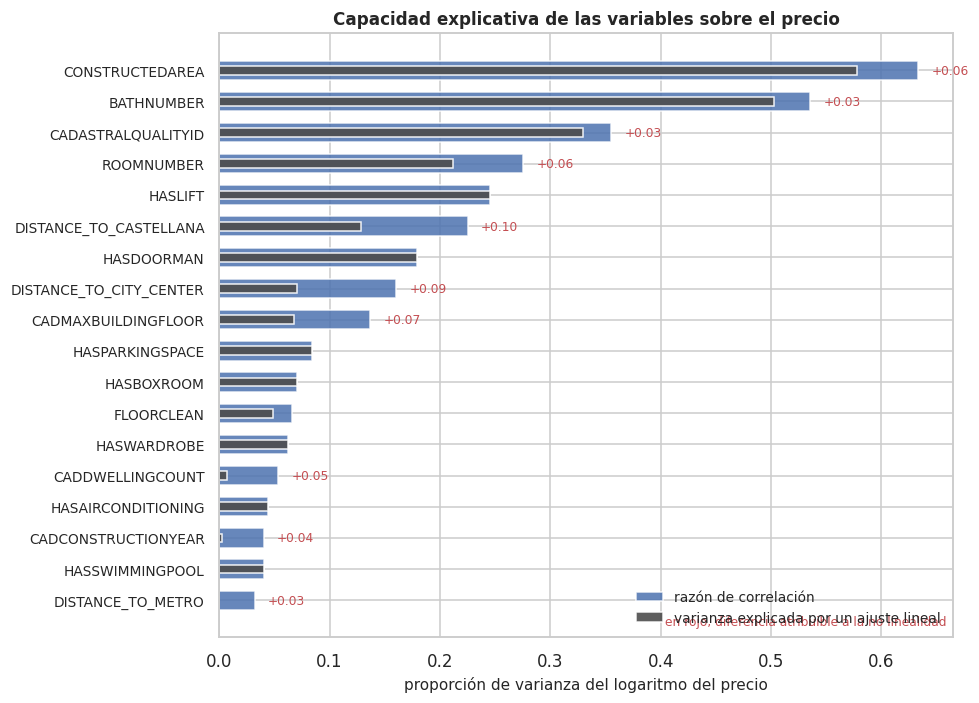

In [176]:
top = rank.head(18).iloc[::-1]
y = np.arange(len(top))

fig, ax = plt.subplots(figsize=(9, 6.5))

ax.barh(y, top.eta2, height=.62, color=COLOR_PRECIO, alpha=.85,
        label='razón de correlación')
ax.barh(y, top.r2_lineal, height=.28, color=COLOR_REF, alpha=.9,
        label='varianza explicada por un ajuste lineal')

ax.set_yticks(y)
ax.set_yticklabels(top.index, fontsize=9)
ax.set_xlabel('proporción de varianza del logaritmo del precio')
ax.set_title('Capacidad explicativa de las variables sobre el precio')
ax.legend(frameon=False, loc='lower right', fontsize=9)

# Se señalan las variables cuya relación no resulta captada por un ajuste lineal.
for i, (_, fila) in enumerate(top.iterrows()):
    if pd.notna(fila.brecha) and fila.brecha > .02:
        ax.text(fila.eta2 + .012, i, f'+{fila.brecha:.2f}',
                va='center', fontsize=8, color='#C44E52')

ax.text(.99, .02, 'en rojo, diferencia atribuible a la no linealidad',
        transform=ax.transAxes, ha='right', fontsize=8, color='#C44E52')

fig.tight_layout()
guardar_figura(fig, '03_capacidad_explicativa')
plt.show()

**Síntesis del apartado 3.4**

- La superficie construida encabeza la ordenación con una razón de correlación de
  0,63. El número de baños y de dormitorios la siguen, si bien su capacidad
  explicativa deriva de su asociación con el tamaño y no de un efecto propio.
- La calidad catastral, con 0,355, constituye la variable de mayor capacidad
  explicativa entre las ajenas al tamaño. Su escala se ordena de mejor a peor y
  la respuesta del precio la sigue de forma regular.
- Las variables de localización presentan una relación marcadamente no lineal. La
  distancia al Paseo de la Castellana supera en capacidad explicativa a la
  distancia al centro, lo que sugiere un gradiente de precio organizado en torno
  a dicho eje antes que de forma radial.
- El nivel de equipamiento se descarta por ausencia de capacidad discriminante.
  Las restantes variables de razón de correlación reducida se conservan, dado que
  la medida empleada no separa su efecto del de las variables con las que se
  asocian.

**Elementos que se trasladan a la memoria.** La ordenación de variables y la no
linealidad de las de localización, al apartado 5 como fundamento de las
transformaciones aplicadas. La preeminencia del eje de la Castellana, al apartado
4 como orientación del enriquecimiento geoespacial. La figura, al anexo.

### 3.5. Tramificación y agrupación de niveles

Se examinan en detalle dos variables de procedencia catastral, y por tanto
verificada, frente al carácter declarado de la mayoría de los atributos del
conjunto. De cada una resulta una decisión sobre la forma en que debe
incorporarse al modelo.

La calidad catastral constituye la variable de mayor capacidad explicativa entre
las ajenas al tamaño. Cinco de sus diez niveles, situados en ambos extremos de la
escala, presentan una representación inferior al cinco por ciento, insuficiente
para estimar su efecto de forma estable. Procede determinar si su agrupación está
justificada, lo que exige comprobar que los niveles a fusionar presentan un
comportamiento similar frente al precio: agrupar niveles de respuesta distinta
destruiría información.

El año de construcción presenta un comportamiento que justifica su examen
separado. Su coeficiente de correlación con el precio resulta prácticamente nulo
mientras que su razón de correlación no lo es, discrepancia que indica una
relación no monótona y que su incorporación en escala original desaprovecharía.
La hipótesis de partida atribuye este comportamiento a la coexistencia de dos
segmentos de valor elevado en extremos opuestos de la antigüedad: la edificación
histórica de las zonas centrales y la promoción reciente.

El procedimiento sigue el esquema de tramificación y comparación de la respuesta
por tramo empleado en la construcción de modelos de puntuación, adaptado a una
variable objetivo continua mediante la sustitución de la tasa de evento por la
mediana del precio unitario.

Las decisiones resultantes se documentan aquí y se aplican en el notebook de
modelización.

In [177]:
def tabla_por_tramo(serie, etiqueta_col):
    """Reparto del precio por nivel o tramo de la variable indicada."""
    t = madrid.groupby(serie, observed=True).agg(
        viviendas    =('PRICE', 'size'),
        precio_med   =('PRICE', 'median'),
        unitario_med =('UNITPRICE', 'median'),
        area_med     =('CONSTRUCTEDAREA', 'median'),
        dist_centro  =('DISTANCE_TO_CITY_CENTER', 'median'),
    )
    t['peso_%']   = 100 * t.viviendas / len(madrid)
    t['indice']   = 100 * t.unitario_med / madrid.UNITPRICE.median()
    t.index.name = etiqueta_col
    return t

print('CALIDAD CATASTRAL (la escala se ordena de mejor a peor)\n')
q = tabla_por_tramo(madrid.CADASTRALQUALITYID, 'calidad')
display(q[['viviendas', 'peso_%', 'unitario_med', 'indice',
           'precio_med', 'area_med', 'dist_centro']].round(2))

print(f'recorrido del índice: {q.indice.min():.0f} a {q.indice.max():.0f}')
print(f'monotonía de la respuesta: '
      f'{"sí" if q.unitario_med.is_monotonic_decreasing else "no"}')

# Agrupación propuesta de los niveles extremos, de representación insuficiente.
grupo_q = madrid.CADASTRALQUALITYID.clip(lower=2, upper=8)
print('\nTras agrupar los extremos (0-2 y 8-9):')
qa = tabla_por_tramo(grupo_q, 'calidad agrupada')
display(qa[['viviendas', 'peso_%', 'unitario_med', 'indice']].round(2))
print(f'niveles por debajo del 5%: {(qa["peso_%"] < 5).sum()}')

CALIDAD CATASTRAL (la escala se ordena de mejor a peor)



,viviendas,peso_%,unitario_med,indice,precio_med,area_med,dist_centro
calidad,,,,,,,
0.00,124,0.39,"6,398.02",179.49,"741,500.00",115.00,1.96
1.00,216,0.69,"6,048.63",169.69,"1,156,000.00",208.00,2.27
2.00,931,2.96,"5,062.50",142.02,"782,000.00",163.00,2.30
3.00,4289,13.65,"4,730.00",132.69,"525,000.00",118.00,2.98
4.00,8005,25.48,"4,220.34",118.40,"364,000.00",95.00,3.15
5.00,6686,21.28,"3,666.67",102.86,"274,000.00",85.00,3.75
6.00,7002,22.29,"2,380.00",66.77,"167,500.00",72.00,4.71
7.00,3451,10.98,"2,203.12",61.81,"143,000.00",65.00,5.41
8.00,516,1.64,"2,478.52",69.53,"181,000.00",74.00,5.34


recorrido del índice: 62 a 179
monotonía de la respuesta: no

Tras agrupar los extremos (0-2 y 8-9):


,viviendas,peso_%,unitario_med,indice
calidad agrupada,,,,
2.00,1271,4.05,"5,364.68",150.50
3.00,4289,13.65,"4,730.00",132.69
4.00,8005,25.48,"4,220.34",118.40
5.00,6686,21.28,"3,666.67",102.86
6.00,7002,22.29,"2,380.00",66.77
7.00,3451,10.98,"2,203.12",61.81
8.00,713,2.27,"2,642.86",74.14


niveles por debajo del 5%: 2


In [178]:
print('AÑO DE CONSTRUCCIÓN CATASTRAL\n')
tramos_anio = [1699, 1900, 1940, 1960, 1975, 1990, 2005, 2018]
etiquetas = ['antes de 1900', '1900-1939', '1940-1959', '1960-1974',
             '1975-1989', '1990-2004', '2005-2018']
corte = pd.cut(madrid.CADCONSTRUCTIONYEAR, bins=tramos_anio, labels=etiquetas)

a = tabla_por_tramo(corte, 'periodo')
display(a[['viviendas', 'peso_%', 'unitario_med', 'indice',
           'area_med', 'dist_centro']].round(2))

print(f'recorrido del índice: {a.indice.min():.0f} a {a.indice.max():.0f}')
print(f'correlación lineal con el logaritmo del precio: '
      f'{np.log(madrid.PRICE).corr(madrid.CADCONSTRUCTIONYEAR):+.3f}')
print(f'\ncorrelación entre precio unitario y distancia al centro, '
      f'sobre los {len(a)} tramos: {a.unitario_med.corr(a.dist_centro):+.3f}')

AÑO DE CONSTRUCCIÓN CATASTRAL



,viviendas,peso_%,unitario_med,indice,area_med,dist_centro
periodo,,,,,,
antes de 1900,1612,5.13,"4,857.14",136.26,72.00,0.85
1900-1939,3759,11.96,"4,870.00",136.62,68.00,2.29
1940-1959,6060,19.29,"3,429.07",96.20,78.00,3.52
1960-1974,9726,30.96,"2,803.60",78.65,79.00,4.73
1975-1989,3989,12.70,"3,448.47",96.74,98.00,5.05
1990-2004,3707,11.80,"3,504.13",98.30,95.00,5.63
2005-2018,2565,8.16,"3,368.42",94.50,90.00,7.45


recorrido del índice: 79 a 137
correlación lineal con el logaritmo del precio: -0.054

correlación entre precio unitario y distancia al centro, sobre los 7 tramos: -0.764


figura guardada: 04_calidad_antiguedad.png


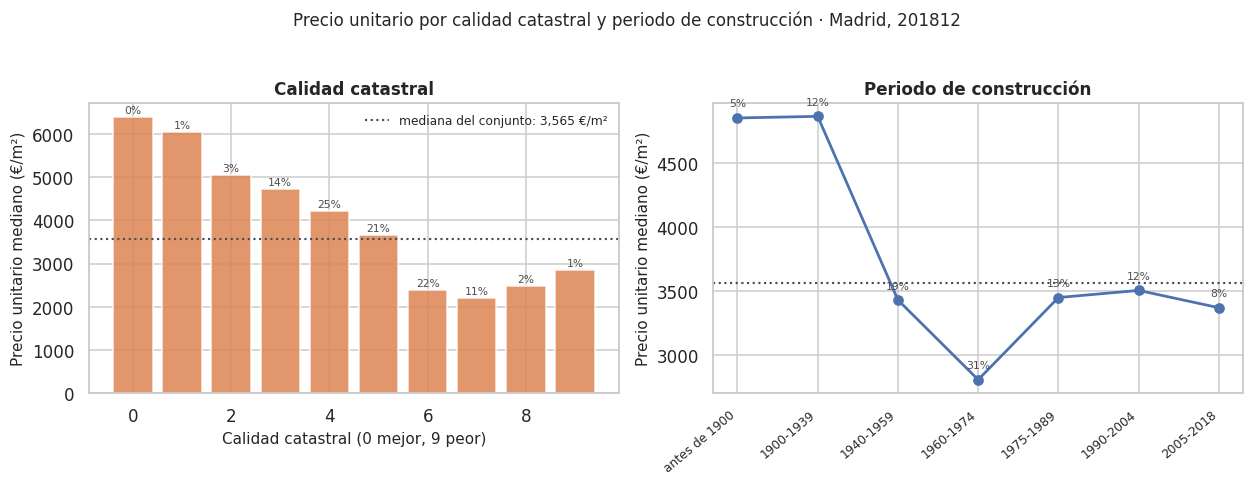

In [179]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

# --- Calidad catastral ---
ax = axes[0]
ax.bar(q.index.astype(int), q.unitario_med, color=COLOR_UNITARIO, alpha=.85)
ax.axhline(madrid.UNITPRICE.median(), color=COLOR_REF, ls=':', lw=1.4,
           label=f'mediana del conjunto: {madrid.UNITPRICE.median():,.0f} €/m²')
for x, (u, p) in zip(q.index.astype(int), zip(q.unitario_med, q['peso_%'])):
    ax.text(x, u + 90, f'{p:.0f}%', ha='center', fontsize=7, color=COLOR_REF)
ax.set_xlabel('Calidad catastral (0 mejor, 9 peor)')
ax.set_ylabel('Precio unitario mediano (€/m²)')
ax.set_title('Calidad catastral')
ax.legend(frameon=False, fontsize=8, loc='upper right')

# --- Año de construcción ---
ax = axes[1]
x = np.arange(len(a))
ax.plot(x, a.unitario_med, marker='o', ms=6, lw=1.8, color=COLOR_PRECIO)
ax.axhline(madrid.UNITPRICE.median(), color=COLOR_REF, ls=':', lw=1.4)
for xi, (u, p) in zip(x, zip(a.unitario_med, a['peso_%'])):
    ax.text(xi, u + 90, f'{p:.0f}%', ha='center', fontsize=7, color=COLOR_REF)
ax.set_xticks(x)
ax.set_xticklabels(a.index, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Precio unitario mediano (€/m²)')
ax.set_title('Periodo de construcción')

fig.suptitle('Precio unitario por calidad catastral y periodo de construcción · '
             f'Madrid, {TRIMESTRE}', fontsize=11, y=1.04)
fig.tight_layout()
guardar_figura(fig, '04_calidad_antiguedad')
plt.show()

In [180]:
# La escala no resulta monótona en su extremo inferior: los niveles 8 y 9
# presentan un precio unitario superior al del 7. Se evalúa la agrupación de los
# tres niveles finales frente a la de los dos últimos.
alternativas = {
    'sin agrupar':        madrid.CADASTRALQUALITYID,
    'extremos 0-2 y 8-9': madrid.CADASTRALQUALITYID.clip(lower=2, upper=8),
    'extremos 0-2 y 7-9': madrid.CADASTRALQUALITYID.clip(lower=2, upper=7),
}

log_precio = np.log(madrid.PRICE)
print(f'{"agrupación":22s} {"niveles":>8s} {"<5%":>5s} {"monótona":>9s} {"eta2":>7s}')
for etiqueta, serie in alternativas.items():
    t = madrid.groupby(serie, observed=True).UNITPRICE.median()
    peso = madrid.groupby(serie, observed=True).size() / len(madrid)
    print(f'{etiqueta:22s} {serie.nunique():>8d} {(peso < .05).sum():>5d} '
          f'{"sí" if t.is_monotonic_decreasing else "no":>9s} '
          f'{razon_correlacion(log_precio, serie):>7.3f}')

print('\nAgrupación 7-9: reparto resultante')
g = madrid.CADASTRALQUALITYID.clip(lower=2, upper=7)
res = madrid.groupby(g, observed=True).agg(
    viviendas=('PRICE', 'size'), unitario_med=('UNITPRICE', 'median'))
res['peso_%'] = 100 * res.viviendas / len(madrid)
res['indice'] = 100 * res.unitario_med / madrid.UNITPRICE.median()
display(res.round(2))

agrupación              niveles   <5%  monótona    eta2
sin agrupar                  10     5        no   0.355
extremos 0-2 y 8-9            7     2        no   0.353
extremos 0-2 y 7-9            6     1        sí   0.352

Agrupación 7-9: reparto resultante


,viviendas,unitario_med,peso_%,indice
CADASTRALQUALITYID,,,,
2.00,1271,"5,364.68",4.05,150.50
3.00,4289,"4,730.00",13.65,132.69
4.00,8005,"4,220.34",25.48,118.40
5.00,6686,"3,666.67",21.28,102.86
6.00,7002,"2,380.00",22.29,66.77
7.00,4164,"2,265.17",13.25,63.55


**Calidad catastral.** El precio unitario mediano desciende de forma regular
desde los 6.398 euros por metro cuadrado del nivel superior hasta los 2.203 del
nivel 7, lo que confirma que la escala se ordena de mejor a peor. Los dos niveles
finales rompen esa gradación, con valores de 2.479 y 2.857, superiores al del
nivel que los precede. Afecta a 713 viviendas y no admite explicación con la
información disponible.

La comparación entre agrupaciones resuelve la cuestión: fusionar los tres niveles
finales produce una escala de seis niveles, monótona en toda su extensión, con
una razón de correlación de 0,352 frente a los 0,355 de la original. El repunte
observado no incorporaba información aprovechable.

**Antigüedad.** La relación con el precio presenta la forma no monótona
anticipada: 4.857 euros por metro cuadrado en la edificación anterior a 1900,
mínimo de 2.804 en el periodo 1960-1974 y recuperación posterior. Esta última
resulta limitada, sin embargo: los tramos posteriores a 1975 se sitúan en torno
al índice 97, por debajo de la mediana del conjunto, mientras que los anteriores
a 1940 alcanzan el 136. La edificación reciente no constituye un segmento de
precio elevado; únicamente lo es la histórica.

La causa es la localización. La distancia mediana al centro crece de forma
monótona con el periodo de construcción, de 0,85 kilómetros en la edificación
anterior a 1900 a 7,45 en la posterior a 2005, con una correlación de −0,764
respecto al precio unitario sobre los siete tramos. El crecimiento del municipio
desde su núcleo histórico hacia la periferia hace que antigüedad y centralidad
resulten indistinguibles.

De ello se sigue una previsión contrastable: la capacidad explicativa de la
antigüedad debería reducirse de forma sustancial al incorporar las variables de
localización del bloque de enriquecimiento. La comprobación corresponde al
análisis de importancia del modelo.

**Decisiones adoptadas.** La calidad catastral se agrupa en seis niveles,
fusionando 0 a 2 y 7 a 9: la escala resultante es monótona y conserva la
capacidad explicativa de la original, si bien uno de los seis niveles permanece
por debajo del cinco por ciento de representación. Se descarta su tratamiento como categórica
sin orden, que permitiría recoger el repunte de los niveles extremos pero consume
grados de libertad sin mejora medible y dificulta la lectura de los coeficientes
del modelo interpretable. La antigüedad se incorpora tramificada por periodo, al
no ser monótona su relación con el precio. Ambas se aplican en el notebook de
modelización.

**Elementos que se trasladan a la memoria.** Las dos decisiones de tratamiento,
al apartado 5. La confusión entre antigüedad y localización, al apartado 7 como
ejemplo de lectura de la interpretabilidad. La figura, al anexo.

## 4. Análisis por distrito y barrio *(memoria: apartado 3.2)*

El apartado 3.2 estableció que el precio unitario describe una relación en U
respecto a la superficie, atribuible a la asociación entre tamaño y localización,
y el 3.5 documentó una confusión análoga con la antigüedad del edificio. Ambas
observaciones apuntan a la localización como determinante principal del precio,
extremo que este bloque contrasta de forma directa.

El análisis requiere asignar a cada vivienda su unidad espacial, operación que no
figura en el conjunto de partida: los polígonos de barrio se distribuyen como
capa independiente, sin referencia alguna a los anuncios. La asignación se
obtiene mediante cruce espacial.

Del bloque resultan tres elementos: la caracterización del mercado por zonas, la
determinación de la cobertura muestral por barrio —que condiciona tanto la
representación cartográfica como el análisis de equidad— y la cuantificación de
la capacidad explicativa de la localización, referencia frente a la que valorar
las variables construidas en el bloque de enriquecimiento.

### 4.1. Asignación de la unidad espacial

Se asigna a cada vivienda el barrio que la contiene mediante cruce espacial. La
operación exige que ambas capas compartan sistema de referencia, condición
verificada en el bloque 1 tras asignar de forma explícita el código EPSG ausente
en el fichero de polígonos.

El bloque 1 verificó asimismo que los polígonos constituyen una partición sin
solapamientos, de modo que cada vivienda recibe un único barrio. Restan por
determinar los anuncios que no caigan dentro de ningún polígono, correspondientes
a los errores de geocodificación detectados en el mismo bloque.

El distrito se obtiene del identificador del barrio, cuya estructura jerárquica lo
codifica, y proporciona un nivel de agregación intermedio de utilidad para los
barrios con menor número de observaciones.

In [181]:
# mapclassify sustenta los esquemas de clasificación de los mapas de coropletas.
try:
    import mapclassify
    print(f'mapclassify {mapclassify.__version__}')
except ImportError:
    print('mapclassify no disponible: ejecutar  !pip install -q mapclassify')

COLS_BARRIO = ['LOCATIONID', 'LOCATIONNAME', 'DISTRITO', 'BARRIO']

madrid = gpd.sjoin(
    madrid.drop(columns=[c for c in COLS_BARRIO + ['index_right']
                         if c in madrid.columns]),
    barrios[COLS_BARRIO + [barrios.geometry.name]],
    how='left', predicate='within',
).drop(columns='index_right')

# El cruce asigna dos barrios a un punto situado sobre la frontera entre
# polígonos contiguos, duplicando la fila. Se conserva una única asignación.
n0 = len(madrid)
madrid = madrid[~madrid.index.duplicated(keep='first')]
if n0 != len(madrid):
    print(f'asignaciones duplicadas resueltas: {n0 - len(madrid)}')

# Los puntos que no caen dentro de ningún polígono se asignan al más próximo.
# Su separación del borde es del mismo orden que la perturbación aplicada a las
# coordenadas, cuyo efecto sobre la asignación ya se asume para el resto del
# conjunto: excluirlos supondría aplicar un criterio distinto al 0,08% de las
# viviendas.
sin_barrio = madrid.LOCATIONID.isna()
print(f'\nviviendas fuera de todo polígono: {sin_barrio.sum():,} '
      f'({sin_barrio.mean():.3%})')

if sin_barrio.any():
    rescate = gpd.sjoin_nearest(
        madrid.loc[sin_barrio, [madrid.geometry.name]].to_crs(CRS_M),
        barrios[COLS_BARRIO + [barrios.geometry.name]].to_crs(CRS_M),
        how='left', distance_col='dist_m',
    )
    # La equidistancia entre dos polígonos duplicaría la fila.
    rescate = rescate[~rescate.index.duplicated(keep='first')]

    print(f'  distancia al polígono más próximo: mediana '
          f'{rescate.dist_m.median():.0f} m, máxima {rescate.dist_m.max():.0f} m')

    for c in COLS_BARRIO:
        madrid.loc[sin_barrio, c] = rescate[c]

    print(f'  asignadas por proximidad: {sin_barrio.sum():,}')
    print(f'  sin asignar tras el rescate: {madrid.LOCATIONID.isna().sum():,}')
print(f'barrios con al menos una vivienda: {madrid.LOCATIONID.nunique()} '
      f'de {len(barrios)}')
print(f'distritos representados: {madrid.DISTRITO.nunique()}')

vacios = set(barrios.LOCATIONID) - set(madrid.LOCATIONID.dropna())
print(f'\nbarrios sin ninguna vivienda: {len(vacios)}')
if vacios:
    print(barrios[barrios.LOCATIONID.isin(vacios)]
          [['LOCATIONID', 'LOCATIONNAME']].to_string(index=False))

mapclassify 2.10.0
asignaciones duplicadas resueltas: 5

viviendas fuera de todo polígono: 24 (0.076%)
  distancia al polígono más próximo: mediana 0 m, máxima 254 m
  asignadas por proximidad: 24
  sin asignar tras el rescate: 0
barrios con al menos una vivienda: 135 de 135
distritos representados: 21

barrios sin ninguna vivienda: 0


El cruce asigna barrio a la totalidad de las viviendas. Los 135 polígonos
contienen al menos una vivienda y los 21 distritos del municipio resultan
representados.

Dos circunstancias exigen tratamiento. La primera es la doble asignación de los
puntos situados exactamente sobre la frontera entre polígonos contiguos, que
duplica la fila; se conserva una única asignación, conforme al criterio de que
cada vivienda pertenece a un solo barrio.

La segunda son los puntos que no caen dentro de ningún polígono. Presentan
coordenadas dentro del rango del municipio, a diferencia de los errores de
geocodificación identificados en el bloque 1, cuya extensión alcanzaba
provincias limítrofes: se sitúan en el borde exterior de la zonificación, a una
distancia del polígono más próximo del mismo orden que el desplazamiento
aleatorio aplicado a las coordenadas.

Se asignan en consecuencia al polígono más próximo. El criterio alternativo
—excluirlos del análisis por zonas— resultaría inconsistente: la perturbación de
las coordenadas afecta por igual a la totalidad del conjunto y su efecto sobre
la asignación de barrio se asume para el 99,9% restante de las viviendas, por lo
que no procede rechazarlo únicamente donde resulta visible.

### 4.2. Precio por distrito y por barrio

Se caracteriza el mercado por zonas empleando el precio unitario y no el precio
absoluto. La elección responde a lo establecido en el apartado 3.2: el precio de
una vivienda combina el nivel de precio de su zona con su superficie, de modo que
una comparación por distrito basada en el precio absoluto confundiría ambos
efectos. Un distrito de vivienda amplia y precio unitario moderado presentaría un
precio mediano superior al de otro de vivienda reducida y precio unitario
elevado.

La tabla recoge asimismo la superficie mediana y la dispersión interna de cada
zona. La primera permite verificar en qué medida el tamaño típico varía entre
distritos; la segunda, medida como recorrido intercuartílico relativo, indica
hasta qué punto la zona constituye un mercado homogéneo.

In [182]:
geo = madrid[madrid.LOCATIONID.notna()].copy()
mediana_global = madrid.UNITPRICE.median()

def resumen_zona(df, clave):
    t = df.groupby(clave, observed=True).agg(
        viviendas    =('PRICE', 'size'),
        unitario_med =('UNITPRICE', 'median'),
        unitario_p25 =('UNITPRICE', lambda s: s.quantile(.25)),
        unitario_p75 =('UNITPRICE', lambda s: s.quantile(.75)),
        precio_med   =('PRICE', 'median'),
        area_med     =('CONSTRUCTEDAREA', 'median'),
        dist_centro  =('DISTANCE_TO_CITY_CENTER', 'median'),
    )
    t['indice']      = 100 * t.unitario_med / mediana_global
    t['dispersion']  = (t.unitario_p75 - t.unitario_p25) / t.unitario_med
    return t

# --- Distritos ---
dist = resumen_zona(geo, 'DISTRITO').sort_values('indice', ascending=False)
print(f'{len(dist)} distritos\n')
display(dist[['viviendas', 'unitario_med', 'indice', 'precio_med',
              'area_med', 'dist_centro', 'dispersion']].round(2))

print(f'recorrido del índice por distrito: {dist.indice.min():.0f} a '
      f'{dist.indice.max():.0f}')
print(f'el distrito más caro multiplica al más barato por '
      f'{dist.unitario_med.max() / dist.unitario_med.min():.2f}')

# --- Barrios ---
barr = resumen_zona(geo, 'LOCATIONID')
barr = barr.join(barrios.set_index('LOCATIONID').LOCATIONNAME)
barr = barr.sort_values('indice', ascending=False)

print(f'\n\n{len(barr)} barrios')
print(f'recorrido del índice por barrio: {barr.indice.min():.0f} a '
      f'{barr.indice.max():.0f}')
print(f'el barrio más caro multiplica al más barato por '
      f'{barr.unitario_med.max() / barr.unitario_med.min():.2f}')

print('\nDiez barrios de mayor precio unitario:')
display(barr.head(10)[['LOCATIONNAME', 'viviendas', 'unitario_med',
                       'indice', 'area_med']].round(2))
print('Diez barrios de menor precio unitario:')
display(barr.tail(10)[['LOCATIONNAME', 'viviendas', 'unitario_med',
                       'indice', 'area_med']].round(2))

# --- Cobertura muestral ---
print('\n\nCOBERTURA MUESTRAL POR BARRIO')
print(barr.viviendas.describe(percentiles=[.05, .1, .25, .5, .75]).round(0).to_string())
for u in [30, 50, 100]:
    n = (barr.viviendas < u).sum()
    print(f'  barrios con menos de {u:3d} viviendas: {n:3d}  '
          f'({100 * geo.groupby("LOCATIONID").size().loc[
              barr.index[barr.viviendas < u]].sum() / len(geo):.1f}% del conjunto)')

21 distritos



,viviendas,unitario_med,indice,precio_med,area_med,dist_centro,dispersion
DISTRITO,,,,,,,
04,2696,"5,565.22",156.12,"549,000.00",105.00,2.92,0.41
07,2195,"5,275.23",147.99,"569,000.00",110.00,2.26,0.31
01,3663,"4,905.80",137.63,"357,000.00",74.00,0.84,0.34
05,1869,"4,884.62",137.03,"496,000.00",105.00,4.61,0.30
03,1262,"4,555.49",127.80,"457,000.00",103.00,2.63,0.34
09,1119,"4,133.33",115.95,"447,000.00",105.00,5.11,0.38
02,1476,"4,022.47",112.84,"302,000.00",79.00,1.97,0.26
06,1985,"3,571.43",100.19,"254,000.00",73.00,4.62,0.38
16,1173,"3,567.16",100.07,"344,000.00",95.00,8.16,0.46


recorrido del índice por distrito: 46 a 156
el distrito más caro multiplica al más barato por 3.39


135 barrios
recorrido del índice por barrio: 35 a 213
el barrio más caro multiplica al más barato por 6.12

Diez barrios de mayor precio unitario:


,LOCATIONNAME,viviendas,unitario_med,indice,area_med
LOCATIONID,,,,,
0-EU-ES-28-07-001-079-04-001,Recoletos,359,"7,595.00",213.07,170.00
0-EU-ES-28-07-001-079-04-006,Castellana,360,"6,624.46",185.84,160.00
0-EU-ES-28-07-001-079-07-004,Almagro,472,"6,173.32",173.18,135.00
0-EU-ES-28-07-001-079-01-004,Chueca-Justicia,528,"5,964.11",167.31,90.00
0-EU-ES-28-07-001-079-04-002,Goya,638,"5,923.66",166.18,100.00
0-EU-ES-28-07-001-079-04-005,Lista,477,"5,645.16",158.37,105.00
0-EU-ES-28-07-001-079-05-001,El Viso,261,"5,608.11",157.33,160.00
0-EU-ES-28-07-001-079-03-005,Jerónimos,155,"5,594.59",156.95,152.00
0-EU-ES-28-07-001-079-05-005,Nueva España,369,"5,385.00",151.07,138.00


Diez barrios de menor precio unitario:


,LOCATIONNAME,viviendas,unitario_med,indice,area_med
LOCATIONID,,,,,
0-EU-ES-28-07-001-079-11-005,Puerta Bonita,338,"1,803.15",50.58,73.00
0-EU-ES-28-07-001-079-13-002,San Diego,452,"1,788.00",50.16,65.00
0-EU-ES-28-07-001-079-20-003,Amposta,102,"1,757.79",49.31,55.00
0-EU-ES-28-07-001-079-17-004,Los Rosales,175,"1,736.20",48.71,75.00
0-EU-ES-28-07-001-079-17-005,Los Ángeles,169,"1,723.08",48.34,91.00
0-EU-ES-28-07-001-079-12-002,12 de Octubre-Orcasur,71,"1,643.48",46.11,97.00
0-EU-ES-28-07-001-079-17-001,San Andrés,492,"1,573.40",44.14,76.00
0-EU-ES-28-07-001-079-12-001,Orcasitas,98,"1,569.21",44.02,105.00
0-EU-ES-28-07-001-079-13-001,Entrevías,220,"1,415.01",39.70,80.00




COBERTURA MUESTRAL POR BARRIO
count     135.00
mean      233.00
std       168.00
min         7.00
5%         32.00
10%        67.00
25%       105.00
50%       193.00
75%       330.00
max     1,117.00
  barrios con menos de  30 viviendas:   6  (0.3% del conjunto)
  barrios con menos de  50 viviendas:  10  (0.7% del conjunto)
  barrios con menos de 100 viviendas:  28  (5.3% del conjunto)


El precio unitario mediano por barrio recorre de 1.241 a 7.595 euros por metro
cuadrado: el barrio más caro multiplica por 6,12 al más barato. La agregación por
distrito reduce ese recorrido a un factor de 3,39, lo que indica una
heterogeneidad interna apreciable dentro de cada distrito y aconseja emplear el
barrio como unidad de análisis siempre que la cobertura muestral lo permita.

La magnitud resulta relevante para el planteamiento del trabajo: ninguna
característica de la vivienda produce un efecto comparable. Dos inmuebles de
idénticas prestaciones separados por unos kilómetros pueden diferir en un factor
de seis en su valor por metro cuadrado.

El distrito Centro ilustra la asociación entre tamaño y localización establecida
en el apartado 3.2. Presenta un índice de precio unitario de 137 con la superficie
mediana más reducida del municipio, 74 metros cuadrados, lo que sitúa su precio
absoluto mediano en 357.000 euros, por debajo del correspondiente a distritos de
precio unitario inferior. La confusión entre ambas magnitudes queda así
verificada de forma directa.

La dispersión interna de cada distrito, medida como recorrido intercuartílico
relativo, se sitúa entre 0,24 y 0,49. Buena parte de esa variación corresponde a
las diferencias entre los barrios que lo componen, ya cuantificadas en el factor
de 6,12; lo que la magnitud acredita es que el distrito no constituye un mercado
homogéneo, y con ello que la agregación a ese nivel pierde información
relevante.

### 4.3. Cobertura muestral por barrio

La mediana por barrio se estima sobre un número de observaciones muy desigual: de
7 a 1.118 viviendas, con mediana de 193. Los barrios con escasas observaciones
producen estimaciones inestables, circunstancia que afecta tanto a su
representación cartográfica como al análisis de equidad, donde una diferencia
atribuible al azar muestral podría interpretarse como un sesgo del modelo.

Se establece un umbral de treinta viviendas, criterio convencional para la
estimación de estadísticos por grupo. Afecta a seis barrios que reúnen el 0,28%
del conjunto. Un umbral de cincuenta afectaría a diez barrios y al 0,7%, y uno de
cien a veintinueve barrios y al 5,6%, proporción que ya excluiría una parte
apreciable del territorio.

Los barrios que no alcanzan el umbral se excluyen de la representación
cartográfica y del análisis de equidad, pero sus viviendas se conservan en el
conjunto: la limitación afecta a la estimación de agregados por zona, no a la
validez de los registros individuales.

In [183]:
UMBRAL_BARRIO = 30

barr['suficiente'] = barr.viviendas >= UMBRAL_BARRIO
insuf = barr[~barr.suficiente]

print(f'umbral: {UMBRAL_BARRIO} viviendas')
print(f'barrios por debajo: {len(insuf)} de {len(barr)}')
print(f'viviendas afectadas: {insuf.viviendas.sum():,} '
      f'({insuf.viviendas.sum() / len(geo):.2%})\n')
display(insuf[['LOCATIONNAME', 'viviendas', 'unitario_med', 'indice']].round(2))

umbral: 30 viviendas
barrios por debajo: 6 de 135
viviendas afectadas: 88 (0.28%)



,LOCATIONNAME,viviendas,unitario_med,indice
LOCATIONID,,,,
0-EU-ES-28-07-001-079-08-010,Arroyo del Fresno,24,"4,177.71",117.20
0-EU-ES-28-07-001-079-08-001,El Pardo,7,"4,035.29",113.20
0-EU-ES-28-07-001-079-09-006,El Plantío,16,"3,891.51",109.17
0-EU-ES-28-07-001-079-14-002,Horcajo,17,"3,028.85",84.97
0-EU-ES-28-07-001-079-10-006,Cuatro Vientos,7,"2,375.00",66.63
0-EU-ES-28-07-001-079-21-002,Aeropuerto,17,"1,915.25",53.73


### 4.4. Representación cartográfica

El mapa recoge el precio unitario mediano por barrio. La clasificación se realiza
por cuantiles, de modo que cada clase agrupa un número similar de barrios: el
procedimiento evita que unos pocos barrios de precio extremo comprendan la mayor
parte de la escala y dejen el resto del municipio en un único tono.

Los barrios que no alcanzan el umbral muestral se representan en gris. La
distinción resulta necesaria para no atribuir la misma solidez a una mediana
estimada sobre más de mil viviendas y a otra estimada sobre siete.

figura guardada: 05_mapa_precio_barrio.png


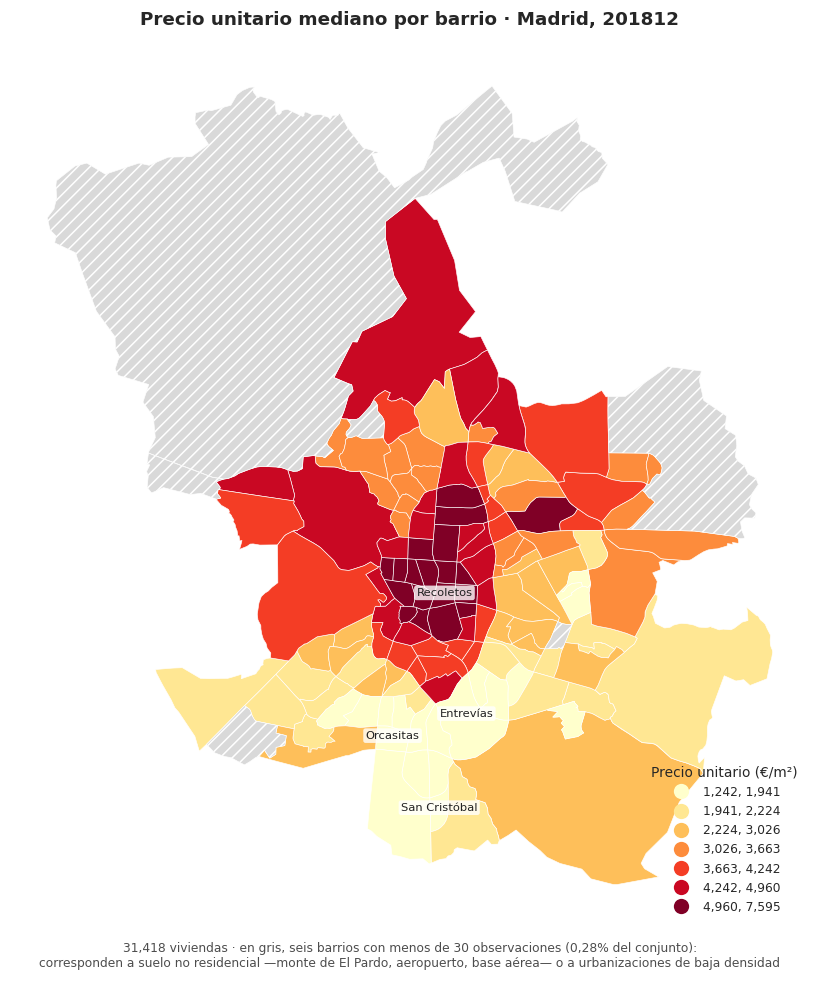

In [184]:
from matplotlib.ticker import FuncFormatter

mapa = barrios.merge(
    barr[['unitario_med', 'viviendas', 'indice', 'suficiente']],
    left_on='LOCATIONID', right_index=True, how='left')

fig, ax = plt.subplots(figsize=(9, 9))

mapa[mapa.suficiente].plot(
    column='unitario_med', scheme='quantiles', k=7, cmap='YlOrRd',
    edgecolor='white', linewidth=.4, legend=True, ax=ax,
    legend_kwds={'loc': 'lower right', 'fontsize': 8,
                 'title': 'Precio unitario (€/m²)', 'title_fontsize': 9,
                 'frameon': False, 'fmt': '{:,.0f}'})

mapa[~mapa.suficiente.fillna(False)].plot(
    color='#D9D9D9', edgecolor='white', linewidth=.4, hatch='///', ax=ax)

# Rotulado selectivo: en las zonas centrales la densidad de barrios impide
# rotular más de uno sin solapamiento.
ROTULAR = ['Recoletos', 'San Cristóbal', 'Entrevías', 'Orcasitas']
for nombre in ROTULAR:
    fila = mapa[mapa.LOCATIONNAME == nombre]
    if len(fila):
        c = fila.geometry.iloc[0].representative_point()
        ax.annotate(nombre, (c.x, c.y), fontsize=7.5, ha='center',
                    color='#222222',
                    bbox=dict(boxstyle='round,pad=.2', fc='white',
                              ec='none', alpha=.8))

ax.set_axis_off()
ax.set_title(f'Precio unitario mediano por barrio · Madrid, {TRIMESTRE}',
             fontsize=12, pad=14)
ax.text(.5, -.02,
        f'{len(geo):,} viviendas · en gris, seis barrios con menos de '
        f'{UMBRAL_BARRIO} observaciones (0,28% del conjunto):\n'
        'corresponden a suelo no residencial —monte de El Pardo, aeropuerto, '
        'base aérea— o a urbanizaciones de baja densidad',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=8, color=COLOR_REF)

fig.tight_layout()
guardar_figura(fig, '05_mapa_precio_barrio')
plt.show()

La representación revela que el gradiente de precio del municipio no se organiza
de forma radial sino en torno a un eje. La banda de mayor valor recorre la ciudad
de norte a sur siguiendo el trazado del Paseo de la Castellana y su prolongación,
desde Chamartín hasta el entorno del Retiro, y se extiende hacia el noroeste. El
resultado concuerda con lo observado en el apartado 3.4, donde la distancia a
dicho eje presentaba mayor capacidad explicativa que la distancia al centro de la
ciudad.

El sector meridional del municipio conforma una masa continua de precio reducido,
correspondiente a los distritos de Villaverde, Usera y Puente de Vallecas. La
transición entre ambas zonas no es gradual: barrios contiguos presentan
diferencias de precio unitario superiores al cincuenta por ciento.

Los seis barrios excluidos por cobertura insuficiente no corresponden a zonas
residenciales con escasa actividad, sino a suelo mayoritariamente no
residencial —el monte de El Pardo, el recinto aeroportuario y la base aérea de
Cuatro Vientos— o a urbanizaciones de baja densidad. La escasez de observaciones
refleja por tanto la estructura del territorio y no una limitación del muestreo,
lo que refuerza su exclusión de los agregados por zona.

### 4.5. Capacidad explicativa de la localización

Se cuantifica la proporción de variación del precio atribuible a la localización,
empleando la razón de correlación introducida en el apartado 3.4. La medida se
calcula sobre tres niveles de agregación —distrito, barrio y la combinación de
ambos— con el fin de determinar qué granularidad resulta necesaria.

El cálculo se realiza sobre dos variables objetivo. Sobre el logaritmo del precio
mide la capacidad explicativa que la localización aporta al modelo de valoración.
Sobre el logaritmo del precio unitario aísla el efecto de la zona del efecto del
tamaño de la vivienda, y proporciona la magnitud pertinente para caracterizar el
mercado.

La comparación con la superficie construida, que el apartado 3.2 situó como
principal determinante individual del precio, permite valorar el peso relativo de
ambos factores.

Procede una advertencia sobre la interpretación. La razón de correlación crece
con el número de grupos empleados, de modo que una partición en 135 barrios
presenta ventaja estructural frente a una en 21 distritos o en 10 deciles de
superficie. La comparación entre niveles de agregación no resulta por tanto
directa. Se cuantifica el efecto sobre la partición más numerosa, el barrio, por
ser la que más lo acusa: si allí resulta inapreciable, no altera la
comparación.

In [185]:
log_precio   = np.log(geo.PRICE)
log_unitario = np.log(geo.UNITPRICE)

PARTICIONES = {
    'distrito':             geo.DISTRITO,
    'barrio':               geo.LOCATIONID,
    'superficie (deciles)': pd.qcut(geo.CONSTRUCTEDAREA, 10, duplicates='drop'),
    'calidad catastral':    geo.CADASTRALQUALITYID,
}

comp = pd.DataFrame([
    {'partición': e, 'grupos': g.nunique(),
     'eta2_precio':   razon_correlacion(log_precio, g),
     'eta2_unitario': razon_correlacion(log_unitario, g)}
    for e, g in PARTICIONES.items()
]).set_index('partición')
display(comp.round(3))

# La razón de correlación crece con el número de grupos. Se verifica que la
# corrección por grados de libertad resulta inapreciable a este tamaño muestral,
# lo que permite comparar particiones de granularidad distinta.
n, k = len(geo), geo.LOCATIONID.nunique()
e = comp.loc['barrio', 'eta2_unitario']
print(f'corrección por número de grupos (barrio, {k} grupos sobre {n:,} '
      f'viviendas): {e:.4f} -> {1 - (1 - e) * (n - 1) / (n - k):.4f}')

print(f'\nSobre el logaritmo del precio unitario:')
print(f'  barrio:     {comp.loc["barrio", "eta2_unitario"]:.1%}')
print(f'  distrito:   {comp.loc["distrito", "eta2_unitario"]:.1%}')
print(f'  superficie: {comp.loc["superficie (deciles)", "eta2_unitario"]:.1%}')

# Valoración por aplicación del precio unitario de la zona a la superficie:
# procedimiento habitual en ausencia de modelo.
med_barrio = geo.groupby('LOCATIONID').UNITPRICE.transform('median')
err_zona = ((med_barrio * geo.CONSTRUCTEDAREA - geo.PRICE).abs()
            / geo.PRICE).median()
print(f'\nError relativo mediano de la valoración por zona y superficie: '
      f'{err_zona:.1%}   (superficie sola, apartado 3.2: 33,7%)')
print('  Magnitud orientativa: la mediana de zona se calcula sobre el propio')
print('  conjunto evaluado. Su cuantificación sobre datos de validación')
print('  corresponde al notebook de modelización.')

,grupos,eta2_precio,eta2_unitario
partición,,,
distrito,21,0.44,0.65
barrio,135,0.58,0.73
superficie (deciles),10,0.63,0.15
calidad catastral,10,0.35,0.29


corrección por número de grupos (barrio, 135 grupos sobre 31,418 viviendas): 0.7266 -> 0.7255

Sobre el logaritmo del precio unitario:
  barrio:     72.7%
  distrito:   65.1%
  superficie: 14.6%

Error relativo mediano de la valoración por zona y superficie: 14.6%   (superficie sola, apartado 3.2: 33,7%)
  Magnitud orientativa: la mediana de zona se calcula sobre el propio
  conjunto evaluado. Su cuantificación sobre datos de validación
  corresponde al notebook de modelización.


La localización constituye el determinante principal del precio unitario: el
barrio explica el 72,7% de su variación, frente al 14,6% atribuible a la
superficie construida. La relación se invierte al considerar el precio absoluto,
donde la superficie alcanza el 63,4% y el barrio el 57,9%, resultado esperable
dado que el precio incorpora el tamaño de la vivienda como factor multiplicativo.

El barrio supera al distrito en 7,6 puntos, 72,7% frente a 65,1%, lo que
justifica emplear la unidad de mayor granularidad pese a su menor cobertura
muestral. La corrección por el número de grupos resulta inapreciable a este
tamaño muestral, de modo que la ventaja no es atribuible a la mayor cardinalidad
de la partición.

**La valoración por aplicación del precio unitario de la zona a la superficie del
inmueble presenta un error relativo mediano del 14,6%**, frente al 33,7% de la
estimación basada únicamente en la superficie. El procedimiento, habitual en
ausencia de modelo, reduce por tanto el error a menos de la mitad con dos únicas
magnitudes.

La cifra delimita la exigencia aplicable al modelo. Un sistema de valoración
automatizada que no mejore de forma apreciable ese 14,6% no justificaría su
complejidad frente a una regla de cálculo elemental. La comparación definitiva
corresponde al apartado de estrategia de validación, donde ambas magnitudes se
estiman sobre datos no empleados en su construcción.

### Síntesis del bloque

**Asignación espacial.** El cruce con los polígonos de barrio asigna unidad
espacial a la totalidad de las viviendas. Los 135 barrios y los 21 distritos del
municipio resultan representados. Un número reducido de puntos situados en el
borde exterior de la zonificación, atribuibles al desplazamiento aleatorio de
las coordenadas, se asigna al polígono más próximo.

**Estructura del mercado.** El precio unitario mediano por barrio recorre de
1.241 a 7.595 euros por metro cuadrado, un factor de 6,12 entre los extremos. La
agregación por distrito reduce ese recorrido a un factor de 3,39, de lo que se
sigue una heterogeneidad interna apreciable dentro de cada distrito.

**Geometría del gradiente.** El precio no decrece de forma radial desde el centro
sino en torno al eje del Paseo de la Castellana y su prolongación hacia el norte,
conforme anticipaba la mayor capacidad explicativa de la distancia a dicho eje
frente a la distancia al centro. El sector meridional conforma una masa continua
de precio reducido, con transiciones abruptas entre barrios contiguos.

**Peso de la localización.** El barrio explica el 72,7% de la variación del
precio unitario, frente al 14,6% atribuible a la superficie. La valoración
obtenida al aplicar el precio unitario mediano de la zona a la superficie del
inmueble presenta un error relativo mediano del 14,6%, frente al 33,7% de la
estimación basada únicamente en la superficie.

**Cobertura muestral.** Se establece un umbral de treinta viviendas por barrio
para la estimación de agregados. Afecta a seis barrios que reúnen el 0,28% del
conjunto y que corresponden a suelo mayoritariamente no residencial o a
urbanizaciones de baja densidad. Sus viviendas se conservan en el conjunto.

**Elementos que se trasladan a la memoria (apartado 3.2).** El recorrido del
precio unitario entre barrios y su comparación con el nivel de distrito, el mapa
de coropletas, la geometría del gradiente y la capacidad explicativa de la
localización. Las tablas por distrito y por barrio, al anexo.

**Elementos que se trasladan al apartado 6.1.** El error de la valoración por
zona y superficie como referencia frente a la que valorar el modelo, pendiente de
cuantificación sobre datos de validación.

## 5. Calidad del dato y valores atípicos *(memoria: apartado 3.3)*

El bloque 3 identificó 65 registros con valores imposibles y documentó las
incidencias de codificación del conjunto. Este bloque aplica el tratamiento
correspondiente.

La distinción entre valor imposible y valor extremo legítimo determina el
tratamiento. Un recuento de baños igual a cero no puede corresponder a una
vivienda real: se trata de un valor ausente codificado numéricamente y procede
convertirlo en tal. Una vivienda de 934 metros cuadrados, en cambio, es
verosímil, y su exclusión reduciría el ámbito de aplicación del modelo
precisamente en el segmento donde se concentran las garantías de mayor importe.

El bloque no imputa los valores ausentes resultantes. La imputación forma parte
de la preparación de variables y su procedimiento debe estimarse sobre el
conjunto de entrenamiento para no incorporar información del conjunto de
validación, por lo que corresponde al notebook de modelización.

Se registra la traza de cada modificación aplicada al conjunto.

In [186]:
# Registro de las modificaciones aplicadas al conjunto.
traza = []

IMPOSIBLES = {
    'ROOMNUMBER':          (madrid.ROOMNUMBER > 15,
                            'más de 15 dormitorios'),
    'BATHNUMBER':          ((madrid.BATHNUMBER <= 0) | (madrid.BATHNUMBER > 10),
                            'recuento nulo o superior a 10'),
    'CADCONSTRUCTIONYEAR': (madrid.CADCONSTRUCTIONYEAR < 1800,
                            'año anterior a 1800'),
    'CADMAXBUILDINGFLOOR': (madrid.CADMAXBUILDINGFLOOR <= 0,
                            'altura de edificio nula'),
}

print('RECODIFICACIÓN DE VALORES IMPOSIBLES\n')
for col, (cond, motivo) in IMPOSIBLES.items():
    n = cond.sum()
    if n:
        madrid.loc[cond, col] = np.nan
        traza.append({'operación': 'recodificación', 'variable': col,
                      'registros': int(n), 'motivo': motivo})
    print(f'  {col:22s} {n:>4,} -> ausente   ({motivo})')

total = sum(t['registros'] for t in traza)
print(f'\nvalores recodificados: {total}')
print(f'filas afectadas: se conservan las {len(madrid):,} viviendas; '
      f'la recodificación opera sobre valores, no sobre registros')

# Verificación: ninguna condición debe seguir cumpliéndose.
print('\nverificación:')
for col, (_, motivo) in IMPOSIBLES.items():
    resto = {
        'ROOMNUMBER':          (madrid.ROOMNUMBER > 15).sum(),
        'BATHNUMBER':          ((madrid.BATHNUMBER <= 0)
                                | (madrid.BATHNUMBER > 10)).sum(),
        'CADCONSTRUCTIONYEAR': (madrid.CADCONSTRUCTIONYEAR < 1800).sum(),
        'CADMAXBUILDINGFLOOR': (madrid.CADMAXBUILDINGFLOOR <= 0).sum(),
    }[col]
    print(f'  {col:22s} {resto} registros restantes')

RECODIFICACIÓN DE VALORES IMPOSIBLES

  ROOMNUMBER                3 -> ausente   (más de 15 dormitorios)
  BATHNUMBER               32 -> ausente   (recuento nulo o superior a 10)
  CADCONSTRUCTIONYEAR       3 -> ausente   (año anterior a 1800)
  CADMAXBUILDINGFLOOR      27 -> ausente   (altura de edificio nula)

valores recodificados: 65
filas afectadas: se conservan las 31,418 viviendas; la recodificación opera sobre valores, no sobre registros

verificación:
  ROOMNUMBER             0 registros restantes
  BATHNUMBER             0 registros restantes
  CADCONSTRUCTIONYEAR    0 registros restantes
  CADMAXBUILDINGFLOOR    0 registros restantes


### 5.2. Valores ausentes tras la recodificación

Se recalcula el recuento de valores ausentes. La cifra difiere de la obtenida en
el apartado 3.3 por incorporar los valores imposibles ya convertidos, que no
figuraban como ausentes al estar codificados numéricamente.

Se distingue entre la ausencia atribuible a la fuente y la resultante de la
recodificación, dado que su tratamiento posterior puede diferir: la primera
responde a información no facilitada y la segunda a un error de registro.

El tratamiento de estos valores corresponde al notebook de modelización. Como
criterio orientativo, las variables con una proporción de ausentes reducida
admiten imputación, las de proporción intermedia aconsejan la incorporación de la
ausencia como categoría propia, y las que superan la mitad del conjunto
difícilmente resultan aprovechables.

In [187]:
recodificados = {t['variable']: t['registros'] for t in traza}

n = madrid.isna().sum()
nulos = pd.DataFrame({
    'ausentes':      n,
    'ausentes_%':    (100 * n / len(madrid)).round(2),
    'recodificados': pd.Series(recodificados),
}).fillna({'recodificados': 0})
nulos['de_origen'] = nulos.ausentes - nulos.recodificados
nulos = nulos[nulos.ausentes > 0].sort_values('ausentes', ascending=False)

display(nulos.astype({'recodificados': int, 'de_origen': int}))

print(f'filas completas: {madrid.notna().all(axis=1).sum():,} de {len(madrid):,}')
print(f'  sin contar CONSTRUCTIONYEAR: '
      f'{madrid.drop(columns="CONSTRUCTIONYEAR").notna().all(axis=1).sum():,}')

print('\nreparto por tramo de ausencia:')
for etiqueta, lo, hi in [('hasta el 5% (admite imputación)', 0, 5),
                         ('entre el 5% y el 50% (categoría propia)', 5, 50),
                         ('por encima del 50% (no aprovechable)', 50, 101)]:
    v = nulos[(nulos['ausentes_%'] > lo) & (nulos['ausentes_%'] <= hi)]
    print(f'  {etiqueta:42s} {len(v)}  {", ".join(v.index) if len(v) else "—"}')

,ausentes,ausentes_%,recodificados,de_origen
CONSTRUCTIONYEAR,17690,56.31,0,17690
FLATLOCATIONID,2006,6.38,0,2006
FLOORCLEAN,1329,4.23,0,1329
BATHNUMBER,32,0.10,32,0
CADMAXBUILDINGFLOOR,27,0.09,27,0
CADCONSTRUCTIONYEAR,3,0.01,3,0
ROOMNUMBER,3,0.01,3,0
CADASTRALQUALITYID,1,0.00,0,1


filas completas: 12,694 de 31,418
  sin contar CONSTRUCTIONYEAR: 28,479

reparto por tramo de ausencia:
  hasta el 5% (admite imputación)            5  FLOORCLEAN, BATHNUMBER, CADMAXBUILDINGFLOOR, CADCONSTRUCTIONYEAR, ROOMNUMBER
  entre el 5% y el 50% (categoría propia)    1  FLATLOCATIONID
  por encima del 50% (no aprovechable)       1  CONSTRUCTIONYEAR


### 5.3. Coherencia de los registros extremos

No procede depurar valores atípicos de la variable objetivo: un precio elevado no
constituye un error sino una vivienda de valor elevado, y su exclusión reduciría
el ámbito de aplicación del modelo precisamente en el segmento donde se
concentran las garantías hipotecarias de mayor importe.

La comprobación que sí procede es distinta. Se verifica que los registros
situados en los extremos presentan un precio compatible con el resto de sus
características: un importe reducido en una vivienda amplia de zona céntrica no
correspondería a una vivienda barata sino a un error de registro, a una tipología
distinta de la residencial o a un precio de arrendamiento incorporado al conjunto
de operaciones de venta.

El contraste se realiza sobre el precio unitario y no sobre el precio absoluto,
al ser el primero comparable entre viviendas de distinta superficie. Para cada
registro extremo se compara su precio unitario con la mediana de su barrio: una
desviación acorde con la dispersión interna de la zona indica coherencia, mientras
que un valor muy alejado sugiere error.

Cabe anticipar un número reducido de incidencias, dado que el conjunto incorpora
en origen una acotación del precio unitario entre 805 y 9.993 euros por metro
cuadrado, según se documentó en el apartado 3.1.

In [188]:
# Se compara el precio unitario de cada vivienda con la mediana de su barrio,
# expresando la desviación en múltiplos del recorrido intercuartílico de la zona.
g = madrid.groupby('LOCATIONID').UNITPRICE
med_b = g.transform('median')
riq_b = g.transform(lambda s: s.quantile(.75) - s.quantile(.25))
desv = (madrid.UNITPRICE - med_b) / riq_b.replace(0, np.nan)

print('DESVIACIÓN DEL PRECIO UNITARIO RESPECTO A LA MEDIANA DEL BARRIO')
print('  (en múltiplos del recorrido intercuartílico de la zona)\n')
print(desv.describe(percentiles=[.001, .01, .99, .999]).round(2).to_string())

UMBRAL_DESV = 5
sospechosos = madrid[desv.abs() > UMBRAL_DESV]
print(f'\nregistros con desviación superior a {UMBRAL_DESV} recorridos: '
      f'{len(sospechosos):,} ({len(sospechosos) / len(madrid):.3%})')

if len(sospechosos):
    cols = ['PRICE', 'UNITPRICE', 'CONSTRUCTEDAREA', 'ROOMNUMBER',
            'BATHNUMBER', 'CADASTRALQUALITYID', 'LOCATIONNAME']
    display(sospechosos.assign(desviacion=desv[desv.abs() > UMBRAL_DESV])
            .sort_values('desviacion')[cols + ['desviacion']].round(2))

# Combinaciones materialmente incompatibles, con independencia del barrio.
print('\nCOMBINACIONES INCOMPATIBLES')
checks = {
    'precio inferior a 30.000 € con más de 60 m²':
        (madrid.PRICE < 30_000) & (madrid.CONSTRUCTEDAREA > 60),
    'precio unitario inferior a 1.000 €/m² en calidad catastral alta (0-3)':
        (madrid.UNITPRICE < 1_000) & (madrid.CADASTRALQUALITYID <= 3),
    'precio unitario superior a 8.000 €/m² en calidad catastral baja (7-9)':
        (madrid.UNITPRICE > 8_000) & (madrid.CADASTRALQUALITYID >= 7),
    'precio compatible con arrendamiento (inferior a 5.000 €)':
        madrid.PRICE < 5_000,
}
for etiqueta, cond in checks.items():
    n = cond.sum()
    marca = '  <-- ' if n else '      '
    print(f'{marca}{etiqueta:64s} {n:>4,}')

DESVIACIÓN DEL PRECIO UNITARIO RESPECTO A LA MEDIANA DEL BARRIO
  (en múltiplos del recorrido intercuartílico de la zona)

count   31,418.00
mean         0.09
std          0.84
min         -3.37
0.1%        -2.61
1%          -1.77
50%          0.00
99%          2.52
99.9%        4.29
max          9.99

registros con desviación superior a 5 recorridos: 23 (0.073%)


,PRICE,UNITPRICE,CONSTRUCTEDAREA,ROOMNUMBER,BATHNUMBER,CADASTRALQUALITYID,LOCATIONNAME,desviacion
19997,"1,270,000.00","8,581.08",148,3.00,2.00,8.00,Peñagrande,5.04
21563,"652,000.00","6,936.17",94,3.00,2.00,6.00,San Isidro,5.05
2671,"287,000.00","6,377.78",45,2.00,1.00,6.00,Pueblo Nuevo,5.22
1970,"160,000.00","4,848.48",33,1.00,1.00,6.00,Pradolongo,5.35
14740,"442,000.00","9,208.33",48,1.00,1.00,3.00,Las Tablas,5.44
20879,"3,294,000.00","9,150.00",360,7.00,5.00,2.00,Casa de Campo,5.45
30148,"283,000.00","3,824.32",74,4.00,2.00,6.00,Hellín,5.46
26781,"764,000.00","6,586.21",116,3.00,2.00,6.00,Pueblo Nuevo,5.50
30240,"584,000.00","4,492.31",130,3.00,2.00,4.00,Arcos,5.56
18697,"241,000.00","5,477.27",44,2.00,1.00,6.00,Casco Histórico de Vallecas,5.62



COMBINACIONES INCOMPATIBLES
      precio inferior a 30.000 € con más de 60 m²                         0
  <-- precio unitario inferior a 1.000 €/m² en calidad catastral alta (0-3)    8
  <-- precio unitario superior a 8.000 €/m² en calidad catastral baja (7-9)    5
      precio compatible con arrendamiento (inferior a 5.000 €)            0


### 5.4. Variables descartadas

Se relacionan las variables que no se incorporan al conjunto de trabajo, con el
motivo de su exclusión. El descarte efectivo se aplica en el bloque de cierre,
al guardar el conjunto preparado: su conservación durante el análisis permite las
verificaciones pendientes, entre ellas el contraste de la reproyección mediante
las coordenadas originales.

| Variable | Motivo |
|---|---|
| `UNITPRICE` | Cociente exacto entre precio y superficie. Su incorporación como predictor constituiría fuga de información (apartado 3.1). Se conserva con finalidad descriptiva |
| `PARKINGSPACEPRICE` | Registra el importe de una plaza ofertada de forma independiente, no un atributo de la vivienda. El 97,6% de los registros presenta un código de ausencia (apartado 3.3) |
| `ISPARKINGSPACEINCLUDEDINPRICE` | Coincide exactamente con `HASPARKINGSPACE` en la totalidad de los registros (apartado 3.3) |
| `CONSTRUCTIONYEAR` | Declarada por el anunciante, con el 56,31% de valores ausentes. Se emplea la variable catastral equivalente, completa (apartado 3.3) |
| `AMENITYID` | El 94,33% de las observaciones se concentra en un único nivel y su razón de correlación con el precio resulta nula (apartado 3.4) |
| `LONGITUDE`, `LATITUDE` | Redundantes con la geometría, con desviación máxima nula. Su conservación tras la reproyección introduciría dos sistemas de referencia en la misma tabla (apartado 1.7) |
| `BARRIO` | Código del barrio relativo a su distrito, de 001 a 010. No identifica el barrio de forma única: la agrupación por esta columna colapsaría las 135 zonas en 10. Su función la cumple `LOCATIONID` |
| `ASSETID` | Identificador. Agotó su función en la deduplicación y fue eliminada en el apartado 3.3 |

El conjunto de trabajo resultante comprende 32 variables explicativas y la
variable objetivo, además de la geometría y de los identificadores de barrio y
distrito incorporados en el bloque 4.

In [189]:
DESCARTES = {
    'UNITPRICE':                     'cociente de la objetivo (3.1)',
    'PARKINGSPACEPRICE':             'no describe la vivienda (3.3)',
    'ISPARKINGSPACEINCLUDEDINPRICE': 'duplicada de HASPARKINGSPACE (3.3)',
    'CONSTRUCTIONYEAR':              '56,31% de ausentes (3.3)',
    'AMENITYID':                     'sin capacidad discriminante (3.4)',
    'LONGITUDE':                     'redundante con la geometría (1.7)',
    'LATITUDE':                      'redundante con la geometría (1.7)',
    'BARRIO':                        'código relativo al distrito, no unívoco',
}

print('VARIABLES DESCARTADAS (el descarte se aplica en el bloque 8)\n')
for c, motivo in DESCARTES.items():
    estado = 'presente' if c in madrid.columns else 'ya eliminada'
    print(f'  {c:32s} {estado:14s} {motivo}')

METADATOS = ['LOCATIONID', 'LOCATIONNAME', 'DISTRITO', 'BARRIO']
predictoras = [c for c in madrid.columns
               if c not in list(DESCARTES) + METADATOS
               + ['PRICE', madrid.geometry.name]]

print(f'\nvariable objetivo:      PRICE')
print(f'variables explicativas: {len(predictoras)}')
print(f'metadatos de zona:      {len(METADATOS)}')
print(f'geometría:              1')
print(f'\ntotal de columnas tras el descarte: '
      f'{1 + len(predictoras) + len(METADATOS) + 1}')

VARIABLES DESCARTADAS (el descarte se aplica en el bloque 8)

  UNITPRICE                        presente       cociente de la objetivo (3.1)
  PARKINGSPACEPRICE                presente       no describe la vivienda (3.3)
  ISPARKINGSPACEINCLUDEDINPRICE    presente       duplicada de HASPARKINGSPACE (3.3)
  CONSTRUCTIONYEAR                 presente       56,31% de ausentes (3.3)
  AMENITYID                        presente       sin capacidad discriminante (3.4)
  LONGITUDE                        presente       redundante con la geometría (1.7)
  LATITUDE                         presente       redundante con la geometría (1.7)
  BARRIO                           presente       código relativo al distrito, no unívoco

variable objetivo:      PRICE
variables explicativas: 31
metadatos de zona:      4
geometría:              1

total de columnas tras el descarte: 37


### Síntesis del bloque

**Recodificación.** Se convierten en ausentes 65 valores imposibles distribuidos
en cuatro variables: recuento de dormitorios superior a quince, recuento de baños
nulo o superior a diez, año de construcción catastral anterior a 1800 y altura de
edificio nula. La operación afecta a valores y no a registros: el conjunto
conserva las 31.418 viviendas.

**Valores ausentes.** El recuento definitivo incorpora los valores recodificados,
que no figuraban como tales al estar codificados numéricamente. Su tratamiento
corresponde al notebook de modelización, dado que el procedimiento de imputación
debe estimarse sobre el conjunto de entrenamiento.

**Coherencia de los extremos.** No se identifica ningún registro atribuible a
error. Los 23 casos de mayor desviación respecto a la mediana de su barrio
corresponden a viviendas cuya tipología difiere de la predominante en la zona. No
se elimina ningún registro.

**Variables descartadas.** Siete variables no se incorporan al conjunto de
trabajo: el precio unitario y el precio de plaza de aparcamiento por su relación
con la variable objetivo o su falta de relación con la vivienda, el indicador
duplicado de aparcamiento, el año de construcción declarado, el nivel de
equipamiento y las dos columnas de coordenadas. El descarte efectivo se aplica en
el bloque de cierre.

**Elementos que se trasladan a la memoria (apartado 3.3).** El recuento de
valores recodificados y el resultado de la verificación de coherencia, en forma
sintética: el apartado dispone de unas cien palabras tras el texto ya redactado
sobre identidad de los registros. El descarte de variables se traslada al
apartado 5. El detalle, al anexo.

## 6. Reproyección a un sistema métrico *(memoria: apartado 4)*

Las coordenadas del conjunto se expresan en el sistema EPSG:4326, que emplea
grados de latitud y longitud. Sobre dicho sistema, la distancia euclídea entre
dos puntos carece de significado físico: un grado de latitud equivale
aproximadamente a 111 kilómetros, mientras que un grado de longitud equivale a esa
misma magnitud multiplicada por el coseno de la latitud, en torno a 85 kilómetros
en el paralelo de Madrid. El cálculo directo de distancias sobre coordenadas
geográficas produciría por tanto valores sin interpretación métrica y con
distorsión distinta según la dirección.

La reproyección al sistema EPSG:25830, correspondiente a la proyección ETRS89 UTM
huso 30 Norte, expresa las coordenadas en metros y permite el cálculo directo de
distancias y áreas. La elección del huso responde a la localización del
municipio: Madrid se sitúa íntegramente en el huso 30 Norte y próximo a su
meridiano central, de modo que la proyección no introduce distorsión apreciable
en el ámbito de trabajo.

La reproyección se verifica reconstruyendo una de las variables de distancia ya
presentes en el conjunto. Si el valor calculado reproduce el publicado, queda
acreditado que la transformación es correcta y que las distancias construidas en
el bloque siguiente resultan comparables con las de origen.

In [190]:
print(f'CRS de partida: {madrid.crs.to_string()}')

madrid_m  = madrid.to_crs(CRS_M)
barrios_m = barrios.to_crs(CRS_M)

print(f'CRS de destino: {madrid_m.crs.to_string()}  '
      f'(unidad: {madrid_m.crs.axis_info[0].unit_name})')

minx, miny, maxx, maxy = madrid_m.total_bounds
print(f'\nextensión en metros:')
print(f'  X: [{minx:,.0f}, {maxx:,.0f}]   anchura: {(maxx - minx) / 1000:,.1f} km')
print(f'  Y: [{miny:,.0f}, {maxy:,.0f}]   altura:  {(maxy - miny) / 1000:,.1f} km')
print(f'referencia: el término municipal de Madrid mide unos 30 km de norte a sur')

print(f'\nárea del municipio según los polígonos reproyectados: '
      f'{barrios_m.union_all().area / 1e6:,.1f} km²   (referencia: 604 km²)')

CRS de partida: EPSG:4326
CRS de destino: EPSG:25830  (unidad: metre)

extensión en metros:
  X: [429,436, 454,137]   anchura: 24.7 km
  Y: [4,464,450, 4,485,836]   altura:  21.4 km
referencia: el término municipal de Madrid mide unos 30 km de norte a sur

área del municipio según los polígonos reproyectados: 602.1 km²   (referencia: 604 km²)


### 6.2. Verificación mediante reconstrucción de una distancia publicada

Se recalcula la distancia de cada vivienda al centro de la ciudad y se contrasta
con la variable `DISTANCE_TO_CITY_CENTER` incluida en el conjunto. El punto de
referencia procede del fichero de puntos de interés cargado en el bloque 1.

La comparación admite dos resultados. Una coincidencia dentro de un margen
reducido acredita la corrección de la reproyección y confirma la unidad de las
variables originales. Una discrepancia sistemática indicaría un criterio de
cálculo distinto en el origen, información igualmente relevante para interpretar
las variables publicadas.

Procede recordar que las coordenadas incorporan un desplazamiento aleatorio de
hasta unos cincuenta metros, y que las distancias publicadas se calcularon con
posterioridad a dicho desplazamiento según se acreditó en el bloque 2. Ambas
magnitudes arrastran por tanto el mismo error, de modo que la comparación no
resulta afectada.

In [191]:
from shapely.geometry import Point

centro = pois['city_center'].iloc[0]
p_centro = (gpd.GeoSeries([Point(centro.Lon, centro.Lat)], crs=CRS_ORIGEN)
            .to_crs(CRS_M).iloc[0])
print(f'centro de referencia: ({centro.Lon:.5f}, {centro.Lat:.5f}) '
      f'-> ({p_centro.x:,.0f}, {p_centro.y:,.0f}) m')

calculada = madrid_m.geometry.distance(p_centro) / 1000
dif = calculada - madrid.DISTANCE_TO_CITY_CENTER

print(f'\nCONTRASTE CON DISTANCE_TO_CITY_CENTER (km)')
print(f'  diferencia mediana:      {dif.median():+.6f}')
print(f'  diferencia máxima abs.:  {dif.abs().max():.6f}')
print(f'  percentil 99 abs.:       {dif.abs().quantile(.99):.6f}')
print(f'  correlación:             {calculada.corr(madrid.DISTANCE_TO_CITY_CENTER):.8f}')
print(f'\n  registros con diferencia inferior a 10 m: '
      f'{(dif.abs() < .01).mean():.2%}')
print(f'  registros con diferencia inferior a 1 m:  '
      f'{(dif.abs() < .001).mean():.2%}')

centro de referencia: (-3.70379, 40.41659) -> (440,291, 4,474,234) m

CONTRASTE CON DISTANCE_TO_CITY_CENTER (km)
  diferencia mediana:      -0.002991
  diferencia máxima abs.:  0.029658
  percentil 99 abs.:       0.024487
  correlación:             0.99999631

  registros con diferencia inferior a 10 m: 77.64%
  registros con diferencia inferior a 1 m:  14.97%


La reconstrucción reproduce la variable publicada con una correlación de
0,999996 y una diferencia máxima de 30 metros sobre distancias que alcanzan los
14 kilómetros, lo que acredita la corrección de la reproyección y confirma que
las variables `DISTANCE_TO_*` se expresan en kilómetros.

El residuo observado no es atribuible a la transformación de coordenadas, cuyo
error sería de orden centimétrico. Su carácter sistemático —la diferencia mediana
resulta constante y de signo negativo, en lugar de repartirse en torno a cero—
apunta a un criterio de cálculo distinto en el origen, probablemente la distancia
geodésica sobre el elipsoide frente a la distancia euclídea sobre el plano
proyectado. Ambos procedimientos son válidos y difieren en esa magnitud a las
distancias consideradas.

La discrepancia carece de consecuencia práctica: se sitúa por debajo del
desplazamiento aleatorio de hasta cincuenta metros que las propias coordenadas
incorporan, documentado en el bloque 2.

La extensión del conjunto reproyectado, de 24,7 por 21,4 kilómetros, y el área de
los polígonos, de 602,1 kilómetros cuadrados frente a los 604 del término
municipal, resultan asimismo coherentes con la referencia.

### Síntesis del bloque

Las coordenadas se reproyectan de EPSG:4326, expresado en grados, a EPSG:25830,
expresado en metros, requisito para el cálculo de distancias y áreas con
significado físico. El objeto original se conserva, dado que la representación
cartográfica opera sobre coordenadas geográficas.

La transformación se verifica reconstruyendo la distancia al centro de la ciudad
ya presente en el conjunto, que se reproduce con una correlación de 0,999996. La
verificación acredita la corrección del procedimiento con el que se construirán
las variables del bloque siguiente, para las que el conjunto no ofrece referencia
alguna de contraste.

**Elementos que se trasladan a la memoria (apartado 4).** La necesidad de la
reproyección y su verificación, en forma sintética: dos o tres frases bastan. El
detalle, al anexo.

## 7. Construcción de variables geoespaciales *(memoria: apartado 4)*

El bloque 4 estableció que la localización explica el 72,7% de la variación del
precio unitario, frente al 14,6% atribuible a la superficie. El conjunto
incorpora tres variables de localización —distancia al centro, a la estación de
metro más próxima y al eje de la Castellana— cuya reconstrucción no aportaría
información nueva.

Este bloque construye variables que el conjunto no proporciona, atendiendo a dos
carencias de las disponibles.

La primera es la distinción entre proximidad y conectividad. La distancia a la
estación más próxima no diferencia entre una vivienda con una única estación a
trescientos metros y otra con cinco estaciones en su entorno, pese a que la
accesibilidad efectiva difiere de forma sustancial. La densidad de estaciones en
un radio determinado y la distancia a la segunda y tercera más próximas recogen
esa diferencia.

La segunda es la caracterización del entorno. Ni la densidad de la edificación ni
el tipo de producto predominante en la zona figuran en el conjunto, pese a
constituir determinantes reconocidos del valor.

El error de localización de hasta cincuenta metros, documentado en el bloque 2,
fija el suelo de resolución utilizable: las variables construidas sobre radios de
quinientos metros o superiores y los agregados por barrio resultan robustos
frente a dicho error, mientras que cualquier magnitud que dependiera de
identificar el portal o el lado de la vía quedaría dominada por el ruido.

### 7.1. Accesibilidad a la red de metro

Se construyen cuatro variables a partir de las 240 estaciones de metro incluidas
en el conjunto de puntos de interés.

La densidad de estaciones en radios de quinientos metros y de un kilómetro mide
la oferta de transporte disponible en el entorno. El primer radio corresponde a
un desplazamiento peatonal de unos siete minutos y el segundo de unos quince,
umbrales habituales en el análisis de accesibilidad urbana. Ambos superan con
holgura el error de localización del conjunto.

La distancia a la segunda y a la tercera estación más próximas complementa la
distancia a la primera, ya disponible. Una vivienda cuya segunda estación se
encuentre a distancia similar a la primera dispone de alternativas de acceso a la
red, mientras que otra cuya segunda estación se encuentre muy alejada depende de
una única parada.

El cálculo se realiza sobre coordenadas proyectadas en metros, conforme a lo
establecido en el bloque anterior. Se emplea un índice espacial para el conteo
por radio, dado que la comparación exhaustiva entre las 31.418 viviendas y las
240 estaciones resultaría innecesariamente costosa.

In [192]:
from sklearn.neighbors import BallTree

# Estaciones de metro, reproyectadas al sistema métrico.
metro = gpd.GeoDataFrame(
    pois['metro'],
    geometry=gpd.points_from_xy(pois['metro'].Lon, pois['metro'].Lat),
    crs=CRS_ORIGEN,
).to_crs(CRS_M)
print(f'{len(metro)} estaciones de metro')

coords_viv   = np.c_[madrid_m.geometry.x, madrid_m.geometry.y]
coords_metro = np.c_[metro.geometry.x, metro.geometry.y]

arbol = BallTree(coords_metro)

# Densidad por radio: número de estaciones dentro de cada distancia.
for radio in (500, 1000):
    col = f'METRO_EN_{radio}M'
    madrid[col] = arbol.query_radius(coords_viv, r=radio, count_only=True)
    print(f'  {col:18s} media {madrid[col].mean():.2f}  '
          f'máx {madrid[col].max()}  '
          f'sin ninguna: {(madrid[col] == 0).mean():.1%}')

# Distancia a las tres estaciones más próximas.
dist, _ = arbol.query(coords_viv, k=3)
for i, orden in enumerate(['1A', '2A', '3A'], start=0):
    madrid[f'DIST_METRO_{orden}'] = dist[:, i] / 1000

print()
for orden in ['1A', '2A', '3A']:
    c = f'DIST_METRO_{orden}'
    print(f'  {c:18s} mediana {madrid[c].median():.3f} km  '
          f'p90 {madrid[c].quantile(.9):.3f} km')

# Contraste con la variable publicada: la primera distancia debe reproducirla.
dif = madrid.DIST_METRO_1A - madrid.DISTANCE_TO_METRO
print(f'\ncontraste con DISTANCE_TO_METRO: diferencia máxima '
      f'{dif.abs().max() * 1000:.1f} m  |  correlación '
      f'{madrid.DIST_METRO_1A.corr(madrid.DISTANCE_TO_METRO):.6f}')

# La relación entre la primera y la segunda estación resume la existencia de
# alternativas de acceso a la red.
madrid['RATIO_METRO_2A1A'] = (madrid.DIST_METRO_2A
                              / madrid.DIST_METRO_1A.replace(0, np.nan))
print(f'ratio 2ª/1ª estación: mediana {madrid.RATIO_METRO_2A1A.median():.2f}')

240 estaciones de metro
  METRO_EN_500M      media 1.45  máx 7  sin ninguna: 26.7%
  METRO_EN_1000M     media 5.05  máx 17  sin ninguna: 7.0%

  DIST_METRO_1A      mediana 0.332 km  p90 0.833 km
  DIST_METRO_2A      mediana 0.561 km  p90 1.121 km
  DIST_METRO_3A      mediana 0.753 km  p90 1.455 km

contraste con DISTANCE_TO_METRO: diferencia máxima 8.6 m  |  correlación 0.999999
ratio 2ª/1ª estación: mediana 1.47


### 7.2. Densidad de anuncios en el entorno

Se construye el número de anuncios situados en radios de quinientos metros y un
kilómetro de cada vivienda, excluida ella misma.

La variable se propuso inicialmente como aproximación de la densidad de la
edificación residencial. La comprobación empírica desmiente esa interpretación:
su correlación con el número de viviendas del edificio, según catastro, asciende
a −0,24, de signo contrario al que dicha lectura exigiría. Las correlaciones con
la distancia al centro, de −0,72, y con la densidad de estaciones de metro, de
+0,82, identifican lo que la variable efectivamente recoge: la centralidad de la
ubicación.

Su aportación potencial reside por tanto en un aspecto distinto del inicialmente
previsto. La distancia al centro, de naturaleza radial, no distingue entre zonas
periféricas de trama urbana consolidada y zonas periféricas de baja densidad
edificatoria, pese a constituir mercados diferenciados. Dos viviendas
equidistantes del centro pueden presentar seiscientos anuncios en su entorno o
apenas treinta.

La variable admite asimismo lectura como indicador de actividad de mercado,
circunstancia relevante en la valoración de garantías: un inmueble situado en
zona sin actividad transaccional presenta mayor dificultad de realización con
independencia de su valor estimado. El conjunto no permite separar ambos
efectos —densidad de la trama y rotación del mercado— por cuanto la variable
cuenta anuncios y no viviendas existentes.

Su aportación efectiva sobre las variables ya disponibles se evalúa en el
apartado 7.4.

In [193]:
arbol_viv = BallTree(coords_viv)

for radio in (500, 1000):
    col = f'ANUNCIOS_EN_{radio}M'
    # Se descuenta la propia vivienda, incluida por construcción en su radio.
    madrid[col] = arbol_viv.query_radius(coords_viv, r=radio,
                                         count_only=True) - 1
    print(f'  {col:22s} mediana {madrid[col].median():6.0f}  '
          f'media {madrid[col].mean():7.1f}  máx {madrid[col].max():5,}  '
          f'mínimo {madrid[col].min()}')

# Densidad por kilómetro cuadrado, magnitud interpretable con independencia
# del radio empleado.
madrid['DENSIDAD_ANUNCIOS_KM2'] = (madrid.ANUNCIOS_EN_500M
                                   / (np.pi * .5 ** 2))
print(f'\n  densidad mediana: {madrid.DENSIDAD_ANUNCIOS_KM2.median():,.0f} '
      f'anuncios/km²')

print('\nRelación con las variables ya disponibles')
for c in ['DISTANCE_TO_CITY_CENTER', 'DISTANCE_TO_CASTELLANA',
          'METRO_EN_1000M', 'CADDWELLINGCOUNT']:
    print(f'  correlación con {c:26s} '
          f'{madrid.ANUNCIOS_EN_500M.corr(madrid[c]):+.3f}')

print('\nDensidad por tramo, frente al precio unitario')
tramo = pd.qcut(madrid.ANUNCIOS_EN_500M, 5, duplicates='drop')
res = madrid.groupby(tramo, observed=True).agg(
    viviendas    =('PRICE', 'size'),
    anuncios_med =('ANUNCIOS_EN_500M', 'median'),
    unitario_med =('UNITPRICE', 'median'),
    area_med     =('CONSTRUCTEDAREA', 'median'),
    dist_centro  =('DISTANCE_TO_CITY_CENTER', 'median'),
)
res['indice'] = 100 * res.unitario_med / madrid.UNITPRICE.median()
display(res.round(2))

  ANUNCIOS_EN_500M       mediana    229  media   284.1  máx 1,069  mínimo 0
  ANUNCIOS_EN_1000M      mediana    798  media   935.9  máx 2,655  mínimo 0

  densidad mediana: 292 anuncios/km²

Relación con las variables ya disponibles
  correlación con DISTANCE_TO_CITY_CENTER    -0.718
  correlación con DISTANCE_TO_CASTELLANA     -0.560
  correlación con METRO_EN_1000M             +0.823
  correlación con CADDWELLINGCOUNT           -0.240

Densidad por tramo, frente al precio unitario


,viviendas,anuncios_med,unitario_med,area_med,dist_centro,indice
ANUNCIOS_EN_500M,,,,,,
"(-0.001, 94.0]",6367,62.00,"2,940.00",96.00,7.57,82.48
"(94.0, 177.0]",6232,133.00,"2,510.53",78.00,5.78,70.43
"(177.0, 283.0]",6299,229.00,"2,757.14",77.00,4.11,77.35
"(283.0, 452.0]",6245,358.00,"4,121.21",80.00,3.35,115.61
"(452.0, 1069.0]",6275,602.00,"5,076.92",80.00,1.40,142.43


La relación con el precio unitario no resulta monótona. El quintil de menor
densidad de anuncios presenta un índice de 82, superior al de los dos quintiles
siguientes, que descienden a 70 y 77, antes de remontar hasta 116 y 142 en los
dos superiores.

El patrón responde de nuevo a la composición del segmento. El primer quintil
presenta una superficie mediana de 96 metros cuadrados, frente a los 77 a 80 del
resto, y una distancia mediana al centro de 7,58 kilómetros: corresponde a la
periferia de baja densidad, caracterizada por vivienda de mayor tamaño y precio
unitario intermedio. Los quintiles centrales recogen la periferia consolidada de
vivienda colectiva, y los superiores las zonas centrales.

La observación reitera el patrón identificado en los apartados 3.2 y 3.5: las
variables que aparentan medir un atributo de la vivienda o de su entorno resultan
frecuentemente indistinguibles de la localización y del tamaño, dada la
estructura urbana del municipio.

### 7.3. Caracterización del barrio

Se incorporan tres agregados calculados sobre el conjunto de viviendas de cada
barrio: la antigüedad mediana de la edificación, la superficie mediana y el
número de anuncios por kilómetro cuadrado.

La antigüedad mediana del barrio caracteriza el momento de desarrollo de la zona,
atributo distinto de la antigüedad del edificio concreto. Un inmueble de 1970
situado en el ensanche decimonónico y otro de la misma fecha en un desarrollo
periférico de esa década pertenecen a contextos urbanos diferentes, circunstancia
que la variable individual no recoge.

La superficie mediana identifica el producto predominante de la zona, distinción
relevante conforme a lo establecido en el apartado 3.2: el tamaño típico de la
vivienda varía de forma sustancial entre barrios y su asociación con el nivel de
precio no es monótona.

El número de anuncios por kilómetro cuadrado del barrio complementa la densidad
por radio del apartado anterior, al referirla a una unidad administrativa de
límites definidos en lugar de a un entorno circular.

No se incorpora el precio mediano del barrio. Su cálculo emplea la variable
objetivo de las viviendas del propio barrio, incluida la que se pretende estimar,
lo que constituiría fuga de información. Su empleo exigiría estimarlo
exclusivamente sobre el conjunto de entrenamiento, obligaría a mantener y
actualizar una tabla de referencia en explotación, y situaría como variable
principal del modelo una versión promediada de su propia respuesta, en detrimento
de la interpretabilidad. La restricción alcanza igualmente al retardo espacial
del precio, que se descarta como variable explicativa por el mismo motivo.

Los tres agregados incorporados no emplean la variable objetivo y no resultan por
tanto afectados.

In [194]:
# Área de cada barrio, en kilómetros cuadrados, sobre la geometría proyectada.
area_barrio = (barrios_m.set_index('LOCATIONID').area / 1e6).rename('AREA_KM2')

agg = madrid.groupby('LOCATIONID').agg(
    BARRIO_ANTIGUEDAD_MED=('CADCONSTRUCTIONYEAR', 'median'),
    BARRIO_AREA_MED      =('CONSTRUCTEDAREA', 'median'),
    BARRIO_N_ANUNCIOS    =('PRICE', 'size'),
)
agg = agg.join(area_barrio)
agg['BARRIO_DENSIDAD_KM2'] = agg.BARRIO_N_ANUNCIOS / agg.AREA_KM2

# Los barrios sin cobertura muestral suficiente no reciben agregado: una mediana
# estimada sobre menos de treinta viviendas carece de estabilidad.
insuficientes = agg.index[agg.BARRIO_N_ANUNCIOS < UMBRAL_BARRIO]
COLS_AGG = ['BARRIO_ANTIGUEDAD_MED', 'BARRIO_AREA_MED', 'BARRIO_DENSIDAD_KM2']
agg.loc[insuficientes, COLS_AGG] = np.nan

madrid = madrid.drop(columns=[c for c in COLS_AGG if c in madrid.columns])
madrid = madrid.join(agg[COLS_AGG], on='LOCATIONID')

print(f'barrios sin agregado por cobertura insuficiente: {len(insuficientes)}')
print(f'viviendas con agregado ausente: {madrid[COLS_AGG[0]].isna().sum():,} '
      f'({madrid[COLS_AGG[0]].isna().mean():.2%})\n')

display(madrid[COLS_AGG].describe(percentiles=[.1, .5, .9]).round(1))

print('\nRelación con las variables individuales equivalentes')
print(f'  antigüedad del barrio vs. del edificio:  '
      f'{madrid.BARRIO_ANTIGUEDAD_MED.corr(madrid.CADCONSTRUCTIONYEAR):+.3f}')
print(f'  superficie del barrio vs. de la vivienda: '
      f'{madrid.BARRIO_AREA_MED.corr(madrid.CONSTRUCTEDAREA):+.3f}')
print(f'  densidad de barrio vs. anuncios en 500 m: '
      f'{madrid.BARRIO_DENSIDAD_KM2.corr(madrid.ANUNCIOS_EN_500M):+.3f}')

print('\nAntigüedad mediana del barrio, por tramo, frente al precio unitario')
tramo = pd.qcut(madrid.BARRIO_ANTIGUEDAD_MED, 5, duplicates='drop')
res = madrid.groupby(tramo, observed=True).agg(
    viviendas    =('PRICE', 'size'),
    unitario_med =('UNITPRICE', 'median'),
    dist_centro  =('DISTANCE_TO_CITY_CENTER', 'median'),
)
res['indice'] = 100 * res.unitario_med / madrid.UNITPRICE.median()
display(res.round(2))

barrios sin agregado por cobertura insuficiente: 6
viviendas con agregado ausente: 88 (0.28%)



,BARRIO_ANTIGUEDAD_MED,BARRIO_AREA_MED,BARRIO_DENSIDAD_KM2
count,"31,330.00","31,330.00","31,330.00"
mean,"1,962.00",89.90,326.30
std,23.00,26.30,273.50
min,"1,905.00",55.00,2.50
10%,"1,916.00",67.00,42.80
50%,"1,965.00",80.00,236.90
90%,"1,986.00",125.00,794.90
max,"2,018.00",220.00,"1,084.20"



Relación con las variables individuales equivalentes
  antigüedad del barrio vs. del edificio:  +0.625
  superficie del barrio vs. de la vivienda: +0.452
  densidad de barrio vs. anuncios en 500 m: +0.903

Antigüedad mediana del barrio, por tramo, frente al precio unitario


,viviendas,unitario_med,dist_centro,indice
BARRIO_ANTIGUEDAD_MED,,,,
"(1904.999, 1950.0]",6490,"5,110.60",1.18,143.37
"(1950.0, 1965.0]",9783,"3,870.27",3.56,108.57
"(1965.0, 1968.0]",3132,"2,275.00",4.08,63.82
"(1968.0, 1973.0]",6125,"2,360.00",5.57,66.21
"(1973.0, 2018.0]",5800,"3,158.22",7.95,88.60


In [195]:
# BARRIO_DENSIDAD_KM2 presenta una correlación de 0,903 con ANUNCIOS_EN_500M:
# ambas miden la misma magnitud sobre delimitaciones distintas. Se conserva la
# construida sobre radio, independiente de la zonificación administrativa.
madrid = madrid.drop(columns='BARRIO_DENSIDAD_KM2', errors='ignore')
COLS_AGG = ['BARRIO_ANTIGUEDAD_MED', 'BARRIO_AREA_MED']
print(f'agregados de barrio conservados: {", ".join(COLS_AGG)}')

agregados de barrio conservados: BARRIO_ANTIGUEDAD_MED, BARRIO_AREA_MED


La densidad de anuncios por kilómetro cuadrado de barrio presenta una correlación
de 0,903 con la densidad en radio de quinientos metros construida en el apartado
anterior. Ambas miden la misma magnitud sobre delimitaciones distintas, por lo que
se conserva únicamente la segunda, cuya definición no depende de la zonificación
comercial empleada como unidad de barrio.

Los otros dos agregados presentan correlaciones de 0,624 y 0,452 con las
variables individuales equivalentes, valores que acreditan una asociación
apreciable sin llegar a la redundancia. La superficie mediana del barrio y la de
la vivienda concreta constituyen atributos diferenciados: una vivienda de setenta
metros cuadrados en un barrio cuya mediana asciende a ciento veinticinco ocupa
una posición distinta en su mercado que la misma vivienda en un barrio de mediana
equivalente.

La antigüedad mediana del barrio reproduce la relación no monótona identificada
en el apartado 3.5 para la antigüedad del edificio, con mayor amplitud: el índice
de precio unitario recorre de 143 en los barrios desarrollados antes de 1950 a 64
en los correspondientes al periodo 1965-1968, con recuperación posterior hasta
89. El recorrido supera al de la variable individual, que se situaba entre 136 y
79.

La variable comparte no obstante la limitación de aquella: la distancia mediana
al centro crece de forma monótona con el periodo de desarrollo del barrio, de
1,18 a 7,95 kilómetros, de modo que antigüedad y centralidad resultan de nuevo
difícilmente separables. La comprobación de su aportación efectiva corresponde al
apartado siguiente.

### 7.4. Aportación de las variables construidas

Se evalúa si las variables construidas aportan información no contenida en las
ya disponibles. La cuestión no es retórica: cuatro de ellas han resultado
asociadas a la centralidad de la ubicación, magnitud que el conjunto ya recoge
mediante tres variables de distancia.

La evaluación se realiza en dos pasos. El primero mide la capacidad explicativa
individual de cada variable mediante la razón de correlación, conforme al
procedimiento del apartado 3.4, lo que permite situarlas frente a las variables
de origen. El segundo mide su aportación incremental: la reducción de error que
produce su incorporación a un modelo que ya dispone de las variables previas.

El segundo paso resulta necesario porque el primero no distingue entre
información nueva e información redundante. Una variable puede presentar
capacidad explicativa elevada y no aportar nada si la información que contiene ya
figura en el conjunto.

Se emplea a tal efecto un modelo de árboles de decisión con validación cruzada.
La elección responde a dos motivos: recoge relaciones no lineales, extendidas en
este conjunto según se ha documentado, y no requiere las transformaciones que
corresponden al notebook de modelización. El resultado tiene carácter orientativo
y no anticipa el rendimiento del modelo final.

In [196]:
NUEVAS = ['METRO_EN_500M', 'METRO_EN_1000M', 'DIST_METRO_2A', 'DIST_METRO_3A',
          'RATIO_METRO_2A1A', 'ANUNCIOS_EN_500M', 'ANUNCIOS_EN_1000M',
          'BARRIO_ANTIGUEDAD_MED', 'BARRIO_AREA_MED']
ORIGEN = ['DISTANCE_TO_CITY_CENTER', 'DISTANCE_TO_METRO',
          'DISTANCE_TO_CASTELLANA']

log_precio   = np.log(madrid.PRICE)
log_unitario = np.log(madrid.UNITPRICE)

filas = []
for c in ORIGEN + NUEVAS:
    g = pd.qcut(madrid[c], 10, duplicates='drop')
    filas.append({
        'variable': c,
        'origen':   'conjunto' if c in ORIGEN else 'construida',
        'eta2_precio':   razon_correlacion(log_precio, g),
        'eta2_unitario': razon_correlacion(log_unitario, g),
    })

comp = (pd.DataFrame(filas).set_index('variable')
        .sort_values('eta2_unitario', ascending=False))
display(comp.round(3))

print('Correlación de cada variable construida con la de origen más próxima:')
for c in NUEVAS:
    r = max(ORIGEN, key=lambda o: abs(madrid[c].corr(madrid[o])))
    print(f'  {c:24s} {r:26s} {madrid[c].corr(madrid[r]):+.3f}')

,origen,eta2_precio,eta2_unitario
variable,,,
DISTANCE_TO_CASTELLANA,conjunto,0.23,0.40
METRO_EN_1000M,construida,0.18,0.37
ANUNCIOS_EN_1000M,construida,0.18,0.37
BARRIO_AREA_MED,construida,0.42,0.33
BARRIO_ANTIGUEDAD_MED,construida,0.17,0.33
DISTANCE_TO_CITY_CENTER,conjunto,0.16,0.31
DIST_METRO_3A,construida,0.12,0.29
ANUNCIOS_EN_500M,construida,0.10,0.26
METRO_EN_500M,construida,0.07,0.20


Correlación de cada variable construida con la de origen más próxima:
  METRO_EN_500M            DISTANCE_TO_CITY_CENTER    -0.553
  METRO_EN_1000M           DISTANCE_TO_CITY_CENTER    -0.717
  DIST_METRO_2A            DISTANCE_TO_METRO          +0.947
  DIST_METRO_3A            DISTANCE_TO_METRO          +0.902
  RATIO_METRO_2A1A         DISTANCE_TO_METRO          -0.179
  ANUNCIOS_EN_500M         DISTANCE_TO_CITY_CENTER    -0.718
  ANUNCIOS_EN_1000M        DISTANCE_TO_CITY_CENTER    -0.808
  BARRIO_ANTIGUEDAD_MED    DISTANCE_TO_CITY_CENTER    +0.792
  BARRIO_AREA_MED          DISTANCE_TO_METRO          +0.199


In [197]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold

BASE_VIVIENDA = ['CONSTRUCTEDAREA', 'ROOMNUMBER', 'BATHNUMBER', 'FLOORCLEAN',
                 'CADCONSTRUCTIONYEAR', 'CADMAXBUILDINGFLOOR',
                 'CADDWELLINGCOUNT', 'CADASTRALQUALITYID', 'HASLIFT',
                 'HASTERRACE', 'HASAIRCONDITIONING', 'HASPARKINGSPACE',
                 'BUILTTYPEID_1', 'BUILTTYPEID_2']

CONJUNTOS = {
    'vivienda':                        BASE_VIVIENDA,
    'vivienda + distancias de origen': BASE_VIVIENDA + ORIGEN,
    'vivienda + distancias + nuevas':  BASE_VIVIENDA + ORIGEN + NUEVAS,
}

y  = np.log(madrid.PRICE)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

print('APORTACIÓN INCREMENTAL  (error absoluto medio sobre el logaritmo)\n')
previo = None
for etiqueta, cols in CONJUNTOS.items():
    modelo = HistGradientBoostingRegressor(max_iter=200, random_state=42)
    err = -cross_val_score(modelo, madrid[cols], y, cv=cv,
                           scoring='neg_mean_absolute_error').mean()
    # Sobre logaritmos, el error absoluto medio aproxima el error relativo.
    mejora = f'{100 * (previo - err) / previo:+.1f}%' if previo else '—'
    print(f'  {etiqueta:34s} {err:.4f}  ({np.expm1(err):.1%} aprox.)   '
          f'variación: {mejora}')
    previo = err

APORTACIÓN INCREMENTAL  (error absoluto medio sobre el logaritmo)

  vivienda                           0.2163  (24.2% aprox.)   variación: —
  vivienda + distancias de origen    0.1679  (18.3% aprox.)   variación: +22.4%
  vivienda + distancias + nuevas     0.1411  (15.2% aprox.)   variación: +15.9%


In [198]:
# Se contrasta si las variables de correlación elevada con las de origen aportan
# información no contenida en aquellas.
CANDIDATAS_DESCARTE = ['RATIO_METRO_2A1A', 'DIST_METRO_2A', 'DIST_METRO_3A',
                       'BARRIO_ANTIGUEDAD_MED']
RETENIDAS = [c for c in NUEVAS if c not in CANDIDATAS_DESCARTE]

PRUEBAS = {
    'todas las construidas':     BASE_VIVIENDA + ORIGEN + NUEVAS,
    'sin el ratio 2ª/1ª':        BASE_VIVIENDA + ORIGEN
                                 + [c for c in NUEVAS if c != 'RATIO_METRO_2A1A'],
    'sin distancias 2ª y 3ª':    BASE_VIVIENDA + ORIGEN
                                 + [c for c in NUEVAS
                                    if c not in ['RATIO_METRO_2A1A',
                                                 'DIST_METRO_2A', 'DIST_METRO_3A']],
    'conjunto retenido':         BASE_VIVIENDA + ORIGEN + RETENIDAS,
}

print('EFECTO DEL DESCARTE  (error absoluto medio sobre el logaritmo)\n')
ref = None
for etiqueta, cols in PRUEBAS.items():
    modelo = HistGradientBoostingRegressor(max_iter=200, random_state=42)
    err = -cross_val_score(modelo, madrid[cols], y, cv=cv,
                           scoring='neg_mean_absolute_error').mean()
    if ref is None:
        ref = err
    print(f'  {etiqueta:26s} {len(cols):2d} vars  {err:.4f}  '
          f'({np.expm1(err):.1%})   frente a la referencia: '
          f'{100 * (err - ref) / ref:+.2f}%')

EFECTO DEL DESCARTE  (error absoluto medio sobre el logaritmo)

  todas las construidas      26 vars  0.1411  (15.2%)   frente a la referencia: +0.00%
  sin el ratio 2ª/1ª         25 vars  0.1408  (15.1%)   frente a la referencia: -0.21%
  sin distancias 2ª y 3ª     23 vars  0.1406  (15.1%)   frente a la referencia: -0.38%
  conjunto retenido          22 vars  0.1438  (15.5%)   frente a la referencia: +1.88%


In [199]:
GEO_FINAL = ['METRO_EN_1000M', 'ANUNCIOS_EN_500M',
             'BARRIO_ANTIGUEDAD_MED', 'BARRIO_AREA_MED']
DESCARTADAS_GEO = ['METRO_EN_500M', 'ANUNCIOS_EN_1000M', 'DIST_METRO_2A',
                   'DIST_METRO_3A', 'RATIO_METRO_2A1A', 'BARRIO_DENSIDAD_KM2']

madrid = madrid.drop(columns=[c for c in DESCARTADAS_GEO
                              if c in madrid.columns])

print(f'construidas: 9  |  descartadas: {len(DESCARTADAS_GEO)}  |  '
      f'retenidas: {len(GEO_FINAL)}')
print(f'  {", ".join(GEO_FINAL)}')

modelo = HistGradientBoostingRegressor(max_iter=200, random_state=42)
err = -cross_val_score(modelo, madrid[BASE_VIVIENDA + ORIGEN + GEO_FINAL], y,
                       cv=cv, scoring='neg_mean_absolute_error').mean()
print(f'\nerror con el conjunto final: {err:.4f}  ({np.expm1(err):.1%})')

construidas: 9  |  descartadas: 6  |  retenidas: 4
  METRO_EN_1000M, ANUNCIOS_EN_500M, BARRIO_ANTIGUEDAD_MED, BARRIO_AREA_MED

error con el conjunto final: 0.1409  (15.1%)


Las variables construidas reducen el error del modelo en un 16,4% sobre un
conjunto que ya incorpora las tres distancias de origen: la estimación pasa del
18,3% al 15,1% de error relativo. La magnitud resulta comparable a la aportación
de las propias distancias de origen, que reducen en un 22,2% el error del modelo
basado exclusivamente en atributos de la vivienda.

La evaluación permite descartar cinco de las nueve variables construidas sin
alteración del error, que se mantiene en el 15,1%.

Las distancias a la segunda y tercera estación de metro presentan correlaciones
de 0,947 y 0,902 con la distancia a la primera, ya disponible: la hipótesis de
que recogerían la existencia de alternativas de acceso a la red no se sostiene,
dado que la proximidad a una estación implica en la práctica la proximidad a las
siguientes. El cociente entre ambas distancias presenta una razón de correlación
nula con el precio.

Los pares de variables construidas sobre dos radios resultan asimismo
redundantes: conservar uno solo de cada par mantiene el error en el 15,1%. La
distinción entre el entorno inmediato y el entorno de un kilómetro no aporta
información diferenciada.

El conjunto retiene cuatro variables: la densidad de estaciones de metro en un
kilómetro, la densidad de anuncios en quinientos metros, y la antigüedad y
superficie medianas del barrio.

**La superficie mediana del barrio constituye la variable de mayor capacidad
explicativa del conjunto**, con una razón de correlación de 0,42 sobre el precio,
superior a la de cualquiera de las variables de origen, y una correlación de
apenas 0,198 con la más próxima de aquellas. El tipo de producto predominante en
la zona aporta información no contenida en las medidas de distancia, resultado
coherente con lo establecido en el apartado 3.2.

**La antigüedad mediana del barrio resulta necesaria pese a su asociación con la
centralidad.** Su correlación de 0,792 con la distancia al centro sugería
redundancia, pero su supresión eleva el error en un 1,75%, la única de las
variables retenidas cuya exclusión produce un efecto medible. La discrepancia se
explica por la naturaleza no monótona de su relación con el precio, que las
medidas de distancia no reproducen. El resultado ilustra la insuficiencia del
análisis bivariante como criterio de selección.

### Síntesis del bloque

**Variables construidas.** Se generan nueve variables a partir de la geometría
del conjunto y de los puntos de interés: densidad de estaciones de metro en dos
radios, distancia a la segunda y tercera estación, cociente entre la segunda y la
primera, densidad de anuncios en dos radios, y antigüedad y superficie medianas
del barrio.

**Variables retenidas.** Cuatro: la densidad de estaciones de metro en un
kilómetro, la densidad de anuncios en quinientos metros, y la antigüedad y
superficie medianas del barrio. Las cinco restantes se descartan tras verificar
que su supresión no altera el error del modelo.

**Aportación.** Las variables retenidas reducen en un 16,4% el error de un modelo
que ya incorpora las tres distancias de origen, del 18,3% al 15,1% de error
relativo. La superficie mediana del barrio presenta la mayor capacidad
explicativa del conjunto, con una razón de correlación de 0,42 sobre el precio.

**Variables excluidas por construcción.** El precio mediano del barrio y el
retardo espacial del precio no se incorporan: ambos emplean la variable objetivo
de las viviendas del entorno, lo que constituiría fuga de información y
comprometería la productivización del modelo.

**Elementos que se trasladan a la memoria (apartado 4).** La tabla de variables
retenidas, la cifra de reducción del error y la constatación de que la superficie
mediana del barrio constituye la aportación principal. El procedimiento de
descarte, en dos frases. El detalle, al anexo.

## 8. Conjunto preparado y guardado

Se aplica el descarte de variables documentado en el bloque 5, se verifica la
integridad del conjunto resultante y se persiste en disco para su empleo en el
notebook de modelización.

El descarte se ejecuta en este punto y no en el momento de su documentación, con
el fin de que las variables permanezcan disponibles durante el análisis: las
coordenadas originales sustentan la verificación de la reproyección del bloque 6
y el precio unitario interviene en la práctica totalidad del análisis
descriptivo.

Se emplea el formato Parquet, que conserva los tipos de dato y la geometría sin
pérdida y ofrece un tamaño y una velocidad de lectura sensiblemente mejores que
los formatos de texto. El fichero se escribe en el disco local de la máquina
virtual y se copia posteriormente a Drive, conforme al patrón establecido en el
bloque 0.

In [200]:
DESCARTES_FINALES = [
    'UNITPRICE', 'PARKINGSPACEPRICE', 'ISPARKINGSPACEINCLUDEDINPRICE',
    'CONSTRUCTIONYEAR', 'AMENITYID', 'LONGITUDE', 'LATITUDE',
    # Auxiliares del bloque 7: la primera duplica DISTANCE_TO_METRO y la
    # segunda es ANUNCIOS_EN_500M reescalada por una constante.
    'DIST_METRO_1A', 'DENSIDAD_ANUNCIOS_KM2',
    # Código del barrio relativo a su distrito, de 001 a 010: no identifica el
    # barrio de forma única y agrupar por él colapsaría las 135 zonas en 10.
    # Su función la cumple LOCATIONID, empleado en todas las agregaciones.
    'BARRIO',
]

presentes = [c for c in DESCARTES_FINALES if c in madrid.columns]
print('DESCARTE DE VARIABLES\n')
print(f'columnas antes:  {madrid.shape[1]}')
preparado = madrid.drop(columns=presentes)
print(f'columnas después: {preparado.shape[1]}   (eliminadas: {len(presentes)})')
print(f'  {", ".join(presentes)}')

ausentes = [c for c in DESCARTES_FINALES if c not in madrid.columns]
if ausentes:
    print(f'\nya eliminadas en bloques anteriores: {", ".join(ausentes)}')

DESCARTE DE VARIABLES

columnas antes:  50
columnas después: 40   (eliminadas: 10)
  UNITPRICE, PARKINGSPACEPRICE, ISPARKINGSPACEINCLUDEDINPRICE, CONSTRUCTIONYEAR, AMENITYID, LONGITUDE, LATITUDE, DIST_METRO_1A, DENSIDAD_ANUNCIOS_KM2, BARRIO


In [201]:
METADATOS = ['LOCATIONID', 'LOCATIONNAME', 'DISTRITO']
geom = preparado.geometry.name
explicativas = [c for c in preparado.columns
                if c not in METADATOS + ['PRICE', geom]]

print('COMPOSICIÓN DEL CONJUNTO PREPARADO\n')
print(f'  viviendas:              {len(preparado):,}')
print(f'  variable objetivo:      PRICE')
print(f'  variables explicativas: {len(explicativas)}')
print(f'    de las cuales construidas en el bloque 7: {len(GEO_FINAL)}')
print(f'  metadatos de zona:      {len(METADATOS)}')
print(f'  geometría:              1  ({preparado.crs.to_string()})')

print('\nVERIFICACIONES')
comprobaciones = {
    'sin duplicados de fila':        not preparado.duplicated().any(),
    # Se excluyen los identificadores de zona: el cruce espacial podía asignar
    # dos barrios a un mismo punto y duplicar así la fila.
    'sin duplicados de vivienda':    not preparado.drop(
                                         columns=METADATOS).duplicated().any(),
    'variable objetivo completa':    preparado.PRICE.notna().all(),
    'variable objetivo positiva':    (preparado.PRICE > 0).all(),
    'superficie completa y positiva': (preparado.CONSTRUCTEDAREA > 0).all(),
    'geometría sin nulos':           preparado.geometry.notna().all(),
    'geometría válida':              preparado.geometry.is_valid.all(),
    'CRS declarado':                 preparado.crs is not None,
    'sin variables descartadas':     not any(c in preparado.columns
                                             for c in DESCARTES_FINALES),
    # LOCATIONNAME se emplea como clave legible de barrio en los notebooks
    # posteriores: su unicidad condiciona la validez de esa agrupación.
    'nombre de barrio unívoco':      (preparado.LOCATIONNAME.nunique()
                                      == preparado.LOCATIONID.nunique()),
}
for etiqueta, ok in comprobaciones.items():
    print(f'  {"OK  " if ok else "FALLA"} {etiqueta}')
assert all(comprobaciones.values()), 'alguna verificación no se cumple'

# Las coincidencias de posición no constituyen anomalía: la perturbación
# aplicada a las coordenadas puede asignar el mismo punto a viviendas distintas.
dup_geo = preparado.geometry.duplicated().sum()
print(f'\ngeometrías coincidentes: {dup_geo} ({dup_geo / len(preparado):.3%})')
print('  Corresponden a viviendas distintas que comparten posición tras el')
print('  desplazamiento aleatorio de las coordenadas.')

print('\nVALORES AUSENTES')
n = preparado[explicativas].isna().sum()
n = n[n > 0].sort_values(ascending=False)
if len(n):
    for c, v in n.items():
        print(f'  {c:24s} {v:>6,}  ({v / len(preparado):.2%})')
else:
    print('  ninguno')
print('\n  Su imputación corresponde al notebook de modelización, dado que el')
print('  procedimiento debe estimarse sobre el conjunto de entrenamiento.')

COMPOSICIÓN DEL CONJUNTO PREPARADO

  viviendas:              31,418
  variable objetivo:      PRICE
  variables explicativas: 35
    de las cuales construidas en el bloque 7: 4
  metadatos de zona:      3
  geometría:              1  (EPSG:4326)

VERIFICACIONES
  OK   sin duplicados de fila
  OK   sin duplicados de vivienda
  OK   variable objetivo completa
  OK   variable objetivo positiva
  OK   superficie completa y positiva
  OK   geometría sin nulos
  OK   geometría válida
  OK   CRS declarado
  OK   sin variables descartadas
  OK   nombre de barrio unívoco

geometrías coincidentes: 11 (0.035%)
  Corresponden a viviendas distintas que comparten posición tras el
  desplazamiento aleatorio de las coordenadas.

VALORES AUSENTES
  FLATLOCATIONID            2,006  (6.38%)
  FLOORCLEAN                1,329  (4.23%)
  BARRIO_ANTIGUEDAD_MED        88  (0.28%)
  BARRIO_AREA_MED              88  (0.28%)
  BATHNUMBER                   32  (0.10%)
  CADMAXBUILDINGFLOOR          27  (0.09%)
 

In [202]:
NOMBRE = 'madrid_201812_preparado.parquet'
destino_local = LOCAL / 'processed' / NOMBRE
destino_drive = BASE / 'data' / 'processed' / NOMBRE

destino_local.parent.mkdir(parents=True, exist_ok=True)
destino_drive.parent.mkdir(parents=True, exist_ok=True)

preparado.to_parquet(destino_local, index=False)
shutil.copy2(destino_local, destino_drive)

print(f'escrito: {destino_local}')
print(f'copiado: {destino_drive}')
print(f'tamaño:  {destino_local.stat().st_size / 1e6:.1f} MB')

# Comprobación de integridad: la lectura debe reproducir el objeto escrito.
verif = gpd.read_parquet(destino_local)
print(f'\nrelectura: {len(verif):,} filas x {verif.shape[1]} columnas  '
      f'| CRS {verif.crs.to_string()}')
assert verif.shape == preparado.shape
assert verif.crs == preparado.crs
print('El conjunto preparado queda disponible para el notebook de modelización.')

escrito: /content/TFM_AVM/processed/madrid_201812_preparado.parquet
copiado: /content/drive/MyDrive/Master Data Science/TFM_AVM/data/processed/madrid_201812_preparado.parquet
tamaño:  2.0 MB

relectura: 31,418 filas x 40 columnas  | CRS EPSG:4326
El conjunto preparado queda disponible para el notebook de modelización.


### Síntesis del notebook

**Conjunto de trabajo.** 31.418 viviendas de Madrid correspondientes al cuarto
trimestre de 2018, procedentes de 94.815 anuncios tras el filtro temporal y la
deduplicación por identificador.

**Estructura del dato.** El identificador designa la vivienda dentro de un
trimestre pero no permite seguimiento entre trimestres. Las coordenadas
incorporan un desplazamiento aleatorio de hasta cincuenta metros aplicado a cada
registro de forma independiente. El precio unitario está acotado en origen entre
805 y 9.993 euros por metro cuadrado, y la planta censurada en el valor 11.

**Determinantes del precio.** La localización explica el 72,7% de la variación
del precio unitario, frente al 14,6% atribuible a la superficie. El gradiente se
organiza en torno al eje del Paseo de la Castellana y no de forma radial. La
relación del precio con la superficie, con la antigüedad y con la densidad del
entorno resulta no monótona en los tres casos, por efecto de la asociación entre
tamaño, antigüedad y centralidad que caracteriza la estructura urbana del
municipio.

**Enriquecimiento.** Se construyen nueve variables geoespaciales y se retienen
cuatro, que reducen en un 16,4% el error de un modelo que ya incorpora las
distancias de origen.

**Referencias para la modelización.** La valoración basada únicamente en la
superficie presenta un error relativo mediano del 33,7%; la que aplica el precio
unitario mediano de la zona a la superficie, del 14,6%. Ambas magnitudes se
estiman sobre el conjunto completo y su cuantificación definitiva corresponde al
notebook siguiente.

**Decisiones trasladadas al notebook de modelización.** Agrupación de la calidad
catastral en seis niveles, tramificación de la antigüedad, imputación de valores